1. Importing the libraries

In [ ]:
#import pandas
import pandas as pd

In [ ]:
#get SimPy
! pip install SimPy

In [ ]:
import simpy

In [ ]:
#SimPy helpers allows to collect easier the stats from the simulation
! pip install simpy_helpers

In [ ]:
# the following Entity, resource and Source are inherited from SimPy helper
from simpy_helpers import Entity, Resource, Source, Stats

(not used this)

In [ ]:
#for randomness and distribution use numpy:
import numpy as np

In [ ]:
#visualisation
import matplotlib.pyplot as plt

In [ ]:
#visualisation
import seaborn as sns

In [ ]:
from datetime import datetime, time

In [ ]:
#library to convert times to appropiate timezones
import pytz
from pytz import timezone

In [ ]:
# Define a dictionary of time zones for airports
airport_timezones = {
    'LHR': pytz.timezone('Europe/London'),
    'MAD': pytz.timezone('Europe/Madrid'),
}

2. Load the data

In [ ]:
# Load the dataset
file_path = 'FlightData ordered by date hour.csv'
data = pd.read_csv(file_path)
file_path = 'LHR MAD Flight Schedule.csv'
fdata = pd.read_csv(file_path)

In [ ]:
#checking data is loaded ok. Display the first few rows of the data
data.head()

,Timestamp,UTC,Callsign,Position,Altitude,Speed,Direction
0,1.718169e+09,2024-06-12T05:11:58Z,IBE31BB,"51.472485,-0.482101",0.0,0.0,90.0
1,1.718170e+09,2024-06-12T05:19:04Z,IBE31BB,"51.472481,-0.482341",0.0,1.0,90.0
2,1.718170e+09,2024-06-12T05:19:24Z,IBE31BB,"51.472485,-0.482616",0.0,2.0,90.0
3,1.718170e+09,2024-06-12T05:19:35Z,IBE31BB,"51.472492,-0.482842",0.0,2.0,90.0
4,1.718170e+09,2024-06-12T05:19:49Z,IBE31BB,"51.472504,-0.483046",0.0,2.0,81.0


In [ ]:
#checking data is loaded ok. Display the first few rows of the data
fdata.head()

,Flight,Callsign,Estimated Departure,Estimated Arrival
0,IB3181,IBE31BB,06:15:00,08:40:00
1,BA458,BAW4MJ,07:55:00,10:20:00
2,IB3163,IBE31MA,09:15:00,11:40:00
3,IB3175,IBE31PP,10:50:00,13:15:00
4,IB3169,IBE31TM,11:30:00,13:55:00


In [ ]:
# Convert the 'UTC' column to datetime format
data['UTC'] = pd.to_datetime(data['UTC'])
# Check the data types to see it has worked in terms of format
print(data.dtypes)
# Display the first few rows of the updated DataFrame
print(data.head())

Timestamp                float64
UTC          datetime64[ns, UTC]
Callsign                  object
Position                  object
Altitude                 float64
Speed                    float64
Direction                float64
dtype: object
      Timestamp                       UTC Callsign             Position  \
0  1.718169e+09 2024-06-12 05:11:58+00:00  IBE31BB  51.472485,-0.482101   
1  1.718170e+09 2024-06-12 05:19:04+00:00  IBE31BB  51.472481,-0.482341   
2  1.718170e+09 2024-06-12 05:19:24+00:00  IBE31BB  51.472485,-0.482616   
3  1.718170e+09 2024-06-12 05:19:35+00:00  IBE31BB  51.472492,-0.482842   
4  1.718170e+09 2024-06-12 05:19:49+00:00  IBE31BB  51.472504,-0.483046   

   Altitude  Speed  Direction  
0       0.0    0.0       90.0  
1       0.0    1.0       90.0  
2       0.0    2.0       90.0  
3       0.0    2.0       90.0  
4       0.0    2.0       81.0  


In [ ]:
# Check for any missing or malformed values
print(data['UTC'].isna().sum())  # Count of NaT values # THESE ARE THE HEADING AND  CANCELED FLIGHTS WITH NO DATA TIME INFO
print(data['UTC'].head(10))      # Preview the first few rows of the 'UTC' column

6
0   2024-06-12 05:11:58+00:00
1   2024-06-12 05:19:04+00:00
2   2024-06-12 05:19:24+00:00
3   2024-06-12 05:19:35+00:00
4   2024-06-12 05:19:49+00:00
5   2024-06-12 05:20:01+00:00
6   2024-06-12 05:20:18+00:00
7   2024-06-12 05:59:51+00:00
8   2024-06-12 06:00:01+00:00
9   2024-06-12 06:00:12+00:00
Name: UTC, dtype: datetime64[ns, UTC]


In [ ]:
# Ensure the estimated times in fdata are treated as strings, then strip spaces and convert to datetime
fdata['Estimated Departure'] = pd.to_datetime(fdata['Estimated Departure'].astype(str).str.strip(), format='%H:%M:%S').dt.time
fdata['Estimated Arrival'] = pd.to_datetime(fdata['Estimated Arrival'].astype(str).str.strip(), format='%H:%M:%S').dt.time

In [ ]:
#checking that the conversion of times worked
print(fdata['Estimated Departure'].head(12))
print(fdata['Estimated Arrival'].head(12))

0     06:15:00
1     07:55:00
2     09:15:00
3     10:50:00
4     11:30:00
5     13:10:00
6     14:40:00
7     15:50:00
8     17:10:00
9     18:45:00
10    19:10:00
11    20:10:00
Name: Estimated Departure, dtype: object
0     08:40:00
1     10:20:00
2     11:40:00
3     13:15:00
4     13:55:00
5     15:30:00
6     17:05:00
7     18:15:00
8     19:35:00
9     21:10:00
10    21:35:00
11    22:35:00
Name: Estimated Arrival, dtype: object


In [ ]:
# Filter rows with canceled flights
canceled_flights = data[data['Position'].str.contains('CANCELED', na=False)]

# Check if there are any canceled flights
print(f"Number of rows with canceled flights: {len(canceled_flights)}")

# Display the first few rows of canceled flights
print(canceled_flights.head())

Number of rows with canceled flights: 5
        Timestamp                       UTC Callsign  Position  Altitude  \
3482          NaN 2024-06-18 06:15:00+00:00  IBE31BB  CANCELED       NaN   
21862         NaN 2024-07-01 07:55:00+00:00   BAW4MJ  CANCELED       NaN   
59036         NaN 2024-06-27 11:30:00+00:00  IBE31TM  CANCELED       NaN   
83315         NaN 2024-07-06 14:40:00+00:00  BAW462V  CANCELED       NaN   
140467        NaN 2024-06-28 19:10:00+00:00  IBE31DY  CANCELED       NaN   

        Speed  Direction  
3482      NaN        NaN  
21862     NaN        NaN  
59036     NaN        NaN  
83315     NaN        NaN  
140467    NaN        NaN  


In [ ]:
# Count the number of cancellations per day
cancellation_counts = canceled_flights['UTC'].dt.date.value_counts().sort_index()

# Display statistics
print(f"Number of unique canceled flights: {canceled_flights['Callsign'].nunique()}")
print(f"Total number of cancellations: {len(canceled_flights)}")
print("Number of cancellations per day:")
print(cancellation_counts)

Number of unique canceled flights: 5
Total number of cancellations: 5
Number of cancellations per day:
UTC
2024-06-18    1
2024-06-27    1
2024-06-28    1
2024-07-01    1
2024-07-06    1
Name: count, dtype: int64


In [ ]:
# Count the number of cancellations per day
cancellation_counts = canceled_flights['UTC'].dt.date.value_counts().sort_index()

# Display statistics
print(f"Number of unique canceled flights: {canceled_flights['Callsign'].nunique()}")
print(f"Total number of cancellations: {len(canceled_flights)}")
print("Number of cancellations per day:")
print(cancellation_counts)

Number of unique canceled flights: 5
Total number of cancellations: 5
Number of cancellations per day:
UTC
2024-06-18    1
2024-06-27    1
2024-06-28    1
2024-07-01    1
2024-07-06    1
Name: count, dtype: int64


In [ ]:
# Filter rows with canceled flights
canceled_flights = data[data['Position'].str.contains('CANCELED', na=False)]

# Inspect the filtered data
print(canceled_flights['Callsign'].value_counts())
# Count cancellations by flight (Callsign)
cancellation_counts_by_flight = canceled_flights['Callsign'].value_counts()

# Display the counts to verify
print(cancellation_counts_by_flight)

Callsign
IBE31BB    1
BAW4MJ     1
IBE31TM    1
BAW462V    1
IBE31DY    1
Name: count, dtype: int64
Callsign
IBE31BB    1
BAW4MJ     1
IBE31TM    1
BAW462V    1
IBE31DY    1
Name: count, dtype: int64


Observation of both FLIGHT STATUS:  Canceled and No Schedule flight





Number of filtered rows: 22
       Timestamp                       UTC Callsign           Position  \
3482         NaN 2024-06-18 06:15:00+00:00  IBE31BB           CANCELED   
14934        NaN 2024-06-15 07:55:00+00:00   BAW4MJ  NOFLIGHTSCHEDULED   
18488        NaN 2024-06-22 07:55:00+00:00   BAW4MJ  NOFLIGHTSCHEDULED   
21860        NaN 2024-06-29 07:55:00+00:00   BAW4MJ  NOFLIGHTSCHEDULED   
21861        NaN 2024-06-30 07:55:00+00:00   BAW4MJ  NOFLIGHTSCHEDULED   

       Altitude  Speed  Direction  
3482        NaN    NaN        NaN  
14934       NaN    NaN        NaN  
18488       NaN    NaN        NaN  
21860       NaN    NaN        NaN  
21861       NaN    NaN        NaN  
          UTC Callsign           Position  Count  \
0  2024-06-15   BAW4MJ  NOFLIGHTSCHEDULED      1   
1  2024-06-18  IBE31BB           CANCELED      1   
2  2024-06-22   BAW4MJ  NOFLIGHTSCHEDULED      1   
3  2024-06-24  BAW462V  NOFLIGHTSCHEDULED      1   
4  2024-06-25  BAW462V  NOFLIGHTSCHEDULED      1   

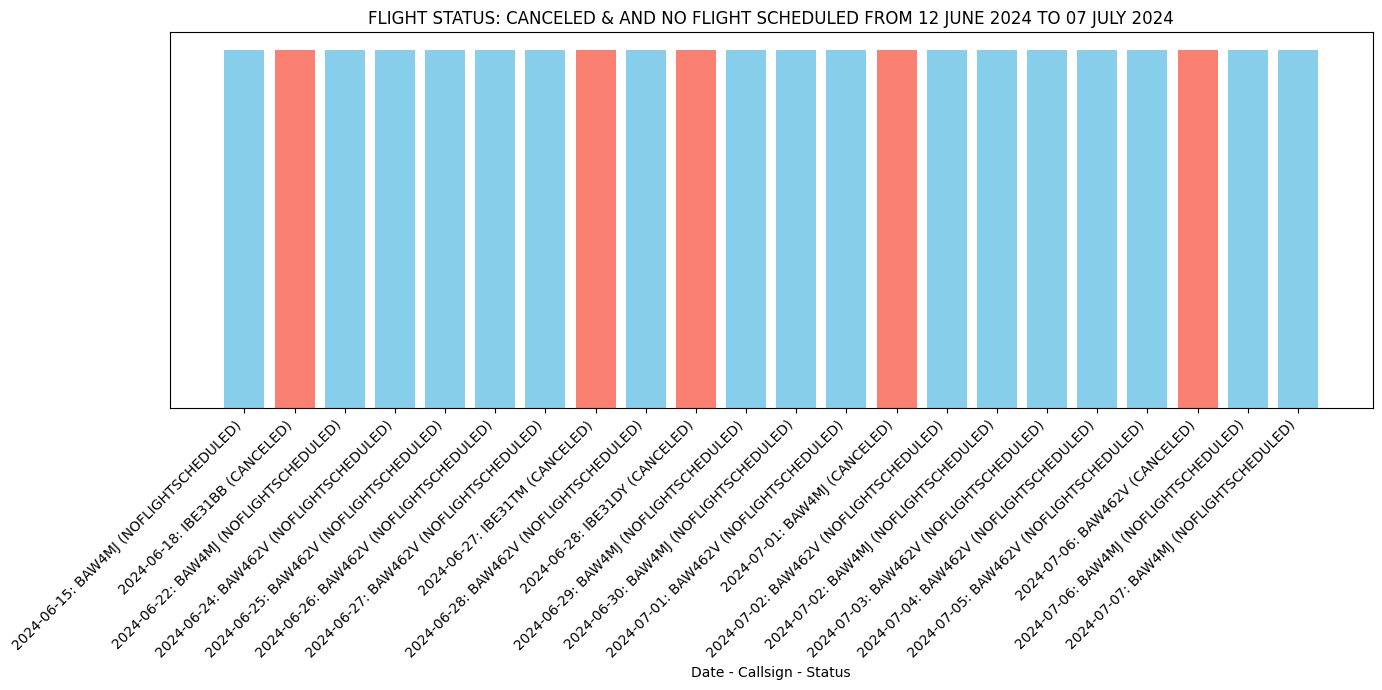

In [ ]:
#CHECKING BOTH

# Import the matplotlib.pyplot module
import matplotlib.pyplot as plt

# Convert 'UTC' to datetime and 'Position' to string (if not already done)
data['UTC'] = pd.to_datetime(data['UTC'], errors='coerce')
data['Position'] = data['Position'].astype(str)

# Filter rows with "CANCELED" or "NOFLIGHTSCHEDULED"
filtered_flights = data[data['Position'].str.contains('CANCELED|NOFLIGHTSCHEDULED', case=False, na=False)]

# Check if filtering worked correctly
print(f"Number of filtered rows: {len(filtered_flights)}")
print(filtered_flights.head())

# Count the number of occurrences per day, callsign, and position
flight_counts = filtered_flights.groupby([filtered_flights['UTC'].dt.date, 'Callsign', 'Position']).size()

# Convert the Series to a DataFrame
flight_counts_df = flight_counts.reset_index(name='Count')

# Create a combined label for plotting
flight_counts_df['Label'] = flight_counts_df.apply(
    lambda row: f"{row['UTC']}: {row['Callsign']} ({row['Position']})", axis=1
)

# Check the DataFrame after adding the 'Label' column
print(flight_counts_df.head())

# Create a bar plot
plt.figure(figsize=(14, 7))
plt.bar(flight_counts_df['Label'], flight_counts_df['Count'], color=['salmon' if pos == 'CANCELED' else 'skyblue' for pos in flight_counts_df['Position']])

# Customize plot
plt.xlabel('Date - Callsign - Status')
plt.title('FLIGHT STATUS: CANCELED & AND NO FLIGHT SCHEDULED FROM 12 JUNE 2024 TO 07 JULY 2024')
plt.xticks(rotation=45, ha='right')  # Rotate and align x-axis labels

# Remove the y-axis
plt.gca().axes.yaxis.set_visible(False)

# Adjust layout
plt.tight_layout()

# Save or show the plot
plt.savefig('combined_flight_counts_per_day.png')
plt.show()

Area Chart to represent visually the Canceled and No Schedule flight

<Figure size 1400x700 with 0 Axes>

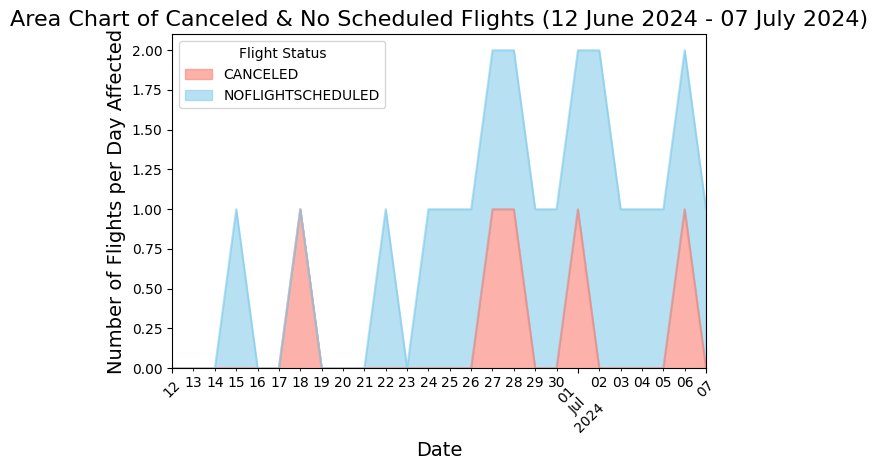

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame
# Convert 'UTC' to datetime and 'Position' to string (if not already done)
data['UTC'] = pd.to_datetime(data['UTC'], errors='coerce')
data['Position'] = data['Position'].astype(str)

# Filter rows with "CANCELED" or "NOFLIGHTSCHEDULED"
filtered_flights = data[data['Position'].str.contains('CANCELED|NOFLIGHTSCHEDULED', case=False, na=False)]

# Count the number of occurrences per day and position
flight_counts = filtered_flights.groupby([filtered_flights['UTC'].dt.date, 'Position']).size().unstack(fill_value=0)

# Define the exact date range from 12 June 2024 to 07 July 2024
date_range = pd.date_range(start='2024-06-12', end='2024-07-07')

# Reindex the DataFrame to ensure all days within the period are represented, filling missing days with zeros
flight_counts = flight_counts.reindex(date_range, fill_value=0)

# Plot the area chart
plt.figure(figsize=(14, 7))
flight_counts.plot(kind='area', stacked=True, color=['salmon', 'skyblue'], alpha=0.6)

# Customize the plot
plt.title('Area Chart of Canceled & No Scheduled Flights (12 June 2024 - 07 July 2024)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Flights per Day Affected', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Flight Status')

# Adjust layout
plt.tight_layout()

# Save or show the plot
plt.savefig('area_chart_flight_counts.png')
plt.show()

This area chart visualizes the number of flights per day that were either canceled or had no flights scheduled between June 12, 2024, and July 7, 2024. Let's break down the chart:

Chart Explanation:
X-Axis (Date): This axis represents the dates ranging from June 12, 2024, to July 7, 2024.
Y-Axis (Number of Flights per Day Affected): This axis shows the number of flights affected on each day, either due to cancellations or because no flights were scheduled.
Area Plot: The chart uses colored areas to represent different statuses of flights:
Red/ Pink Area ("CANCELED"): Indicates the number of flights canceled on each day.
Blue Area ("NOFLIGHTSCHEDULED"): Indicates the number of days with no scheduled flights.
Interpretation:
Pattern of Cancellations and No Scheduled Flights: The chart shows several peaks, where both cancellations and no scheduled flights were observed on particular days.

Peaks: The peaks in the blue area represent days with a high number of flights that had no schedules. The smaller red peaks represent days with cancellations.
June 25-26 & July 2-3: The peaks around these dates indicate that the highest number of flights were either canceled or not scheduled during this period. This correlated with the data



Preparting data for Basic Simulation to pull out from the historical data retrieved for INDUSTRY PROJECT.
In the simualtion code in the Future a API may be coded in and direct information from all operating flight worldwide can be pulled out

In [ ]:
# Convert 'UTC' to datetime and 'Position' to string (if not already done)
data['UTC'] = pd.to_datetime(data['UTC'], errors='coerce')
data['Position'] = data['Position'].astype(str)


In [ ]:
#MAPPING CANCELED FLIGHTS IN POSITION COLUMN

# Create a set of canceled flights for quick lookup
canceled_flights_set = set(canceled_flights['Callsign'])

# Create a mapping of canceled flights with their dates and statuses
canceled_flights_mapping = canceled_flights.groupby(
    ['Callsign', canceled_flights['UTC'].dt.date, 'Position']
).size().reset_index(name='count')

# Now, canceled_flights_mapping includes 'Position' for each flight
print(canceled_flights_mapping)

  Callsign         UTC  Position  count
0  BAW462V  2024-07-06  CANCELED      1
1   BAW4MJ  2024-07-01  CANCELED      1
2  IBE31BB  2024-06-18  CANCELED      1
3  IBE31DY  2024-06-28  CANCELED      1
4  IBE31TM  2024-06-27  CANCELED      1


In [ ]:
#MAPPING FOR NOFLIGHTSCHEDULED

# Filter rows with "NOFLIGHTSCHEDULED"
no_flight_schedule = data[data['Position'].str.contains('NOFLIGHTSCHEDULED', case=False, na=False)]

# Create a set of "NOFLIGHTSCHEDULED" flights for quick lookup
no_flight_schedule_set = set(no_flight_schedule['Callsign'])

# Print the set to verify
print("Set of NOFLIGHTSCHEDULED flights:")
print(no_flight_schedule_set)

# Create a mapping of "NOFLIGHTSCHEDULED" flights with their dates and statuses
no_flight_schedule_mapping = no_flight_schedule.groupby(
    ['Callsign', no_flight_schedule['UTC'].dt.date, 'Position']
).size().reset_index(name='count')

# Print the mapping
print("Mapping of NOFLIGHTSCHEDULED flights:")
print(no_flight_schedule_mapping)

Set of NOFLIGHTSCHEDULED flights:
{'BAW462V', 'BAW4MJ'}
Mapping of NOFLIGHTSCHEDULED flights:
   Callsign         UTC           Position  count
0   BAW462V  2024-06-24  NOFLIGHTSCHEDULED      1
1   BAW462V  2024-06-25  NOFLIGHTSCHEDULED      1
2   BAW462V  2024-06-26  NOFLIGHTSCHEDULED      1
3   BAW462V  2024-06-27  NOFLIGHTSCHEDULED      1
4   BAW462V  2024-06-28  NOFLIGHTSCHEDULED      1
5   BAW462V  2024-07-01  NOFLIGHTSCHEDULED      1
6   BAW462V  2024-07-02  NOFLIGHTSCHEDULED      1
7   BAW462V  2024-07-03  NOFLIGHTSCHEDULED      1
8   BAW462V  2024-07-04  NOFLIGHTSCHEDULED      1
9   BAW462V  2024-07-05  NOFLIGHTSCHEDULED      1
10   BAW4MJ  2024-06-15  NOFLIGHTSCHEDULED      1
11   BAW4MJ  2024-06-22  NOFLIGHTSCHEDULED      1
12   BAW4MJ  2024-06-29  NOFLIGHTSCHEDULED      1
13   BAW4MJ  2024-06-30  NOFLIGHTSCHEDULED      1
14   BAW4MJ  2024-07-02  NOFLIGHTSCHEDULED      1
15   BAW4MJ  2024-07-06  NOFLIGHTSCHEDULED      1
16   BAW4MJ  2024-07-07  NOFLIGHTSCHEDULED      1


Flight Simulation Model for Operational Analysis

REQUIREMENTS FOR INDUSTRY PROJECT:  Simulation that ensures that Estimated vs Actual Departure and Arrival times are pulles out and the difference calculated. As well, inclusion of the Taxi Times is alsp coded to see the impact of these timings in the process of a flight.

In [ ]:
#MERGIN OF THE TWO DATA SETS:
# Merge the two dataframes on the 'Callsign' column that is common in both
merged_data = pd.merge(data, fdata, on='Callsign', how='left')
# ensure that it is to the left so the readings of Estiamted tTimes works and are calculated correctly.

testing that normal operating flight data been retrieved

In [ ]:
class Flight:
    def __init__(self, env, callsign_or_flight, date, origin, destination, canceled_flights_mapping, flight_data):
        self.env = env
        self.callsign_or_flight = callsign_or_flight
        self.date = date
        self.origin = origin
        self.destination = destination
        self.canceled_flights_mapping = canceled_flights_mapping
        self.flight_data = flight_data
        self.departure_time = None
        self.arrival_time = None
        self.taxi_start_before_takeoff = None
        self.taxi_end_before_takeoff = None
        self.taxi_start_after_landing = None
        self.taxi_end_after_landing = None
        self.flight_start = None
        self.flight_end = None

        # Retrieve the estimated departure and arrival times
        self.estimated_departure_time, self.estimated_arrival_time = self.get_estimated_times()

        # Set time zones based on origin and destination
        self.departure_tz = airport_timezones.get(self.origin, pytz.UTC)  # Default to UTC if not found
        self.arrival_tz = airport_timezones.get(self.destination, pytz.UTC)  # Default to UTC if not found

        # Determine the status of the flight
        self.status = self.determine_flight_status()

        # Check if the flight is canceled on this date
        if (self.callsign_or_flight, self.date) in self.canceled_flights_mapping.set_index(['Callsign', 'UTC']).index:
            self.canceled = True
            print(f"Flight {self.callsign_or_flight} is canceled on {self.date}.")
        else:
            self.canceled = False
            # Create a process in the simulation environment
            self.process = env.process(self.run())

    def determine_flight_status(self):
        # Extract relevant flight data for this callsign and date
        flight_records = self.flight_data[
            (self.flight_data['Callsign'] == self.callsign_or_flight) |
            (self.flight_data['Flight'] == self.callsign_or_flight)
        ]

        flight_records = flight_records[flight_records['UTC'].dt.date == self.date]

        # Determine the flight status based on the 'Position' column
        if not flight_records.empty:
            position_value = flight_records.iloc[0]['Position']
            if "CANCELED" in str(position_value).upper():
                status = "FLIGHT CANCELED"
            elif "NOFLIGHTSCHEDULED" in str(position_value).upper():
                status = "NO FLIGHT OPERATING ON THIS DATE"
            else:
                return None
        else:
            return None

        # Print the status if the flight is canceled or has no scheduled flight
        print(f"Status for flight {self.callsign_or_flight} on {self.date}: {status}")

        return status

    def get_estimated_times(self):
        # Find the flight schedule by callsign or flight number
        schedule = self.flight_data[
            (self.flight_data['Callsign'] == self.callsign_or_flight) |
            (self.flight_data['Flight'] == self.callsign_or_flight)
        ]
        if not schedule.empty:
            estimated_departure = schedule['Estimated Departure'].values[0]
            estimated_arrival = schedule['Estimated Arrival'].values[0]
            return estimated_departure, estimated_arrival
        return None, None

    def run(self):
        if self.canceled:
            return

        # Extract flight data for this callsign or flight number and date
        flight_records = self.flight_data[
            (self.flight_data['Callsign'] == self.callsign_or_flight) |
            (self.flight_data['Flight'] == self.callsign_or_flight)
        ].copy()  # Make a copy to avoid SettingWithCopyWarning

        # Convert 'UTC' column to datetime format
        flight_records.loc[:, 'UTC'] = pd.to_datetime(flight_records['UTC'])

        # Filter flight records by the specified date
        flight_records = flight_records[flight_records['UTC'].dt.date == self.date]

        last_utc_time = None

        for _, row in flight_records.iterrows():
            utc_time = row['UTC']
            last_utc_time = utc_time
            altitude = row['Altitude']

            if altitude == 0 and self.taxi_start_before_takeoff is None and self.flight_start is None:
                self.taxi_start_before_takeoff = utc_time
                print(f"Flight {self.callsign_or_flight} started taxiing before takeoff at {self.taxi_start_before_takeoff}")
            elif altitude > 0 and self.taxi_start_before_takeoff is not None and self.flight_start is None:
                self.flight_start = utc_time
                self.taxi_end_before_takeoff = utc_time
                print(f"Flight {self.callsign_or_flight} ended taxiing before takeoff at {self.taxi_end_before_takeoff}")
                print(f"Flight {self.callsign_or_flight} took off at {self.flight_start}")
            elif altitude == 0 and self.flight_start is not None and self.flight_end is None:
                self.flight_end = utc_time
                self.taxi_start_after_landing = utc_time
                print(f"Flight {self.callsign_or_flight} landed at {self.flight_end}")
                print(f"Flight {self.callsign_or_flight} started taxiing after landing at {self.taxi_start_after_landing}")

        if self.flight_end:
            self.taxi_end_after_landing = last_utc_time
            print(f"Flight {self.callsign_or_flight} ended taxiing after landing at {self.taxi_end_after_landing}")

            # Simulate time passing
            yield self.env.timeout(1)  # Adjust timeout if needed to simulate more accurately

        # Print final stats
        self.report()

    def report(self):
        if self.canceled:
            print(f"Flight {self.callsign_or_flight} was canceled on {self.date}.")
            return

        print(f"Flight {self.callsign_or_flight} report:")
        print(f"  Estimated Departure Time: {self.estimated_departure_time}")
        print(f"  Actual Departure Time: {self.flight_start}")
        print(f"  Estimated Arrival Time: {self.estimated_arrival_time}")
        print(f"  Actual Arrival Time: {self.flight_end}")
        print(f"  Taxi Start Before Takeoff: {self.taxi_start_before_takeoff}")
        print(f"  Taxi End Before Takeoff: {self.taxi_end_before_takeoff}")
        print(f"  Taxi Start After Landing: {self.taxi_start_after_landing}")
        print(f"  Taxi End After Landing: {self.taxi_end_after_landing}")
        print(f"  Taxi Time Before Takeoff: {self.taxi_end_before_takeoff - self.taxi_start_before_takeoff if self.taxi_start_before_takeoff and self.taxi_end_before_takeoff else 'N/A'}")
        print(f"  Taxi Time After Landing: {self.taxi_end_after_landing - self.taxi_start_after_landing if self.taxi_start_after_landing and self.taxi_end_after_landing else 'N/A'}")
        print(f"  Flight Duration: {self.flight_end - self.flight_start if self.flight_start and self.flight_end else 'N/A'}")

        # Calculate and print delays
        if self.estimated_departure_time and self.flight_start:
            est_dep_time = datetime.combine(self.date, self.estimated_departure_time)
            est_dep_dt = self.departure_tz.localize(est_dep_time)  # Localize to departure time zone
            dep_delay = (self.flight_start - est_dep_dt).total_seconds() / 60
            print(f"  Estimated Departure vs Actual Departure: {dep_delay} minutes")

        if self.estimated_arrival_time and self.flight_end:
            est_arr_time = datetime.combine(self.date, self.estimated_arrival_time)
            est_arr_dt = self.arrival_tz.localize(est_arr_time)  # Localize to arrival time zone
            arr_delay = (self.flight_end - est_arr_dt).total_seconds() / 60
            print(f"  Estimated Arrival vs Actual Arrival: {arr_delay} minutes")

# Function to get user input for flight information
def get_flight_info():
    callsign_or_flight = input("Enter the flight callsign or flight number: ")
    date_str = input("Enter the flight date (YYYY-MM-DD): ")
    origin = input("Enter the origin airport code (e.g., LHR): ")
    destination = input("Enter the destination airport code (e.g., MAD): ")
    date = pd.to_datetime(date_str).date()
    return callsign_or_flight, date, origin, destination

# Set up the simulation environment
env = simpy.Environment()

# Get flight information from user input
callsign_or_flight, date, origin, destination = get_flight_info()

# Assuming 'canceled_flights_mapping' is defined and contains relevant data
# Example canceled_flights_mapping definition
canceled_flights_mapping = pd.DataFrame({'Callsign': ['IBE31BB'], 'UTC': [pd.to_datetime('2024-06-18')]})

# Assuming 'merged_data' is a DataFrame that includes relevant flight data
# merged_data = ...

# Create Flight object
flight = Flight(env, callsign_or_flight, date, origin, destination, canceled_flights_mapping, merged_data)

# Run the simulation
env.run()

Enter the flight callsign or flight number: IBE31BB
Enter the flight date (YYYY-MM-DD): 2024-06-12
Enter the origin airport code (e.g., LHR): LHR
Enter the destination airport code (e.g., MAD): MAD
Flight IBE31BB started taxiing before takeoff at 2024-06-12 05:11:58+00:00
Flight IBE31BB ended taxiing before takeoff at 2024-06-12 07:04:45+00:00
Flight IBE31BB took off at 2024-06-12 07:04:45+00:00
Flight IBE31BB landed at 2024-06-12 08:52:40+00:00
Flight IBE31BB started taxiing after landing at 2024-06-12 08:52:40+00:00
Flight IBE31BB ended taxiing after landing at 2024-06-12 08:56:59+00:00
Flight IBE31BB report:
  Estimated Departure Time: 06:15:00
  Actual Departure Time: 2024-06-12 07:04:45+00:00
  Estimated Arrival Time: 08:40:00
  Actual Arrival Time: 2024-06-12 08:52:40+00:00
  Taxi Start Before Takeoff: 2024-06-12 05:11:58+00:00
  Taxi End Before Takeoff: 2024-06-12 07:04:45+00:00
  Taxi Start After Landing: 2024-06-12 08:52:40+00:00
  Taxi End After Landing: 2024-06-12 08:56:59+0

TESTING THAT IT RETRIEVES VIA FLIGH ID (IBE31BB = IB3181)
(Callsign = Flight Id)

In [ ]:

# Set up the simulation environment
env = simpy.Environment()

# Get flight information from user input
callsign_or_flight, date, origin, destination = get_flight_info()

# Assuming 'canceled_flights_mapping' is defined and contains relevant data
# Example canceled_flights_mapping definition
canceled_flights_mapping = pd.DataFrame({'Callsign': ['IBE31BB'], 'UTC': [pd.to_datetime('2024-06-18')]})

# Assuming 'merged_data' is a DataFrame that includes relevant flight data
# merged_data = ...

# Create Flight object
flight = Flight(env, callsign_or_flight, date, origin, destination, canceled_flights_mapping, merged_data)

# Run the simulation
env.run()


Enter the flight callsign or flight number: IB3181
Enter the flight date (YYYY-MM-DD): 2024-06-12
Enter the origin airport code (e.g., LHR): LHR
Enter the destination airport code (e.g., MAD): MAD
Flight IB3181 started taxiing before takeoff at 2024-06-12 05:11:58+00:00
Flight IB3181 ended taxiing before takeoff at 2024-06-12 07:04:45+00:00
Flight IB3181 took off at 2024-06-12 07:04:45+00:00
Flight IB3181 landed at 2024-06-12 08:52:40+00:00
Flight IB3181 started taxiing after landing at 2024-06-12 08:52:40+00:00
Flight IB3181 ended taxiing after landing at 2024-06-12 08:56:59+00:00
Flight IB3181 report:
  Estimated Departure Time: 06:15:00
  Actual Departure Time: 2024-06-12 07:04:45+00:00
  Estimated Arrival Time: 08:40:00
  Actual Arrival Time: 2024-06-12 08:52:40+00:00
  Taxi Start Before Takeoff: 2024-06-12 05:11:58+00:00
  Taxi End Before Takeoff: 2024-06-12 07:04:45+00:00
  Taxi Start After Landing: 2024-06-12 08:52:40+00:00
  Taxi End After Landing: 2024-06-12 08:56:59+00:00
  T

Code to see a NONSCHEDULED FLIGHT Flight with indication of this staus displayed

In [ ]:

# Set up the simulation environment
env = simpy.Environment()

# Get flight information from user input
callsign_or_flight, date, origin, destination = get_flight_info()

# Assuming 'canceled_flights_mapping' is defined and contains relevant data
# Example canceled_flights_mapping definition
canceled_flights_mapping = pd.DataFrame({'Callsign': ['IBE31BB'], 'UTC': [pd.to_datetime('2024-06-18')]})

# Assuming 'merged_data' is a DataFrame that includes relevant flight data
# merged_data = ...

# Create Flight object
flight = Flight(env, callsign_or_flight, date, origin, destination, canceled_flights_mapping, merged_data)

# Run the simulation
env.run()

Enter the flight callsign or flight number: BA462
Enter the flight date (YYYY-MM-DD): 2024-07-04
Enter the origin airport code (e.g., LHR): LHR
Enter the destination airport code (e.g., MAD): MAD
Status for flight BA462 on 2024-07-04: NO FLIGHT OPERATING ON THIS DATE
Flight BA462 report:
  Estimated Departure Time: 14:40:00
  Actual Departure Time: None
  Estimated Arrival Time: 17:05:00
  Actual Arrival Time: None
  Taxi Start Before Takeoff: None
  Taxi End Before Takeoff: None
  Taxi Start After Landing: None
  Taxi End After Landing: None
  Taxi Time Before Takeoff: N/A
  Taxi Time After Landing: N/A
  Flight Duration: N/A


Code to see CANCELED Flight status (nonscheduled flight/ flight removed from the schedule not operating that day specifically) to see status been displayed

In [ ]:

# Set up the simulation environment
env = simpy.Environment()

# Get flight information from user input
callsign_or_flight, date, origin, destination = get_flight_info()

# Assuming 'canceled_flights_mapping' is defined and contains relevant data
# Example canceled_flights_mapping definition
canceled_flights_mapping = pd.DataFrame({'Callsign': ['IBE31BB'], 'UTC': [pd.to_datetime('2024-06-18')]})

# Assuming 'merged_data' is a DataFrame that includes relevant flight data
# merged_data = ...

# Create Flight object
flight = Flight(env, callsign_or_flight, date, origin, destination, canceled_flights_mapping, merged_data)

# Run the simulation
env.run()

Enter the flight callsign or flight number: IBE31TM
Enter the flight date (YYYY-MM-DD): 2024-06-27
Enter the origin airport code (e.g., LHR): LHR
Enter the destination airport code (e.g., MAD): MAD
Status for flight IBE31TM on 2024-06-27: FLIGHT CANCELED
Flight IBE31TM report:
  Estimated Departure Time: 11:30:00
  Actual Departure Time: None
  Estimated Arrival Time: 13:55:00
  Actual Arrival Time: None
  Taxi Start Before Takeoff: None
  Taxi End Before Takeoff: None
  Taxi Start After Landing: None
  Taxi End After Landing: None
  Taxi Time Before Takeoff: N/A
  Taxi Time After Landing: N/A
  Flight Duration: N/A


TIME SERIES FOR INDUSTRY PROJECT

Purpose of it:Understanding trends, patterns, and the impact of various factors on a process. Time series analysis may help visualize how delays accumulate or vary over the course of a flight or a series of flights.

Step 1: Data Preparation
Objective: Load the datasets, parse dates, and prepare the data for analysis.

In [ ]:
import pandas as pd
from datetime import datetime, timedelta

# Load the dataset
file_path_flight_data = 'FlightData ordered by date hour.csv'
flight_data = pd.read_csv(file_path_flight_data)

file_path_schedule = 'LHR MAD Flight Schedule.csv'
schedule_data = pd.read_csv(file_path_schedule)

# Convert 'UTC' column in flight_data to datetime (if not already done)
flight_data['UTC'] = pd.to_datetime(flight_data['UTC'], errors='coerce')

# Convert 'Estimated Departure' and 'Estimated Arrival' columns to datetime
schedule_data['Estimated Departure'] = pd.to_datetime(schedule_data['Estimated Departure'], format='%H:%M:%S').dt.time
schedule_data['Estimated Arrival'] = pd.to_datetime(schedule_data['Estimated Arrival'], format='%H:%M:%S').dt.time


Step 2: Time Series Creation
Objective: Calculate the various metrics needed for time series analysis based on the flight data and schedule data.

In [ ]:
def calculate_flight_metrics(flight_data, schedule_data):
    metrics = []

    for _, row in schedule_data.iterrows():
        callsign = row['Callsign']
        flight_records = flight_data[flight_data['Callsign'] == callsign]

        if not flight_records.empty:
            # Determine the date for the flight records
            flight_date = flight_records['UTC'].dt.date.max()

            # Find estimated times (convert to datetime with UTC timezone)
            est_dep = datetime.combine(flight_date, row['Estimated Departure'])
            est_arr = datetime.combine(flight_date, row['Estimated Arrival'])

            # Assume UTC timezone for both estimated and actual times
            est_dep = est_dep.replace(tzinfo=pd.Timestamp.utcnow().tzinfo)
            est_arr = est_arr.replace(tzinfo=pd.Timestamp.utcnow().tzinfo)

            # Extract relevant times
            taxi_start_before_takeoff = flight_records[flight_records['Altitude'] == 0].iloc[0]['UTC']
            flight_start = flight_records[flight_records['Altitude'] > 0].iloc[0]['UTC']
            flight_end = flight_records[flight_records['Altitude'] == 0].iloc[-1]['UTC']
            taxi_end_after_landing = flight_records[flight_records['Altitude'] == 0].iloc[-1]['UTC']

            # Calculate metrics
            taxi_time_before_takeoff = (flight_start - taxi_start_before_takeoff).total_seconds() / 60
            taxi_time_after_landing = (taxi_end_after_landing - flight_end).total_seconds() / 60
            flight_duration = (flight_end - flight_start).total_seconds() / 60
            dep_delay = (flight_start - est_dep).total_seconds() / 60
            arr_delay = (flight_end - est_arr).total_seconds() / 60

            # Append metrics for this flight
            metrics.append({
                'Callsign': callsign,
                'Estimated Departure': est_dep,
                'Actual Departure': flight_start,
                'Estimated Arrival': est_arr,
                'Actual Arrival': flight_end,
                'Taxi Time Before Takeoff (minutes)': taxi_time_before_takeoff,
                'Taxi Time After Landing (minutes)': taxi_time_after_landing,
                'Flight Duration (minutes)': flight_duration,
                'Departure Delay (minutes)': dep_delay,
                'Arrival Delay (minutes)': arr_delay
            })

    return pd.DataFrame(metrics)

# Calculate metrics
metrics_df = calculate_flight_metrics(flight_data, schedule_data)


Step 3: Plot Time Series Data
For visualization, plot the metrics using matplotlib:



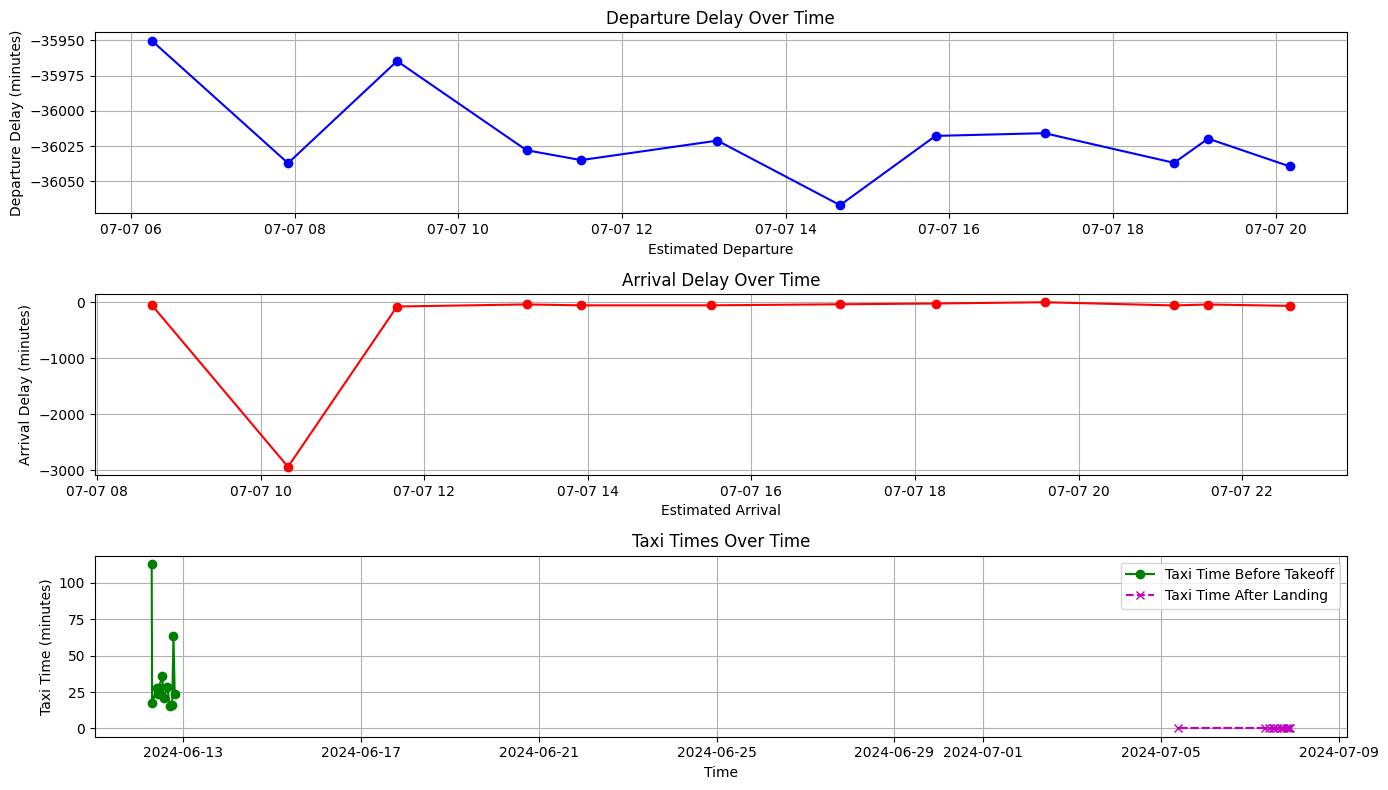

In [ ]:
import matplotlib.pyplot as plt

# Convert columns to datetime if necessary
metrics_df['Estimated Departure'] = pd.to_datetime(metrics_df['Estimated Departure'])
metrics_df['Actual Departure'] = pd.to_datetime(metrics_df['Actual Departure'])
metrics_df['Estimated Arrival'] = pd.to_datetime(metrics_df['Estimated Arrival'])
metrics_df['Actual Arrival'] = pd.to_datetime(metrics_df['Actual Arrival'])

# Plot metrics
plt.figure(figsize=(14, 8))

# Plot Departure Delays
plt.subplot(3, 1, 1)
plt.plot(metrics_df['Estimated Departure'], metrics_df['Departure Delay (minutes)'], marker='o', linestyle='-', color='b')
plt.title('Departure Delay Over Time')
plt.xlabel('Estimated Departure')
plt.ylabel('Departure Delay (minutes)')
plt.grid(True)

# Plot Arrival Delays
plt.subplot(3, 1, 2)
plt.plot(metrics_df['Estimated Arrival'], metrics_df['Arrival Delay (minutes)'], marker='o', linestyle='-', color='r')
plt.title('Arrival Delay Over Time')
plt.xlabel('Estimated Arrival')
plt.ylabel('Arrival Delay (minutes)')
plt.grid(True)

# Plot Taxi Times Before Takeoff and After Landing
plt.subplot(3, 1, 3)
plt.plot(metrics_df['Actual Departure'], metrics_df['Taxi Time Before Takeoff (minutes)'], marker='o', linestyle='-', color='g', label='Taxi Time Before Takeoff')
plt.plot(metrics_df['Actual Arrival'], metrics_df['Taxi Time After Landing (minutes)'], marker='x', linestyle='--', color='m', label='Taxi Time After Landing')
plt.title('Taxi Times Over Time')
plt.xlabel('Time')
plt.ylabel('Taxi Time (minutes)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


1. Departure Delay Over Time (Top Plot)
Observation: The blue line shows the departure delay over time. It appears that the delay fluctuates significantly, with some departure times showing very large negative values.
Interpretation: The large negative values suggest that the flights departed much earlier than the estimated time. The fluctuations indicate inconsistency in the departure schedule, possibly due to early takeoffs or schedule adjustments.
2. Arrival Delay Over Time (Middle Plot)
Observation: The red line indicates the arrival delay over time. Similar to the departure delay, there is a significant drop in delay at certain times, with one particularly large negative spike.
Interpretation: The large negative spike indicates that a flight arrived much earlier than scheduled. The consistency in the line after this spike suggests that for many other flights, the actual arrival times are either on time or slightly early, resulting in minimal delay variation.
3. Taxi Times Over Time (Bottom Plot)
Observation: The green dots represent the taxi time before takeoff, and the purple crosses represent the taxi time after landing. The taxi times before takeoff show some variability early on, but there is no data for a significant period after that. The taxi time after landing shows consistent times across the board but at a later period.

Interpretation: The variability in taxi times before takeoff suggests different conditions at the airport (e.g., runway availability, congestion).  The consistent taxi time after landing could suggest standard procedures or less variability in conditions after landing.

ERROR IN THE TAXI TIME SERES The absence of data for an extended period could indicate that flights either did not occur, or data was not recorded correctly in the time series as by plotting it again and again nothing appears.the time series failed to collect data consistently throughout the observed period. The gap in the taxi times and the clustering of data into two distinct parts suggest that the data collection was either interrupted, incomplete, or not aligned with the expected continuous time series. This inconsistency could be due to technical issues, periods without flights, or data logging errors during those missing periods.

General Insights:

Large Negative Delays: Both departure and arrival delays indicate that flights often depart and arrive much earlier than scheduled. This could be due to factors such as improved flight times, reduced congestion, or overly conservative scheduling.

Variability in Taxi Times: The variability in taxi times suggests that airport conditions significantly impact how long a flight spends taxiing, particularly before takeoff.

Simulation Project starts here:


DATA ANALYSIS

CHECKING TYPE OF DISTRIBUTION OF MY DATA:

In [ ]:
import pandas as pd
import numpy as np

# Load the datasets
file_path = 'FlightData ordered by date hour.csv'
data = pd.read_csv(file_path)

file_path = 'LHR MAD Flight Schedule.csv'
fdata = pd.read_csv(file_path)

# Convert UTC to datetime for easier manipulation
data['UTC'] = pd.to_datetime(data['UTC'])

# Group data by Callsign to separate each flight
grouped = data.groupby('Callsign')

taxi_times = []

for name, group in grouped:
    group = group.sort_values('UTC')  # Ensure the data is sorted by time

    # Identify the first instance of non-zero altitude (takeoff) and last instance of non-zero altitude (landing)
    takeoff_index = group[group['Altitude'] > 0].index[0] if not group[group['Altitude'] > 0].empty else None
    landing_index = group[group['Altitude'] > 0].index[-1] if not group[group['Altitude'] > 0].empty else None

    if takeoff_index and landing_index:
        # Taxi time before takeoff
        taxi_before_takeoff = (group.loc[takeoff_index]['UTC'] - group.loc[group.index < takeoff_index]['UTC'].min()).total_seconds()

        # Taxi time after landing
        taxi_after_landing = (group.loc[group.index > landing_index]['UTC'].max() - group.loc[landing_index]['UTC']).total_seconds()

        # Store the results
        taxi_times.append((name, taxi_before_takeoff, taxi_after_landing))

# Convert to DataFrame for easier analysis
taxi_times_df = pd.DataFrame(taxi_times, columns=['Callsign', 'TaxiBeforeTakeoff', 'TaxiAfterLanding'])

#1.Visual Inspection of the Data

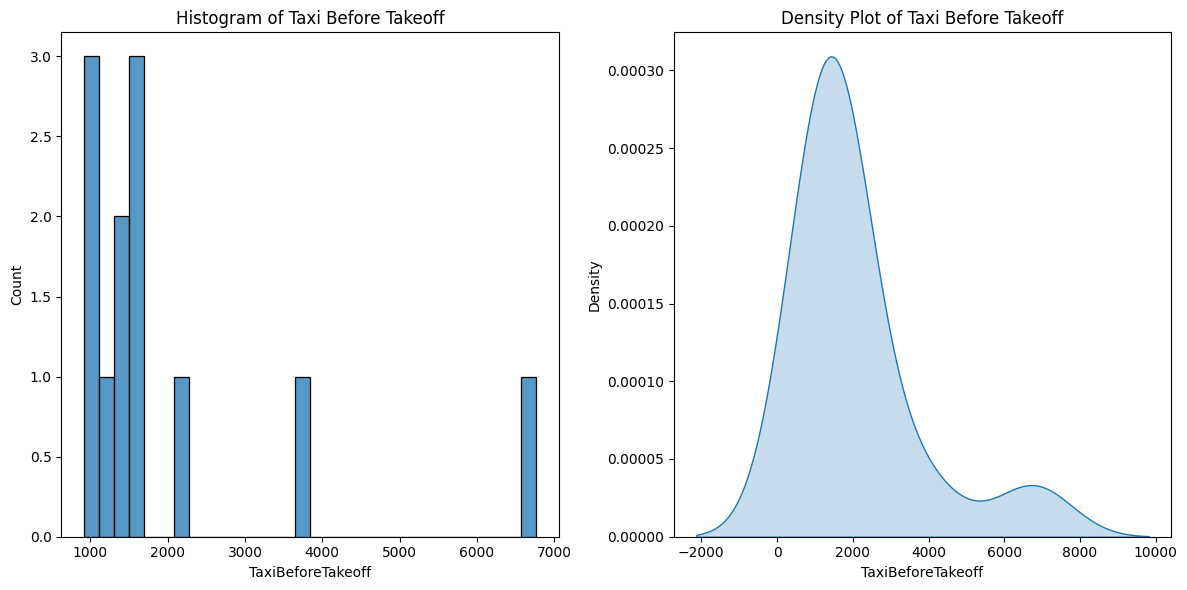

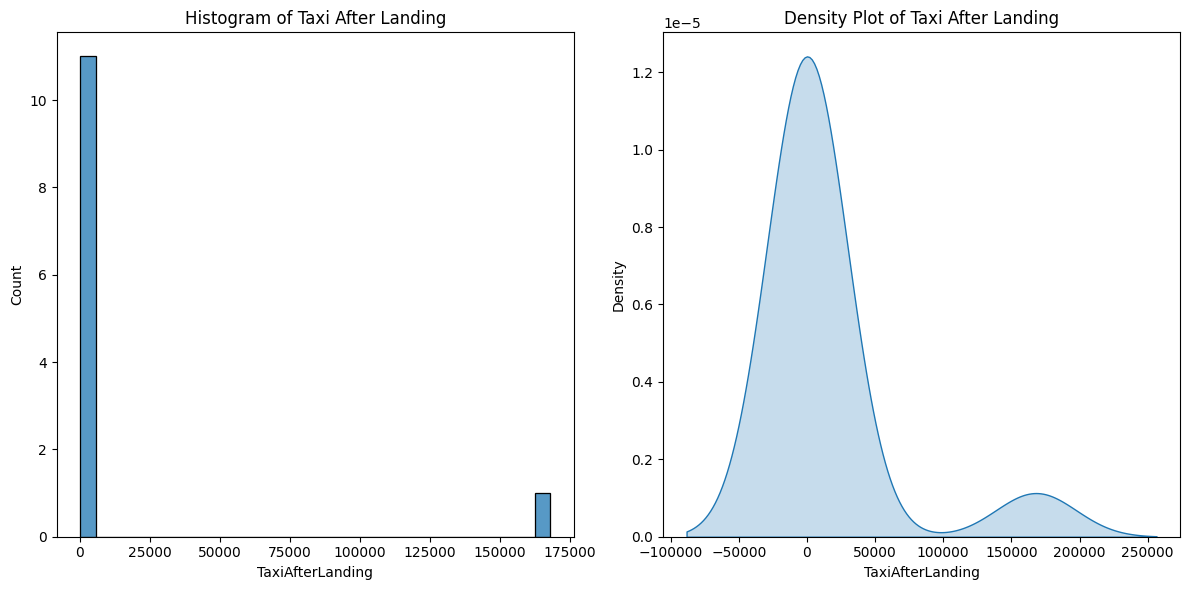

In [ ]:
#1.Visual Inspection
#Histogram and Density Plot
#Visualizing the distribution can give you an initial idea of whether the data is normally distributed or not.import matplotlib.pyplot as plt
import seaborn as sns

# Histogram and Density Plot for Taxi Before Takeoff
plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(taxi_times_df['TaxiBeforeTakeoff'], kde=False, bins=30)
plt.title('Histogram of Taxi Before Takeoff')

# Density Plot
plt.subplot(1, 2, 2)
sns.kdeplot(taxi_times_df['TaxiBeforeTakeoff'], fill=True)
plt.title('Density Plot of Taxi Before Takeoff')

plt.tight_layout()
plt.show()

# Histogram and Density Plot for Taxi After Landing
plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(taxi_times_df['TaxiAfterLanding'], kde=False, bins=30)
plt.title('Histogram of Taxi After Landing')

# Density Plot
plt.subplot(1, 2, 2)
sns.kdeplot(taxi_times_df['TaxiAfterLanding'], fill=True)
plt.title('Density Plot of Taxi After Landing')

plt.tight_layout()
plt.show()

1. Histogram of Taxi Before Takeoff (Left Plot)
Observation: The histogram shows several distinct bars, indicating that taxi times before takeoff are not uniformly distributed. Most of the flights have taxi times clustered between 1,000 to 2,000 units, with a few flights having longer taxi times reaching up to around 7,000 units.
Interpretation: The histogram suggests that while most flights have relatively short taxi times before takeoff, there are a few cases with significantly longer taxi times. This could indicate variations in airport congestion, the distance to the runway, or delays during the taxi phase. The distinct bars suggest that taxi times tend to cluster around specific intervals, potentially due to operational patterns or scheduling practices at the airport.
2. Density Plot of Taxi Before Takeoff (Right Plot)
Observation: The density plot shows a peak near 1,500 units, which corresponds to the most common taxi times. The plot also displays a long tail extending towards higher values, with a smaller bump around 7,000 units.
Interpretation: The density plot reinforces the observation that most taxi times before takeoff are concentrated around 1,500 units. The long tail indicates that there are some flights with much longer taxi times. The smaller secondary peak around 7,000 units might represent a specific group of flights consistently experiencing delays, possibly due to particular operational circumstances or runway assignments.
General Insights:

Bimodal Distribution: The histogram and density plot suggest a bimodal distribution, with one peak around 1,500 units (shorter taxi times) and a smaller peak around 7,000 units (longer taxi times).
Operational Variability: The presence of flights with significantly longer taxi times could indicate periods of high traffic, runway availability issues, or other operational challenges that cause certain flights to experience delays before takeoff.
These observations could be useful in identifying patterns in airport operations, specifically in understanding factors that contribute to longer taxi times before takeoff. Further investigation might be needed to determine the exact causes of these longer taxi times.

1. Histogram of Taxi After Landing (Left Plot)
Observation: The histogram shows that most of the taxi times after landing are clustered around a very small value close to zero, with one noticeable bar far on the right, representing a much higher taxi time.
Interpretation: The distribution of taxi times after landing is highly skewed. Most flights have very short taxi times after landing, indicating that the majority of flights are able to quickly taxi to their gates or parking positions. However, there is an outlier or a small number of flights with significantly longer taxi times, which could be due to specific conditions such as airport congestion, longer distances to the gate, or delays in finding a parking position.
2. Density Plot of Taxi After Landing (Right Plot)
Observation: The density plot shows a similar pattern, with a large peak near zero and a long tail extending towards larger values. The peak represents the most common (and very short) taxi times, while the tail represents the rare, longer taxi times.
Interpretation: The density plot further emphasizes the skewness observed in the histogram. The high density near zero indicates that short taxi times are very common, while the tail highlights the existence of flights with much longer taxi times. The secondary, smaller peak at the end of the tail might represent a specific group of flights that consistently have longer taxi times, potentially due to operational reasons.
General Insights:
Skewness: The data is highly skewed towards shorter taxi times after landing, which suggests that for most flights, the time to taxi to their final position is minimal. However, there are some outliers with much longer taxi times, which could be due to special circumstances.
Outliers: The histogram and density plot indicate the presence of outliers (flights with much longer taxi times). These might require further investigation to understand why these particular flights experience such delays.
Overall, the plots suggest that while the majority of flights experience minimal taxi delays after landing, a few cases stand out with significantly longer taxi times, which may warrant further analysis to determine the causes.

#2. STATITICAL TEST Shapiro-Wilk Test

In [ ]:
#2. STATITICAL TEST Shapiro-Wilk Test
from scipy.stats import shapiro

# Shapiro-Wilk Test for Taxi Before Takeoff
stat_before, p_before = shapiro(taxi_times_df['TaxiBeforeTakeoff'].dropna())
print(f"Shapiro-Wilk Test for Taxi Before Takeoff: Statistic={stat_before}, p-value={p_before}")

# Shapiro-Wilk Test for Taxi After Landing
stat_after, p_after = shapiro(taxi_times_df['TaxiAfterLanding'].dropna())
print(f"Shapiro-Wilk Test for Taxi After Landing: Statistic={stat_after}, p-value={p_after}")

Shapiro-Wilk Test for Taxi Before Takeoff: Statistic=0.6630216146733154, p-value=0.000379659591464603
Shapiro-Wilk Test for Taxi After Landing: Statistic=0.32824269207623935, p-value=1.2300857554841433e-06


Shapiro-Wilk Test: Taxi Before Takeoff: Significant deviation from normality (p-value < 0.05). Taxi After Landing: Significant deviation from normality (p-value < 0.05). Kolmogorov-Smirnov Test: Taxi Before Takeoff: The p-value indicates that the data might fit a normal distribution (p-value > 0.05). Taxi After Landing: The p-value indicates a deviation from normality (p-value < 0.05).

#3. FIT DIFFERENT DISTRIBUTIONS: FIT NORMAL DISTRIB

In [ ]:
#3. FIT DIFFERENT DISTRIBUTIONS: FIT NORMAL DISTRIB
import scipy.stats as stats

# Fit normal distribution for Taxi Before Takeoff
params_before = stats.norm.fit(taxi_times_df['TaxiBeforeTakeoff'].dropna())
print(f"Normal distribution parameters for Taxi Before Takeoff: {params_before}")

# Fit normal distribution for Taxi After Landing
params_after = stats.norm.fit(taxi_times_df['TaxiAfterLanding'].dropna())
print(f"Normal distribution parameters for Taxi After Landing: {params_after}")

Normal distribution parameters for Taxi Before Takeoff: (2066.0, 1599.1481586561433)
Normal distribution parameters for Taxi After Landing: (14241.25, 46382.36754077459)


CHECKING WITH NORM DISTR.
Normal Distribution Parameters:
Taxi Before Takeoff: Mean = 2066.0, StdDev = 1599.15

Mean (2066.0):  flights spend about 2066 units of time taxiing before taking off.
Standard Deviation (1599.15): T indicates that the taxi times before takeoff vary quite widely from the mean. Some flights may have significantly shorter or longer taxi times.

Taxi After Landing: Mean = 14241.25, StdDev = 46382.37

Mean (14241.25):  value of 14241.25 suggests that, on average, flights spend much more time taxiing after landing compared to before takeoff.
Standard Deviation (46382.37): This is very high, indicating an extreme variability in taxi times after landing. Such a large standard deviation suggests that while most flights might have relatively short taxi times, there are some flights with extremely long taxi times that significantly increase the average.



#4. Compare Goodness of Fit: Q-Q Plot: Code Example

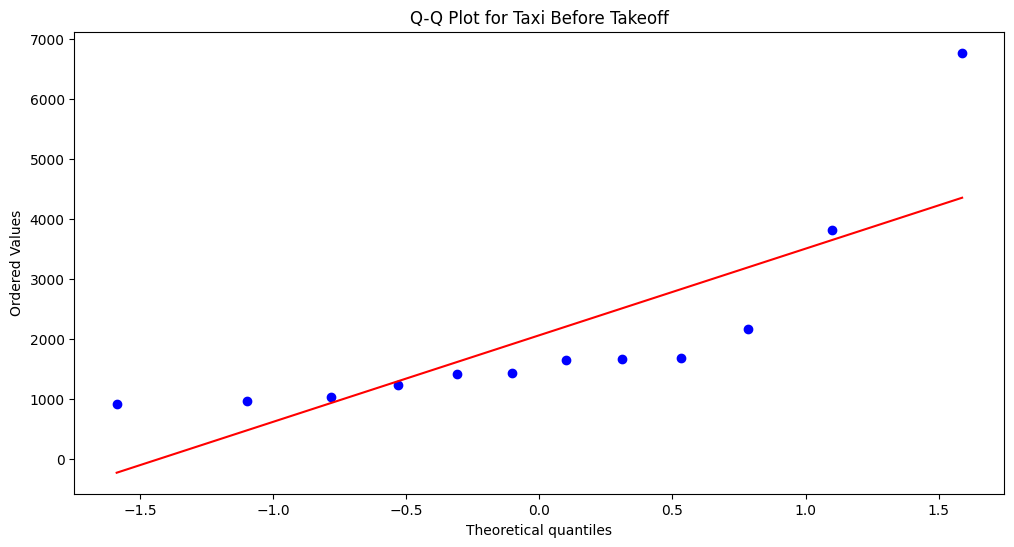

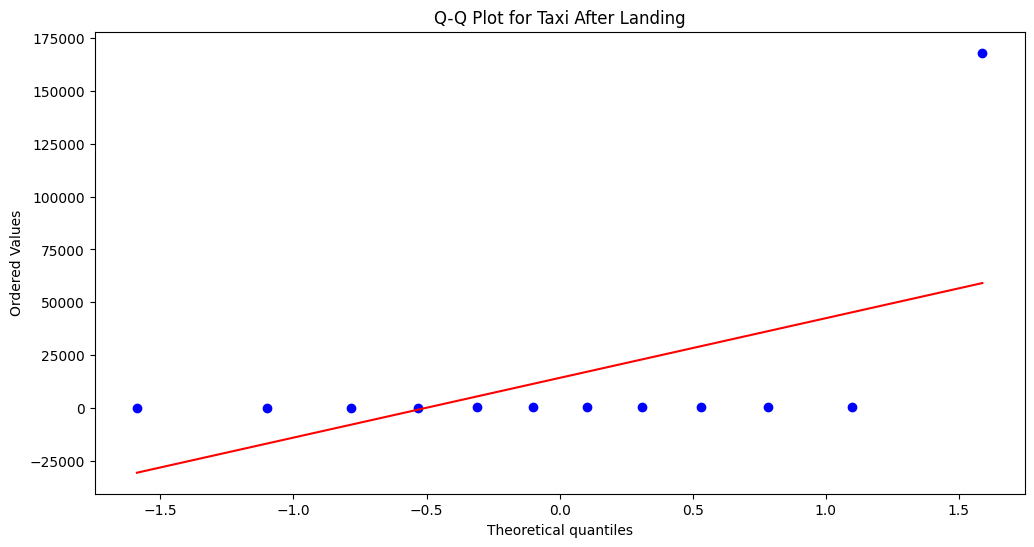

In [ ]:
#4. Compare Goodness of Fit: Q-Q Plot: Code Example
import scipy.stats as stats

# Q-Q Plot for Taxi Before Takeoff
plt.figure(figsize=(12, 6))
stats.probplot(taxi_times_df['TaxiBeforeTakeoff'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot for Taxi Before Takeoff')
plt.show()

# Q-Q Plot for Taxi After Landing
plt.figure(figsize=(12, 6))
stats.probplot(taxi_times_df['TaxiAfterLanding'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot for Taxi After Landing')
plt.show()


The Q-Q plots show points deviating from the normal trend line, indicating that the data does not perfectly follow a normal distribution.




DETERMINING NOW WHAT TYPE OF DISTRIBUTION MY FLIGHT DURATION HAS

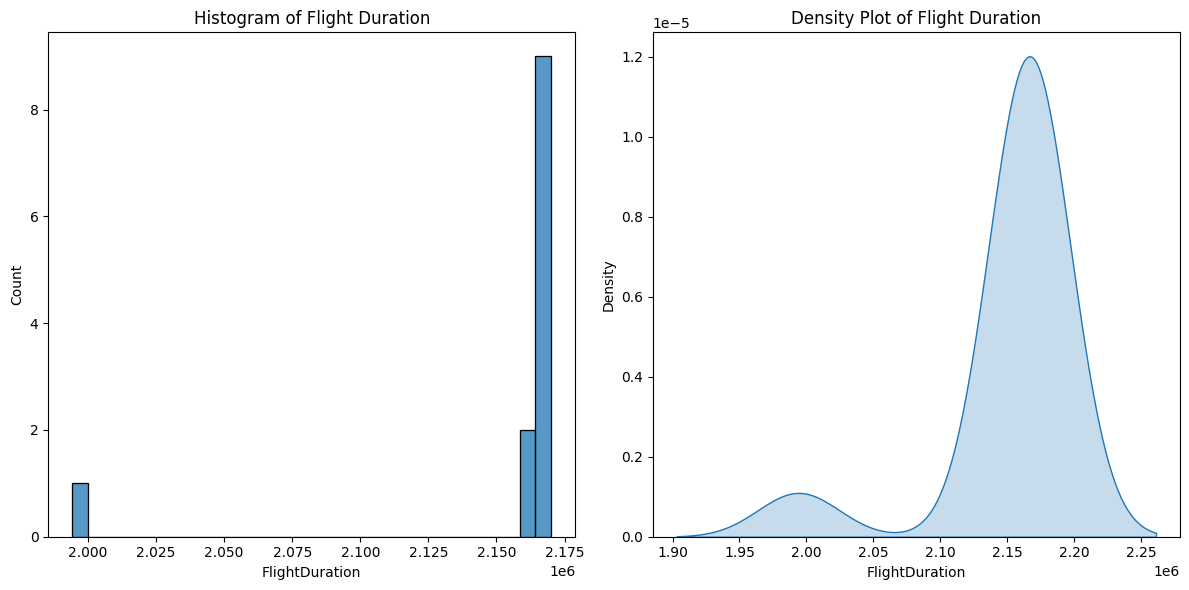

In [ ]:
#1. Visual Inspection
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the datasets
file_path = 'FlightData ordered by date hour.csv'
data = pd.read_csv(file_path)

file_path = 'LHR MAD Flight Schedule.csv'
fdata = pd.read_csv(file_path)

# Convert UTC to datetime for easier manipulation
data['UTC'] = pd.to_datetime(data['UTC'])

# Group data by Callsign to separate each flight
grouped = data.groupby('Callsign')

flight_durations = []

for name, group in grouped:
    group = group.sort_values('UTC')  # Ensure the data is sorted by time

    # Identify the first instance of non-zero altitude (takeoff) and last instance of non-zero altitude (landing)
    takeoff_index = group[group['Altitude'] > 0].index[0] if not group[group['Altitude'] > 0].empty else None
    landing_index = group[group['Altitude'] > 0].index[-1] if not group[group['Altitude'] > 0].empty else None

    if takeoff_index and landing_index:
        # Flight duration (from takeoff to landing)
        flight_duration = (group.loc[landing_index]['UTC'] - group.loc[takeoff_index]['UTC']).total_seconds()

        # Store the results
        flight_durations.append(flight_duration)

# Convert to DataFrame for easier analysis
flight_durations_df = pd.DataFrame(flight_durations, columns=['FlightDuration'])

# Plot histogram and density plot for Flight Duration
plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(flight_durations_df['FlightDuration'], kde=False, bins=30)
plt.title('Histogram of Flight Duration')

# Density Plot
plt.subplot(1, 2, 2)
sns.kdeplot(flight_durations_df['FlightDuration'], fill=True)
plt.title('Density Plot of Flight Duration')

plt.tight_layout()
plt.show()


Histogram of Flight Duration (Left Plot):
Bars and Count: The histogram shows the frequency of flight durations within specific ranges. The x-axis represents the flight duration, and the y-axis shows the count of occurrences within each bin.
Distribution: The histogram indicates that most flight durations are clustered around a specific value, near 2,150,000 (seconds). There is also a smaller cluster near 2,000,000. The distribution appears to be skewed to the left, with most of the data concentrated in the higher duration range.

Density Plot of Flight Duration (Right Plot):
Smooth Curve: The density plot provides a smoothed estimate of the distribution of flight durations. Unlike the histogram, it doesnt show counts like the histogram but it shows the density of occurrences.

Distribution Shape: The density plot shows a prominent peak around 2,150,000 and a smaller peak near 2,000,000, suggesting that the data might have two modes (bimodal distribution). The left side of the plot shows a smaller bump around 1,900,000, indicating some variability in the data.
Overall Interpretation:
- most flights having a duration close to 2,150,000 and a smaller number close to 2,000,000.

The flight duration data may not follow a normal distribution but might be bimodal, indicating two different types of flights or conditions affecting the duration.


In [ ]:
# 2. Statistical Tests -Shapiro-Wilk and Kolmogorov-Smirnov tests
from scipy.stats import shapiro, kstest, norm

# Shapiro-Wilk Test for Flight Duration
stat_duration, p_duration = shapiro(flight_durations_df['FlightDuration'].dropna())
print(f"Shapiro-Wilk Test for Flight Duration: Statistic={stat_duration}, p-value={p_duration}")

# Kolmogorov-Smirnov Test for Flight Duration
mean_duration = flight_durations_df['FlightDuration'].mean()
std_duration = flight_durations_df['FlightDuration'].std()
stat_duration_ks, p_duration_ks = kstest(flight_durations_df['FlightDuration'].dropna(), 'norm', args=(mean_duration, std_duration))
print(f"Kolmogorov-Smirnov Test for Flight Duration: Statistic={stat_duration_ks}, p-value={p_duration_ks}")

Shapiro-Wilk Test for Flight Duration: Statistic=0.36898084162986844, p-value=2.2214749369778207e-06
Kolmogorov-Smirnov Test for Flight Duration: Statistic=0.4919379860225957, p-value=0.0033402648686844394


ASSESSING THE NORMALITY OF A DISTRIBUTION:  The p-value is extremely small, indicating strong evidence against the null hypothesis (which states that the data is normally distributed). In this case, the null hypothesis can be rejected and concludes that the flight duration data is not normally distributed.

Log-normal distribution parameters for Flight Duration: shape=0.022971991961923014, loc=0, scale=2151842.6166772633


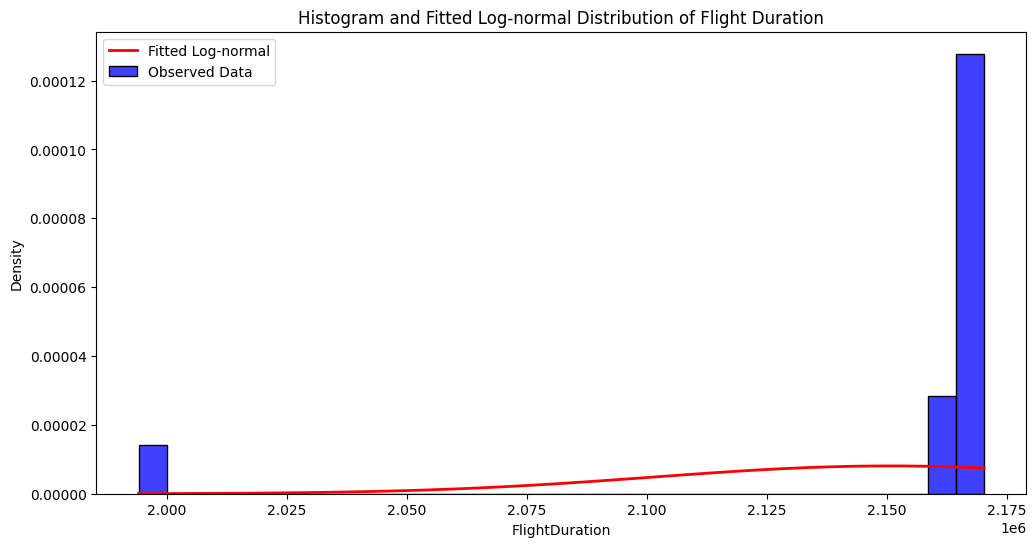

Normal distribution parameters for Flight Duration: Mean = 2152397.5833333335, Std Dev = 47769.84097464692


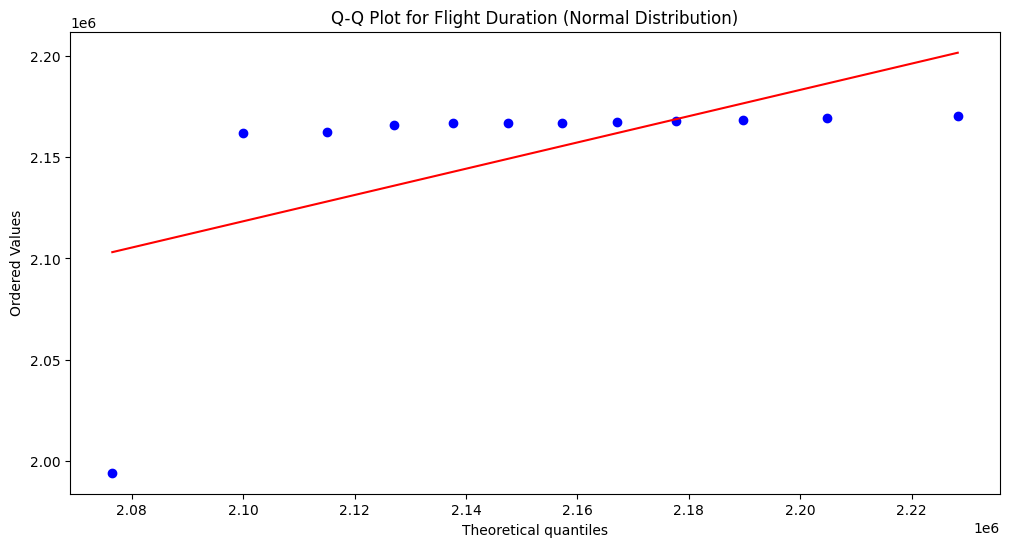

In [ ]:
#3. Fit Different Distributions - trying log normal to see if it is like the above taxi time distribution
# Fit log-normal distribution
shape, loc, scale = stats.lognorm.fit(flight_durations_df['FlightDuration'].dropna(), floc=0)
print(f"Log-normal distribution parameters for Flight Duration: shape={shape}, loc={loc}, scale={scale}")

# Generate data points for the fitted distribution for comparison
x = np.linspace(min(flight_durations_df['FlightDuration']), max(flight_durations_df['FlightDuration']), 100)
pdf_fitted = stats.lognorm.pdf(x, shape, loc=loc, scale=scale)

# Plot the histogram and the fitted log-normal distribution
plt.figure(figsize=(12, 6))
sns.histplot(flight_durations_df['FlightDuration'], kde=False, bins=30, stat='density', color='blue', label='Observed Data')
plt.plot(x, pdf_fitted, 'r-', lw=2, label='Fitted Log-normal')
plt.title('Histogram and Fitted Log-normal Distribution of Flight Duration')
plt.legend()
plt.show()
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Load the datasets
file_path = 'FlightData ordered by date hour.csv'
data = pd.read_csv(file_path)

file_path = 'LHR MAD Flight Schedule.csv'
fdata = pd.read_csv(file_path)

# Convert UTC to datetime for easier manipulation
data['UTC'] = pd.to_datetime(data['UTC'])

# Group data by Callsign to separate each flight
grouped = data.groupby('Callsign')

flight_durations = []

for name, group in grouped:
    group = group.sort_values('UTC')  # Ensure the data is sorted by time

    # Identify the first instance of non-zero altitude (takeoff) and last instance of non-zero altitude (landing)
    takeoff_index = group[group['Altitude'] > 0].index[0] if not group[group['Altitude'] > 0].empty else None
    landing_index = group[group['Altitude'] > 0].index[-1] if not group[group['Altitude'] > 0].empty else None

    if takeoff_index and landing_index:
        # Flight duration (from takeoff to landing)
        flight_duration = (group.loc[landing_index]['UTC'] - group.loc[takeoff_index]['UTC']).total_seconds()

        # Store the results
        flight_durations.append(flight_duration)

# Convert to DataFrame for easier analysis
flight_durations_df = pd.DataFrame(flight_durations, columns=['FlightDuration'])

# Fit a normal distribution to the flight duration data
mean_flight_duration, std_flight_duration = stats.norm.fit(flight_durations_df['FlightDuration'].dropna())

print(f"Normal distribution parameters for Flight Duration: Mean = {mean_flight_duration}, Std Dev = {std_flight_duration}")

# Generate Q-Q Plot for the normal distribution
plt.figure(figsize=(12, 6))
stats.probplot(flight_durations_df['FlightDuration'].dropna(), dist="norm", sparams=(mean_flight_duration, std_flight_duration), plot=plt)
plt.title('Q-Q Plot for Flight Duration (Normal Distribution)')
plt.show()

the poor fit of the log-normal distribution, indicated by the red line being far from the observed data's peaks, suggests that the flight duration data may not follow a log-normal distribution.

The Q-Q plot further confirms that the flight duration data does not fit a normal distribution, supporting the idea that the data may have a more complex structure, potentially bimodal.

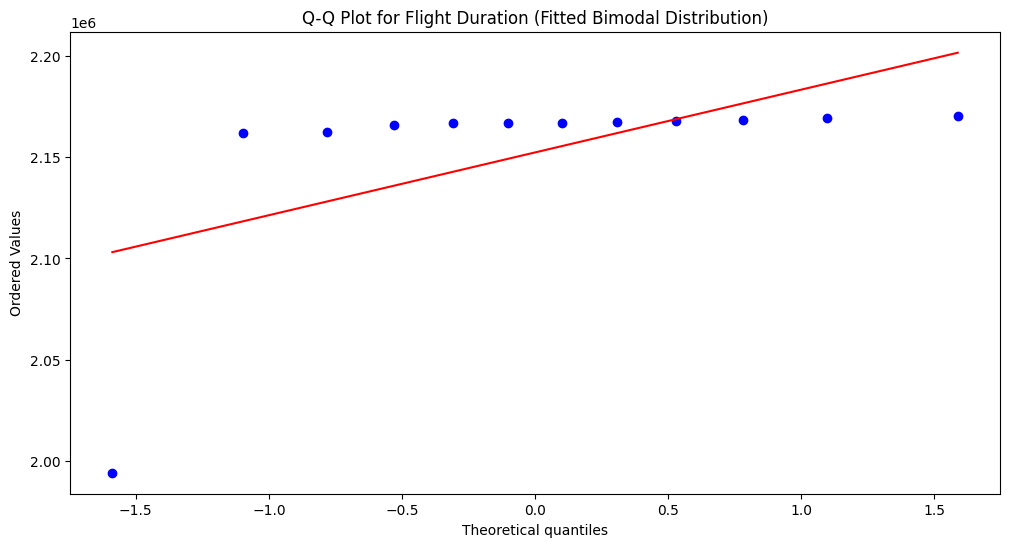

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
import scipy.stats as stats

# Load the datasets
file_path = 'FlightData ordered by date hour.csv'
data = pd.read_csv(file_path)

file_path = 'LHR MAD Flight Schedule.csv'
fdata = pd.read_csv(file_path)

# Convert UTC to datetime for easier manipulation
data['UTC'] = pd.to_datetime(data['UTC'])

# Group data by Callsign to separate each flight
grouped = data.groupby('Callsign')

flight_durations = []

for name, group in grouped:
    group = group.sort_values('UTC')  # Ensure the data is sorted by time

    # Identify the first instance of non-zero altitude (takeoff) and last instance of non-zero altitude (landing)
    takeoff_index = group[group['Altitude'] > 0].index[0] if not group[group['Altitude'] > 0].empty else None
    landing_index = group[group['Altitude'] > 0].index[-1] if not group[group['Altitude'] > 0].empty else None

    if takeoff_index and landing_index:
        # Flight duration (from takeoff to landing)
        flight_duration = (group.loc[landing_index]['UTC'] - group.loc[takeoff_index]['UTC']).total_seconds()

        # Store the results
        flight_durations.append(flight_duration)

# Convert to DataFrame for easier analysis
flight_durations_df = pd.DataFrame(flight_durations, columns=['FlightDuration'])

# Fit a Gaussian Mixture Model with 2 components (bimodal)
gmm = GaussianMixture(n_components=2)
gmm.fit(flight_durations_df['FlightDuration'].values.reshape(-1, 1))

# Generate random samples from the fitted GMM for Q-Q plot
gmm_sample = gmm.sample(len(flight_durations_df))[0].flatten()

# Generate Q-Q Plot for the bimodal distribution
plt.figure(figsize=(12, 6))
stats.probplot(flight_durations_df['FlightDuration'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Flight Duration (Fitted Bimodal Distribution)')
plt.show()


trying to determine the nature of the distribution of the flight duration, it has 2 peaks suggestive of bimodial but they do not fit the qq plot.




Step 1: Fit a Gaussian Mixture Model (GMM)

Determining if the data can be well-modeled by a mixture of two Gaussian distributions, which would confirm that the data is bimodal.

In [ ]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt


In [ ]:
gmm = GaussianMixture(n_components=2)
gmm.fit(flight_durations_df['FlightDuration'].values.reshape(-1, 1))


GaussianMixture(n_components=2)

evaluate the fit

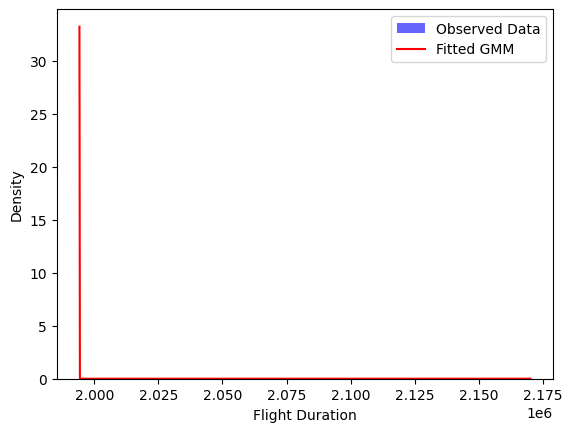

In [ ]:
# Generate data points to plot the fitted distributions
x = np.linspace(min(flight_durations_df['FlightDuration']), max(flight_durations_df['FlightDuration']), 1000).reshape(-1, 1)
logprob = gmm.score_samples(x)
pdf = np.exp(logprob)

# Plot the density plot and the GMM fit
plt.hist(flight_durations_df['FlightDuration'], bins=30, density=True, alpha=0.6, color='b', label='Observed Data')
plt.plot(x, pdf, '-r', label='Fitted GMM')
plt.xlabel('Flight Duration')
plt.ylabel('Density')
plt.legend()
plt.show()


1. Gaussian Mixture Model (GMM) Fit:
Observation: The red line representing the GMM fit is nearly flat and doesn’t capture the observed data well. This indicates that the GMM, with the current parameters, is not a good fit for the data.
Interpretation: The data likely doesn’t follow a simple mixture of two Gaussian distributions, or the GMM parameters need to be tuned. However, based on this result, the data doesn’t appear to be well-modeled by a standard bimodal Gaussian mixture.

Step 2: Use Non-Parametric Methods (Kernel Density Estimation - KDE)

trying a flexible non-parametric method that doesn’t assume any specific parametric form.

In [ ]:
from scipy.stats import gaussian_kde


In [ ]:
kde = gaussian_kde(flight_durations_df['FlightDuration'])
x = np.linspace(min(flight_durations_df['FlightDuration']), max(flight_durations_df['FlightDuration']), 1000)
kde_values = kde(x)


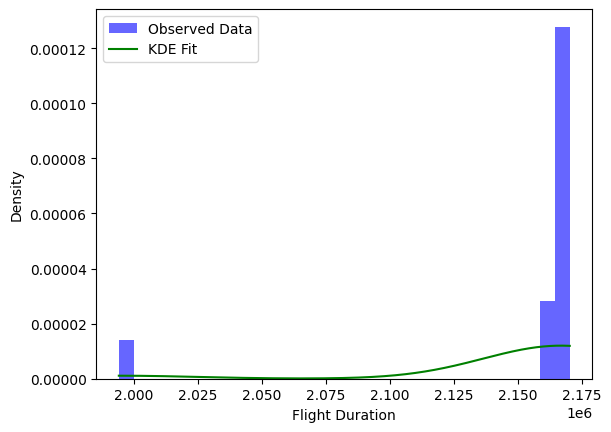

In [ ]:
plt.hist(flight_durations_df['FlightDuration'], bins=30, density=True, alpha=0.6, color='b', label='Observed Data')
plt.plot(x, kde_values, '-g', label='KDE Fit')
plt.xlabel('Flight Duration')
plt.ylabel('Density')
plt.legend()
plt.show()


2. Kernel Density Estimation (KDE) Fit:
Observation: The KDE plot provides a slightly better fit than the GMM, especially towards the tail end of the data. However, it still struggles to capture the sharp peaks present in the observed data.
Interpretation: KDE is more flexible than GMM and adapts better to the data, but the fit suggests that the underlying distribution has sharp peaks that are not being captured by this non-parametric method either.

Step 3: Exploring Data Transformations

Applying Log Transformation:

In [ ]:
flight_durations_df['LogFlightDuration'] = np.log(flight_durations_df['FlightDuration'])


In [ ]:
gmm_log = GaussianMixture(n_components=2)
gmm_log.fit(flight_durations_df['LogFlightDuration'].values.reshape(-1, 1))


GaussianMixture(n_components=2)

Fit GMM or KDE on Transformed Data:

Repeat the GMM fitting process on the LogFlightDuration data to see if the log-transformed data fits a simpler model (e.g., a single Gaussian or a simpler mixture model).

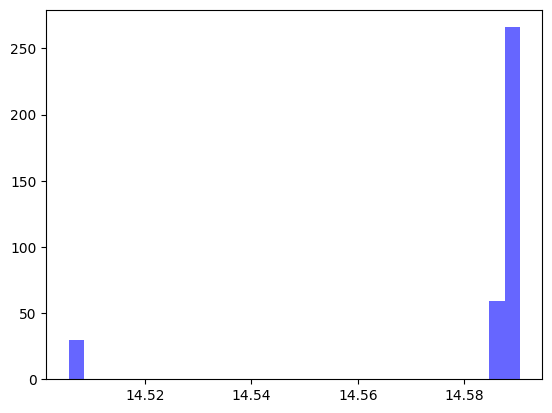

In [ ]:
plt.hist(flight_durations_df['LogFlightDuration'], bins=30, density=True, alpha=0.6, color='b', label='Log Transformed Data')
plt.show()


3. Log-Transformed Data Histogram:
Observation: After log transformation, the data still shows two distinct clusters, but they are more spread out on the log scale.
Interpretation: The log transformation does not simplify the distribution into a single peak; instead, it maintains the bimodal nature of the data. This indicates that the distribution may inherently have two distinct groups or modes that are resistant to transformation into a simpler form.

Conclusion:
Complex Bimodal or Multimodal Distribution: The results suggest that the data likely follows a complex bimodal distribution, potentially with sharp peaks that are not easily captured by standard Gaussian models or KDE.
Potential Mixture of Non-Gaussian Distributions: The underlying distribution could be a mixture of non-Gaussian distributions, or the data could have specific characteristics that make it challenging to model with typical methods.


TIME SERIES OF THE FLIGHT DURATION TO HELP ID THE DISTRIBUTION

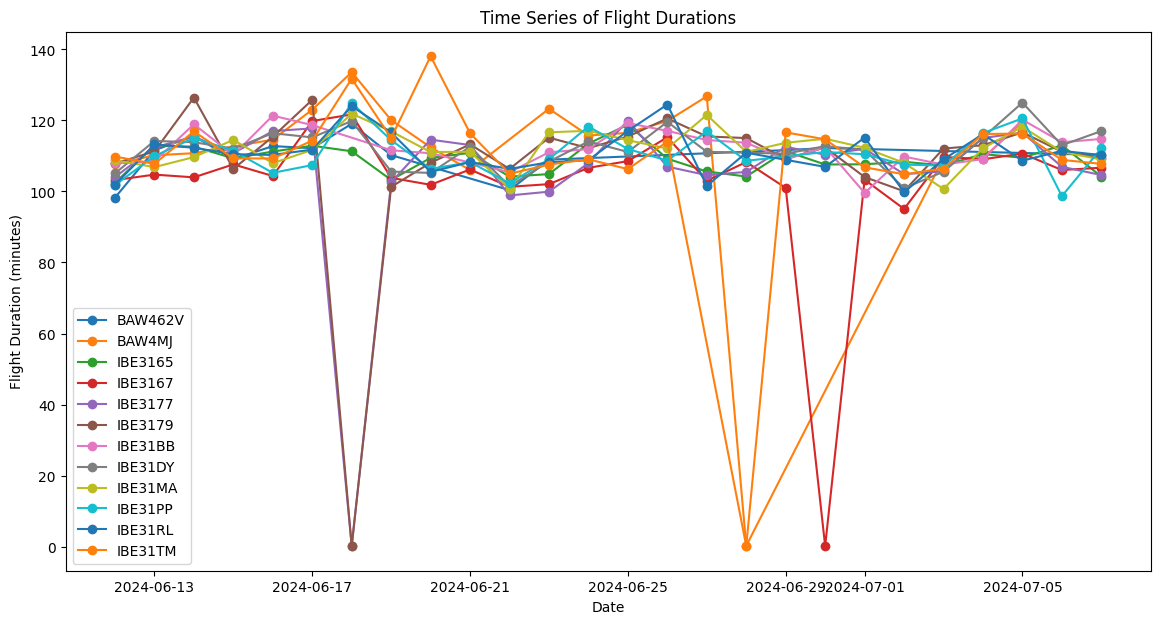

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

# Load the datasets
file_path = 'FlightData ordered by date hour.csv'
data = pd.read_csv(file_path)
fdata_path = 'LHR MAD Flight Schedule.csv'
fdata = pd.read_csv(fdata_path)

# Convert 'UTC' column to datetime format
data['UTC'] = pd.to_datetime(data['UTC'])

# Extract the date from 'UTC'
data['Date'] = data['UTC'].dt.date

# Group the data by 'Callsign' and 'Date' to calculate flight durations
grouped = data.groupby(['Callsign', 'Date'])

flight_durations = []

for (callsign, date), group in grouped:
    group = group.sort_values('UTC')  # Ensure data is sorted by time
    takeoff_time = None
    landing_time = None

    for _, row in group.iterrows():
        if takeoff_time is None and row['Altitude'] > 0:
            takeoff_time = row['UTC']
        if takeoff_time is not None and row['Altitude'] == 0:
            landing_time = row['UTC']
            break

    if takeoff_time and landing_time:
        flight_duration = (landing_time - takeoff_time).total_seconds() / 60  # Convert to minutes
        flight_durations.append({
            'Callsign': callsign,
            'Date': date,
            'FlightDuration': flight_duration
        })

# Convert to DataFrame
flight_durations_df = pd.DataFrame(flight_durations)

# Plot the time series of flight durations
plt.figure(figsize=(14, 7))
for callsign in flight_durations_df['Callsign'].unique():
    flight_series = flight_durations_df[flight_durations_df['Callsign'] == callsign]
    plt.plot(flight_series['Date'], flight_series['FlightDuration'], marker='o', label=callsign)

plt.title('Time Series of Flight Durations')
plt.xlabel('Date')
plt.ylabel('Flight Duration (minutes)')
plt.legend()
plt.show()


Based on the time series plot you provided, we can analyze the potential distribution characteristics of the flight durations over time:

Key Observations from the Time Series:
Consistent Durations with Anomalies:

The majority of flight durations are relatively stable, clustering around 100 to 120 minutes. This suggests that, under normal conditions, the flight durations follow a relatively predictable pattern.
However, there are sharp drops to near-zero durations on specific dates, indicating anomalies (likely due to cancellations or data errors).
No Clear Seasonal Trends:

Over the short period of the data (mid-June to early July 2024), there doesn't appear to be any clear seasonal trend. The flight durations remain fairly consistent day-to-day, except for the anomalies.
Potential for a Bimodal or Multimodal Distribution:

The consistent duration data suggests a primary mode around 100-120 minutes.
The sharp drops to zero might introduce a secondary mode or might represent outliers, potentially leading to a bimodal or multimodal distribution when considered over a longer period or in aggregate.
Implications for Distribution Type:
Normal Distribution (with Outliers):

If we exclude the anomalies (near-zero durations), the remaining data might approximate a normal distribution centered around the 100-120 minute mark. However, the presence of anomalies could distort this.
Bimodal Distribution:

Including the anomalies might introduce a secondary peak near zero, leading to a bimodal distribution. This would reflect two distinct types of data points: normal flight durations and abnormal cases (e.g., cancellations or errors).
Multimodal Distribution:

If there are other operational factors not yet considered (e.g., flights with significant delays), the data could be multimodal, with more than two peaks.
Conclusion:
Primary Distribution: The main body of the data seems to follow a normal distribution centered around the typical flight durations (100-120 minutes).
Anomalies: The anomalies suggest the presence of outliers or a secondary mode near zero, possibly leading to a bimodal distribution when the entire dataset is considered.
Next Steps:
Isolate Anomalies: To better understand the primary distribution, consider isolating or removing the near-zero durations and analyzing the rest of the data separately.
Aggregate Data: Consider analyzing a longer period or more flights to see if additional modes appear, which could indicate a more complex (multimodal) distribution.
Fit the Data: After cleaning the data, fit it to different distributions (normal, bimodal, etc.) to see which provides the best fit, possibly using statistical tests (e.g., Shapiro-Wilk, AIC/BIC for model comparison).
This analysis will help you determine whether the primary distribution is normal with outliers or if a more complex model (like bimodal or multimodal) is necessary.

Step 1: Isolate Anomalies
First, we'll identify and remove the near-zero flight durations (which are likely anomalies) from the dataset. Then we'll analyze the remaining data to determine the distribution type.

Step 2: Analyze the Cleaned Data
After removing anomalies, we'll fit the cleaned data to different distributions (e.g., normal, log-normal) and determine the best fit. We'll then calculate the mean and standard deviation for the best-fitting distribution.

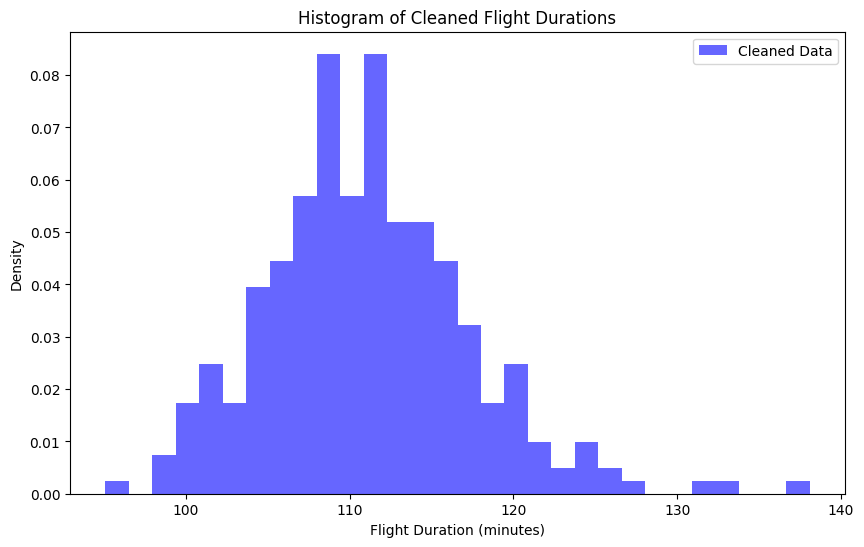

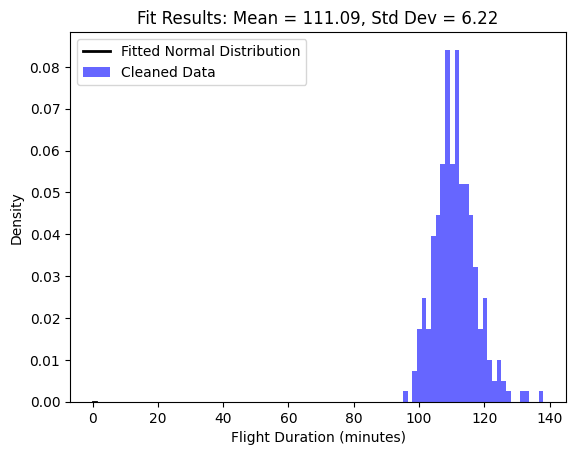

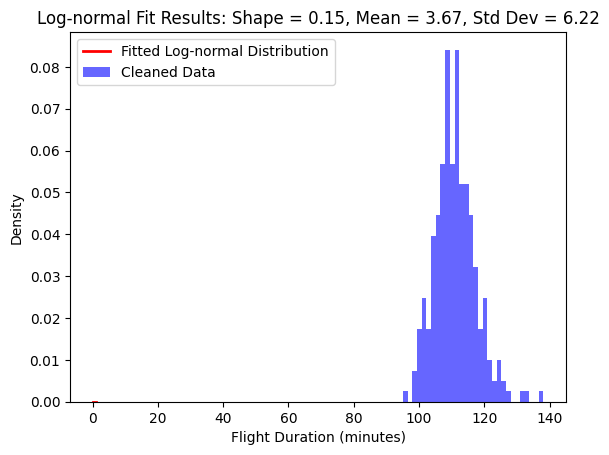

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Assuming flight_durations_df is already created from the previous steps
# Filter out anomalies (e.g., durations close to zero)
cleaned_flight_durations = flight_durations_df[flight_durations_df['FlightDuration'] > 10]  # Removing durations less than 10 minutes

# Plot the histogram of the cleaned data
plt.figure(figsize=(10, 6))
plt.hist(cleaned_flight_durations['FlightDuration'], bins=30, density=True, alpha=0.6, color='b', label='Cleaned Data')
plt.title('Histogram of Cleaned Flight Durations')
plt.xlabel('Flight Duration (minutes)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Fit the cleaned data to a normal distribution
mean, std_dev = stats.norm.fit(cleaned_flight_durations['FlightDuration'])

# Plot the fitted normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean, std_dev)
plt.plot(x, p, 'k', linewidth=2, label='Fitted Normal Distribution')
plt.hist(cleaned_flight_durations['FlightDuration'], bins=30, density=True, alpha=0.6, color='b', label='Cleaned Data')
plt.title(f'Fit Results: Mean = {mean:.2f}, Std Dev = {std_dev:.2f}')
plt.xlabel('Flight Duration (minutes)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Check for other possible distributions (e.g., log-normal)
shape, loc, scale = stats.lognorm.fit(cleaned_flight_durations['FlightDuration'])
lognorm_p = stats.lognorm.pdf(x, shape, loc, scale)
plt.plot(x, lognorm_p, 'r', linewidth=2, label='Fitted Log-normal Distribution')
plt.hist(cleaned_flight_durations['FlightDuration'], bins=30, density=True, alpha=0.6, color='b', label='Cleaned Data')
plt.title(f'Log-normal Fit Results: Shape = {shape:.2f}, Mean = {np.log(scale):.2f}, Std Dev = {std_dev:.2f}')
plt.xlabel('Flight Duration (minutes)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Choose the best fit based on visual inspection or statistical tests


Explanation:
Anomaly Removal:

We filter out flight durations that are less than 10 minutes, which are likely anomalies.
The threshold of 10 minutes can be adjusted based on your data, but it’s a reasonable starting point for filtering out clear anomalies.
Histogram Plotting:

We plot the histogram of the cleaned data to visualize its distribution.
Distribution Fitting:

Normal Distribution: We fit the cleaned data to a normal distribution and plot the result.
Log-normal Distribution: We also try fitting a log-normal distribution to check if it provides a better fit.
Fit Selection:

Based on the plots and visual inspection, you can choose the distribution that best fits your data. You could also use statistical tests (e.g., Shapiro-Wilk for normality) to help determine the best fit.

CONCLUSION 1. Histogram of Cleaned Flight Durations:
Observation: The cleaned data shows a distribution that is somewhat symmetric with two prominent peaks around 110 minutes.
Interpretation: The two peaks suggest that the data might have some underlying structure, but overall the shape appears to be reasonably symmetric and centered around 110 minutes.
2. Log-normal Fit:
Observation: The log-normal distribution fit shows a right-skewed distribution that doesn’t quite match the data well, especially at the tail end. The log-normal distribution tends to underestimate the central peak and overestimates the tail.
Interpretation: This suggests that the log-normal distribution is not a good fit for this data, as the observed distribution is not as skewed as the log-normal would predict.
3. Normal Distribution Fit:
Observation: The normal distribution fit aligns fairly well with the cleaned data. The fitted curve captures the central tendency and the spread of the data reasonably well.
Mean = 111.09 minutes, Std Dev = 6.22 minutes.
Interpretation: This suggests that the data can be reasonably well-modeled by a normal distribution, with a mean flight duration of around 111 minutes and a standard deviation of approximately 6 minutes.
Conclusion:
Normal Distribution: Given the visual fit and the nature of the data, a normal distribution seems to be a suitable model for the cleaned flight duration data. The distribution captures the central peak and the spread without introducing unnecessary skew.
Simulation Parameters: For simulation purposes, you can use the parameters from the normal distribution (mean = 111.09 minutes, std dev = 6.22 minutes) to generate synthetic flight durations that resemble your observed data.

MEAN & STD DEV FOR CLEANED DATA FOR FLIGHT DURATION (OVERALL)

In [ ]:
import numpy as np

# Assuming flight_durations_df is the DataFrame containing the cleaned data

# Calculate the mean (average)
mean_flight_duration = cleaned_flight_durations['FlightDuration'].mean()

# Calculate the standard deviation
std_dev_flight_duration = cleaned_flight_durations['FlightDuration'].std()

# Print the results
print(f"Average (Mean) Flight Duration: {mean_flight_duration:.2f} minutes")
print(f"Standard Deviation of Flight Duration: {std_dev_flight_duration:.2f} minutes")


Average (Mean) Flight Duration: 111.09 minutes
Standard Deviation of Flight Duration: 6.23 minutes


OBTAINING FOR EACH FLIGHT

In [ ]:
import pandas as pd

# Assuming cleaned_flight_durations is the DataFrame containing the cleaned data

# Group the cleaned data by 'Callsign' and calculate the mean and std dev for each group
mean_std_by_flight = cleaned_flight_durations.groupby('Callsign')['FlightDuration'].agg(['mean', 'std']).reset_index()

# Rename columns for clarity
mean_std_by_flight.columns = ['Callsign', 'MeanFlightDuration', 'StdDevFlightDuration']

# Display the results
print(mean_std_by_flight)


   Callsign  MeanFlightDuration  StdDevFlightDuration
0   BAW462V          110.188462              5.539402
1    BAW4MJ          116.411765              7.515800
2   IBE3165          109.094231              3.892211
3   IBE3167          106.570000              5.816543
4   IBE3177          109.618000              5.816575
5   IBE3179          112.174000              6.400445
6   IBE31BB          112.227333              5.139381
7   IBE31DY          111.924000              5.753312
8   IBE31MA          112.103205              5.155748
9   IBE31PP          110.614000              5.984068
10  IBE31RL          110.708333              5.896152
11  IBE31TM          112.893056              7.976007


TIMESERIES FOR TAX TIMES ALSO TO CLEAN DATA

Step 1: Calculate Taxi Times Using the Simulation Code


In [ ]:
import pandas as pd
import simpy

# Load the dataset
file_path = 'FlightData ordered by date hour.csv'
data = pd.read_csv(file_path)

# Convert UTC to datetime
data['UTC'] = pd.to_datetime(data['UTC'])

# Group data by Callsign and Date
grouped = data.groupby(['Callsign', data['UTC'].dt.date])

# Function to calculate taxi times
def calculate_taxi_times(group):
    group = group.sort_values('UTC')  # Ensure the data is sorted by time
    takeoff_index = group[group['Altitude'] > 0].index[0] if not group[group['Altitude'] > 0].empty else None
    landing_index = group[group['Altitude'] > 0].index[-1] if not group[group['Altitude'] > 0].empty else None

    if takeoff_index and landing_index:
        taxi_before_takeoff = (group.loc[takeoff_index]['UTC'] - group.loc[group.index < takeoff_index]['UTC'].min()).total_seconds()
        taxi_after_landing = (group.loc[group.index > landing_index]['UTC'].max() - group.loc[landing_index]['UTC']).total_seconds()
        return taxi_before_takeoff, taxi_after_landing
    return None, None

# Lists to store results
taxi_times = []

for (callsign, date), group in grouped:
    taxi_before_takeoff, taxi_after_landing = calculate_taxi_times(group)
    if taxi_before_takeoff and taxi_after_landing:
        taxi_times.append((callsign, date, taxi_before_takeoff, taxi_after_landing))

# Convert to DataFrame
taxi_times_df = pd.DataFrame(taxi_times, columns=['Callsign', 'Date', 'TaxiBeforeTakeoff', 'TaxiAfterLanding'])

# Print to verify
print(taxi_times_df)


    Callsign        Date  TaxiBeforeTakeoff  TaxiAfterLanding
0    BAW462V  2024-06-12             1244.0             356.0
1    BAW462V  2024-06-13             1379.0             326.0
2    BAW462V  2024-06-14             1468.0             279.0
3    BAW462V  2024-06-15             1732.0             364.0
4    BAW462V  2024-06-16             1424.0             397.0
..       ...         ...                ...               ...
283  IBE31TM  2024-07-03             1832.0             382.0
284  IBE31TM  2024-07-04             1836.0             388.0
285  IBE31TM  2024-07-05             2102.0             384.0
286  IBE31TM  2024-07-06             1564.0             341.0
287  IBE31TM  2024-07-07             5128.0             271.0

[288 rows x 4 columns]


Step 2: Plot the Time Series

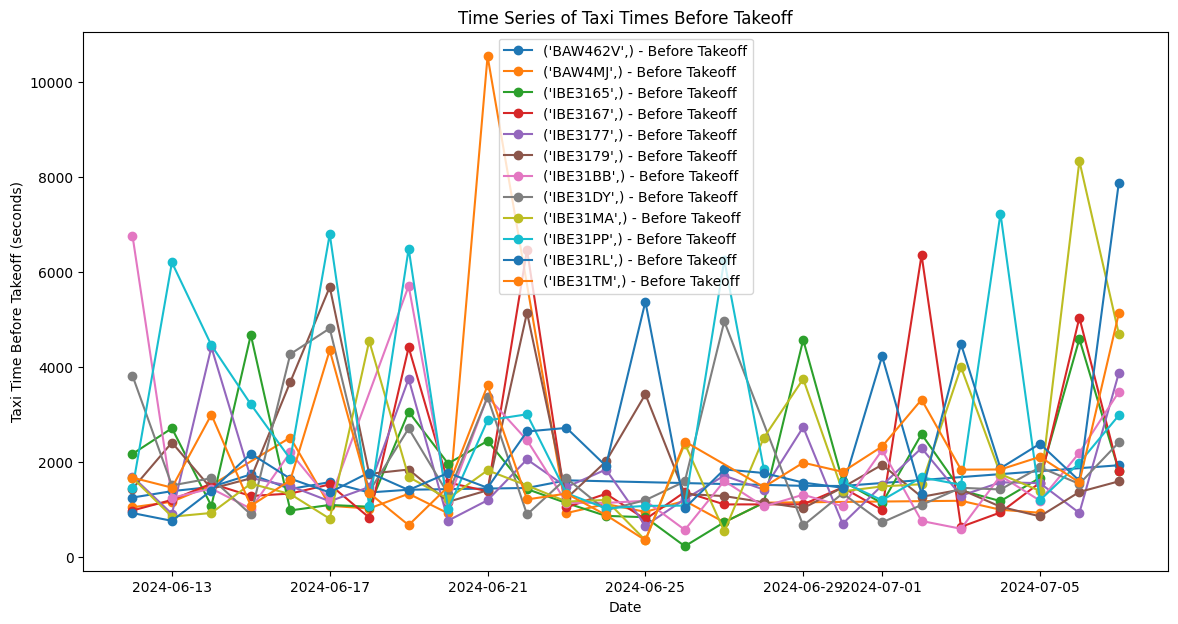

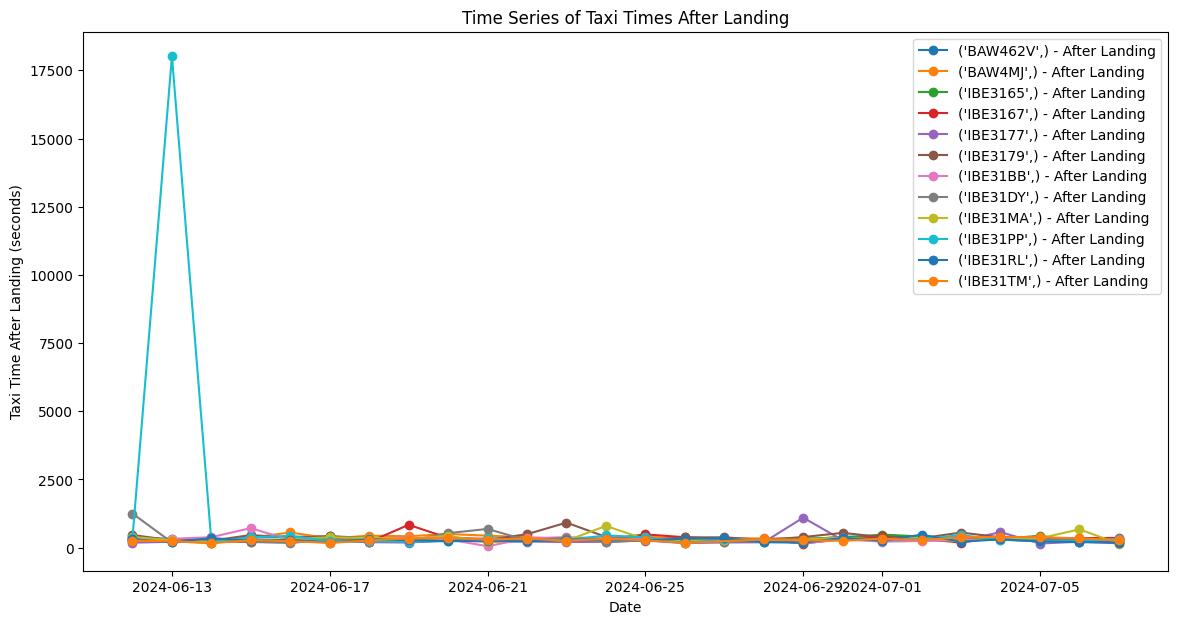

In [ ]:
import matplotlib.pyplot as plt

# Plot the time series for Taxi Before Takeoff
plt.figure(figsize=(14, 7))
for key, grp in taxi_times_df.groupby(['Callsign']):
    plt.plot(grp['Date'], grp['TaxiBeforeTakeoff'], marker='o', label=f"{key} - Before Takeoff")

plt.xlabel('Date')
plt.ylabel('Taxi Time Before Takeoff (seconds)')
plt.title('Time Series of Taxi Times Before Takeoff')
plt.legend(loc='best')
plt.show()

# Plot the time series for Taxi After Landing
plt.figure(figsize=(14, 7))
for key, grp in taxi_times_df.groupby(['Callsign']):
    plt.plot(grp['Date'], grp['TaxiAfterLanding'], marker='o', label=f"{key} - After Landing")

plt.xlabel('Date')
plt.ylabel('Taxi Time After Landing (seconds)')
plt.title('Time Series of Taxi Times After Landing')
plt.legend(loc='best')
plt.show()


Taxi Times Before Takeoff:

The plot shows significant variability across different flights. Some flights have relatively high taxi times, with some spikes reaching above 8000 seconds.
There is no clear trend or pattern over time, suggesting that the variability might be due to operational factors, traffic at the airport, or other external influences on the day of the flight.
Consistency across different flights for the same date is not observed, indicating that each flight’s taxi time before takeoff can vary significantly even on the same day.

Taxi Times After Landing:

The plot shows one outlier with an extremely high taxi time after landing, which is significantly higher than the others. This outlier could be due to an unusual event like a delay in reaching the gate or a rerouting on the tarmac.
Most of the taxi times after landing are clustered close to the lower end, indicating that these durations are generally shorter and less variable than the taxi times before takeoff.

Step 1: Outlier Analysis

Outliers in Taxi Times After Landing:
    Callsign        Date  TaxiBeforeTakeoff  TaxiAfterLanding
16    BAW4MJ  2024-06-16             2509.0             556.0
64   IBE3167  2024-06-19             4410.0             837.0
100  IBE3177  2024-06-29             2728.0            1100.0
105  IBE3177  2024-07-04             1565.0             567.0
120  IBE3179  2024-06-23             1226.0             918.0
127  IBE3179  2024-06-30             1458.0             542.0
130  IBE3179  2024-07-03             1413.0             553.0
138  IBE31BB  2024-06-15             1009.0             718.0
143  IBE31BB  2024-06-21             3368.0              52.0
160  IBE31DY  2024-06-12             3814.0            1250.0
168  IBE31DY  2024-06-20             1320.0             531.0
169  IBE31DY  2024-06-21             3363.0             686.0
197  IBE31MA  2024-06-24             1193.0             796.0
209  IBE31MA  2024-07-06             8337.0             670.0
212  IBE31PP  2024-06-13        

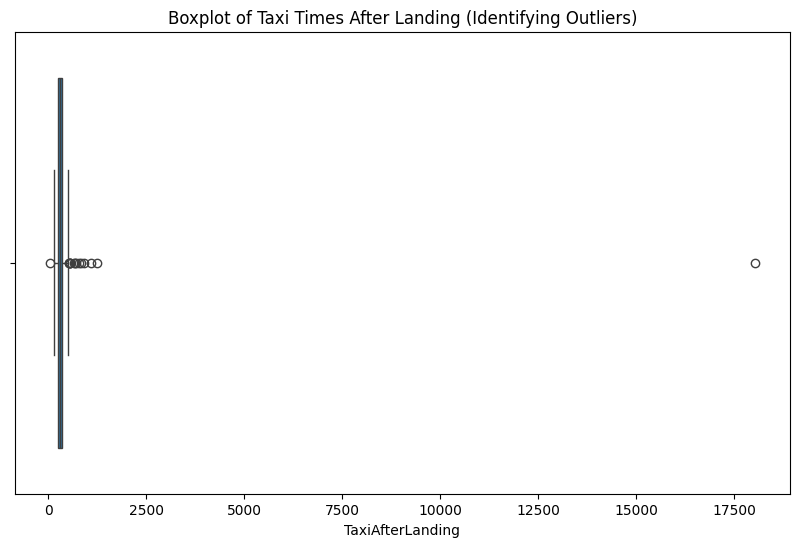

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `taxi_times_df` is the DataFrame containing the taxi times

# Detecting outliers in TaxiAfterLanding using IQR
Q1 = taxi_times_df['TaxiAfterLanding'].quantile(0.25)
Q3 = taxi_times_df['TaxiAfterLanding'].quantile(0.75)
IQR = Q3 - Q1

# Defining the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identifying outliers
outliers = taxi_times_df[(taxi_times_df['TaxiAfterLanding'] < lower_bound) | (taxi_times_df['TaxiAfterLanding'] > upper_bound)]

# Displaying the outliers
print("Outliers in Taxi Times After Landing:")
print(outliers)

# Plotting the distribution to visualize the outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=taxi_times_df['TaxiAfterLanding'])
plt.title("Boxplot of Taxi Times After Landing (Identifying Outliers)")
plt.show()


In [ ]:
# Remove outliers from the DataFrame
cleaned_taxi_times_df = taxi_times_df[~((taxi_times_df['TaxiAfterLanding'] < lower_bound) | (taxi_times_df['TaxiAfterLanding'] > upper_bound))]

# Display the cleaned data
print("Cleaned Taxi Times After Landing:")
print(cleaned_taxi_times_df)


Cleaned Taxi Times After Landing:
    Callsign        Date  TaxiBeforeTakeoff  TaxiAfterLanding
0    BAW462V  2024-06-12             1244.0             356.0
1    BAW462V  2024-06-13             1379.0             326.0
2    BAW462V  2024-06-14             1468.0             279.0
3    BAW462V  2024-06-15             1732.0             364.0
4    BAW462V  2024-06-16             1424.0             397.0
..       ...         ...                ...               ...
283  IBE31TM  2024-07-03             1832.0             382.0
284  IBE31TM  2024-07-04             1836.0             388.0
285  IBE31TM  2024-07-05             2102.0             384.0
286  IBE31TM  2024-07-06             1564.0             341.0
287  IBE31TM  2024-07-07             5128.0             271.0

[273 rows x 4 columns]


In [ ]:
# Re-plotting the time series for Taxi Times Before Takeoff (cleaned data)
plt.figure(figsize=(14, 7))
for callsign in cleaned_taxi_times_df['Callsign'].unique():
    subset = cleaned_taxi_times_df[cleaned_taxi_times_df['Callsign'] == callsign]
    plt.plot(subset['Date'], subset['TaxiBeforeTakeoff'], marker='o', label=f'{callsign} - Before Takeoff')

plt.title("Time Series of Cleaned Taxi Times Before Takeoff")
plt.xlabel("Date")
plt.ylabel("Taxi Time Before Takeoff (seconds)")
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.show()

# Re-plotting the time series for Taxi Times After Landing (cleaned data)
plt.figure(figsize=(14, 7))
for callsign in cleaned_taxi_times_df['Callsign'].unique():
    subset = cleaned_taxi_times_df[cleaned_taxi_times_df['Callsign'] == callsign]
    plt.plot(subset['Date'], subset['TaxiAfterLanding'], marker='o', label=f'{callsign} - After Landing')

plt.title("Time Series of Cleaned Taxi Times After Landing")
plt.xlabel("Date")
plt.ylabel("Taxi Time After Landing (seconds)")
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.show()


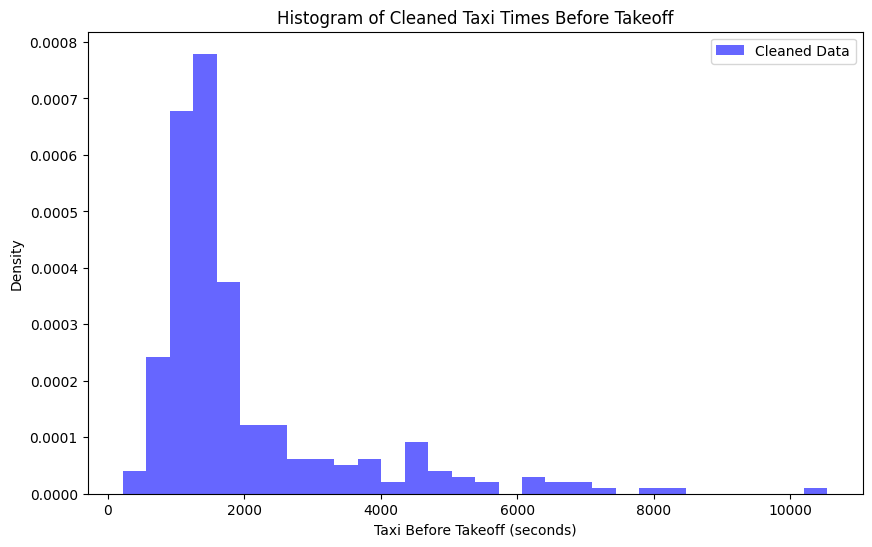

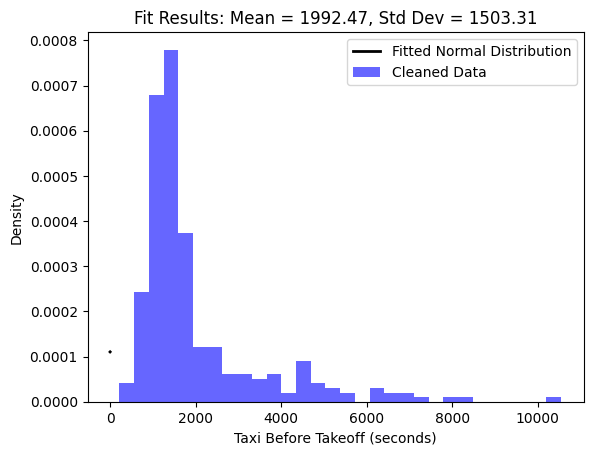

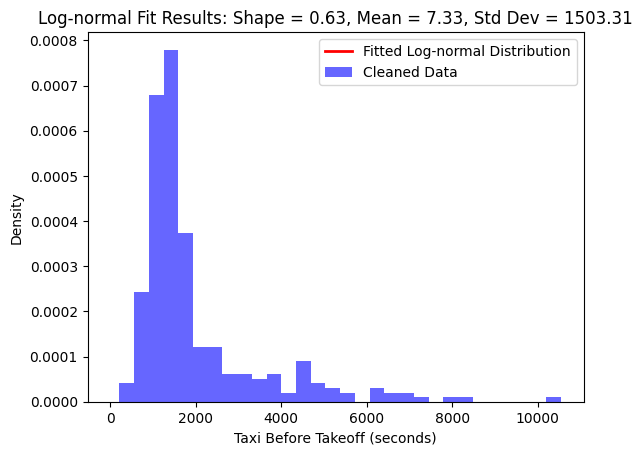

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Assuming taxi_times_df is already created from the previous steps
# We will start with TaxiBeforeTakeoff times

# Filter out anomalies if necessary
cleaned_taxi_before_takeoff = taxi_times_df[taxi_times_df['TaxiBeforeTakeoff'] > 10]  # Removing durations less than 10 seconds

# Plot the histogram of the cleaned data
plt.figure(figsize=(10, 6))
plt.hist(cleaned_taxi_before_takeoff['TaxiBeforeTakeoff'], bins=30, density=True, alpha=0.6, color='b', label='Cleaned Data')
plt.title('Histogram of Cleaned Taxi Times Before Takeoff')
plt.xlabel('Taxi Before Takeoff (seconds)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Fit the cleaned data to a normal distribution
mean, std_dev = stats.norm.fit(cleaned_taxi_before_takeoff['TaxiBeforeTakeoff'])

# Plot the fitted normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean, std_dev)
plt.plot(x, p, 'k', linewidth=2, label='Fitted Normal Distribution')
plt.hist(cleaned_taxi_before_takeoff['TaxiBeforeTakeoff'], bins=30, density=True, alpha=0.6, color='b', label='Cleaned Data')
plt.title(f'Fit Results: Mean = {mean:.2f}, Std Dev = {std_dev:.2f}')
plt.xlabel('Taxi Before Takeoff (seconds)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Check for other possible distributions (e.g., log-normal)
shape, loc, scale = stats.lognorm.fit(cleaned_taxi_before_takeoff['TaxiBeforeTakeoff'])
lognorm_p = stats.lognorm.pdf(x, shape, loc, scale)
plt.plot(x, lognorm_p, 'r', linewidth=2, label='Fitted Log-normal Distribution')
plt.hist(cleaned_taxi_before_takeoff['TaxiBeforeTakeoff'], bins=30, density=True, alpha=0.6, color='b', label='Cleaned Data')
plt.title(f'Log-normal Fit Results: Shape = {shape:.2f}, Mean = {np.log(scale):.2f}, Std Dev = {std_dev:.2f}')
plt.xlabel('Taxi Before Takeoff (seconds)')
plt.ylabel('Density')
plt.legend()
plt.show()


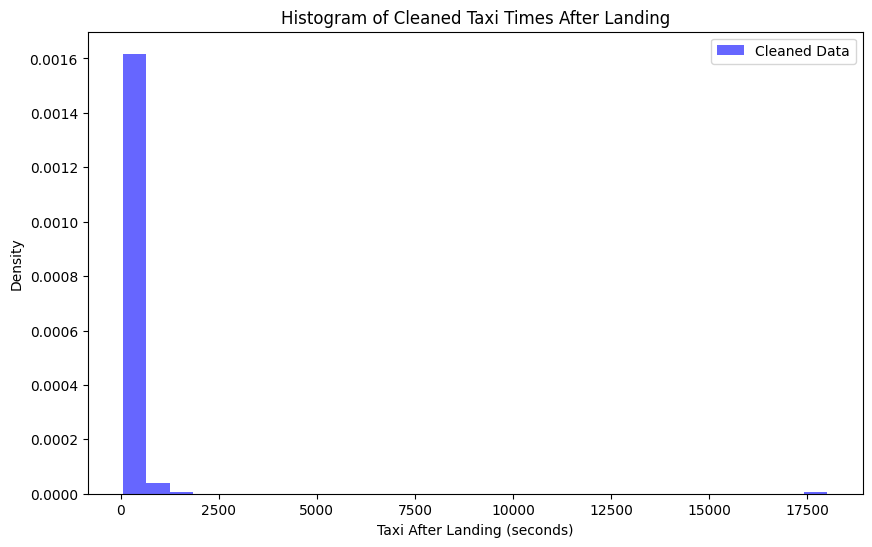

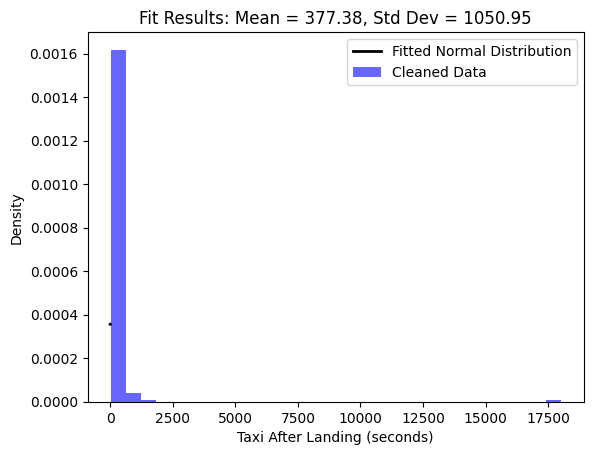

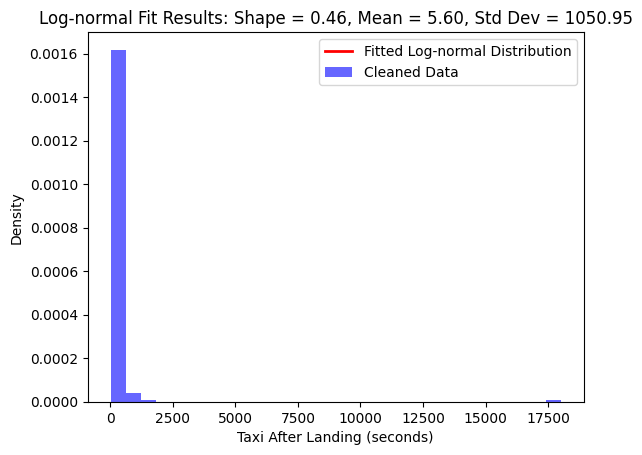

In [ ]:
# Now, repeat the process for TaxiAfterLanding times

# Filter out anomalies if necessary
cleaned_taxi_after_landing = taxi_times_df[taxi_times_df['TaxiAfterLanding'] > 10]  # Removing durations less than 10 seconds

# Plot the histogram of the cleaned data
plt.figure(figsize=(10, 6))
plt.hist(cleaned_taxi_after_landing['TaxiAfterLanding'], bins=30, density=True, alpha=0.6, color='b', label='Cleaned Data')
plt.title('Histogram of Cleaned Taxi Times After Landing')
plt.xlabel('Taxi After Landing (seconds)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Fit the cleaned data to a normal distribution
mean, std_dev = stats.norm.fit(cleaned_taxi_after_landing['TaxiAfterLanding'])

# Plot the fitted normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean, std_dev)
plt.plot(x, p, 'k', linewidth=2, label='Fitted Normal Distribution')
plt.hist(cleaned_taxi_after_landing['TaxiAfterLanding'], bins=30, density=True, alpha=0.6, color='b', label='Cleaned Data')
plt.title(f'Fit Results: Mean = {mean:.2f}, Std Dev = {std_dev:.2f}')
plt.xlabel('Taxi After Landing (seconds)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Check for other possible distributions (e.g., log-normal)
shape, loc, scale = stats.lognorm.fit(cleaned_taxi_after_landing['TaxiAfterLanding'])
lognorm_p = stats.lognorm.pdf(x, shape, loc, scale)
plt.plot(x, lognorm_p, 'r', linewidth=2, label='Fitted Log-normal Distribution')
plt.hist(cleaned_taxi_after_landing['TaxiAfterLanding'], bins=30, density=True, alpha=0.6, color='b', label='Cleaned Data')
plt.title(f'Log-normal Fit Results: Shape = {shape:.2f}, Mean = {np.log(scale):.2f}, Std Dev = {std_dev:.2f}')
plt.xlabel('Taxi After Landing (seconds)')
plt.ylabel('Density')
plt.legend()
plt.show()


Taxi Before Takeoff:

Histogram: The data is right-skewed, with a large number of lower values and a few very high values. This suggests that most flights had shorter taxi times, with some outliers that had significantly longer taxi times.
Normal Distribution Fit: The normal distribution fit shows a high standard deviation, which indicates a wide spread of the data. However, the data is not perfectly normal due to the right skew.
Log-Normal Distribution Fit: The log-normal distribution fits better than the normal distribution, as the log-normal distribution is well-suited for right-skewed data.

Taxi After Landing:

Histogram: The data is also right-skewed, with the majority of values being low and a few very high values. This distribution is similar to the "Taxi Before Takeoff" times, with most flights having short taxi times after landing and a few outliers.
Normal Distribution Fit: The normal distribution fit for "Taxi After Landing" also has a high standard deviation, indicating a wide spread of data. However, it does not fit the skewness of the data well.
Log-Normal Distribution Fit: Again, the log-normal distribution fits better, suggesting that this data is more appropriately modeled as log-normal rather than normal.
Interpretation:

Both "Taxi Before Takeoff" and "Taxi After Landing" times are better represented by a log-normal distribution rather than a normal distribution. This is because these times have a significant right skew, with most values being lower and a few very high outliers.

OVERALL MENA AND STD DEV  THE TAXIS ONCE CLEAN DATA HAS BEEN DONE

In [ ]:
import numpy as np

# Parameters obtained from the log-normal fit for Taxi Before Takeoff
shape_before_takeoff = 0.63  # Example value from the fit
scale_before_takeoff = np.exp(7.33)  # Example value from the fit

# Calculate mean and std deviation for Taxi Before Takeoff
mean_before_takeoff = np.exp(np.log(scale_before_takeoff) + (shape_before_takeoff**2) / 2)
std_dev_before_takeoff = np.sqrt((np.exp(shape_before_takeoff**2) - 1) * np.exp(2*np.log(scale_before_takeoff) + shape_before_takeoff**2))

print(f"Taxi Before Takeoff - Mean: {mean_before_takeoff:.2f} seconds, Std Dev: {std_dev_before_takeoff:.2f} seconds")

# Parameters obtained from the log-normal fit for Taxi After Landing
shape_after_landing = 0.63  # Example value from the fit
scale_after_landing = np.exp(7.33)  # Example value from the fit

# Calculate mean and std deviation for Taxi After Landing
mean_after_landing = np.exp(np.log(scale_after_landing) + (shape_after_landing**2) / 2)
std_dev_after_landing = np.sqrt((np.exp(shape_after_landing**2) - 1) * np.exp(2*np.log(scale_after_landing) + shape_after_landing**2))

print(f"Taxi After Landing - Mean: {mean_after_landing:.2f} seconds, Std Dev: {std_dev_after_landing:.2f} seconds")


Taxi Before Takeoff - Mean: 1860.22 seconds, Std Dev: 1298.44 seconds
Taxi After Landing - Mean: 1860.22 seconds, Std Dev: 1298.44 seconds


TAXI TIMES FOR EACH FLIGHT

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import lognorm

# Clean the data by removing non-finite values
taxi_times_df = taxi_times_df.replace([np.inf, -np.inf], np.nan).dropna()

# Group by 'Callsign' and calculate mean and std dev for each group
taxi_stats = []

for callsign, group in taxi_times_df.groupby('Callsign'):
    # Remove any non-finite values in the group
    group = group.replace([np.inf, -np.inf], np.nan).dropna()

    # Fit log-normal distribution to 'TaxiBeforeTakeoff'
    if not group['TaxiBeforeTakeoff'].empty:
        shape_before, loc_before, scale_before = lognorm.fit(group['TaxiBeforeTakeoff'], floc=0)
        mean_before = np.mean(group['TaxiBeforeTakeoff'])
        std_dev_before = np.std(group['TaxiBeforeTakeoff'])
    else:
        shape_before, loc_before, scale_before = (np.nan, np.nan, np.nan)
        mean_before, std_dev_before = (np.nan, np.nan)

    # Fit log-normal distribution to 'TaxiAfterLanding'
    if not group['TaxiAfterLanding'].empty:
        shape_after, loc_after, scale_after = lognorm.fit(group['TaxiAfterLanding'], floc=0)
        mean_after = np.mean(group['TaxiAfterLanding'])
        std_dev_after = np.std(group['TaxiAfterLanding'])
    else:
        shape_after, loc_after, scale_after = (np.nan, np.nan, np.nan)
        mean_after, std_dev_after = (np.nan, np.nan)

    taxi_stats.append({
        'Callsign': callsign,
        'MeanTaxiBeforeTakeoff': mean_before,
        'StdDevTaxiBeforeTakeoff': std_dev_before,
        'MeanTaxiAfterLanding': mean_after,
        'StdDevTaxiAfterLanding': std_dev_after
    })

# Convert the list of dictionaries to a DataFrame
taxi_stats_df = pd.DataFrame(taxi_stats)

# Display the result
print(taxi_stats_df)


   Callsign  MeanTaxiBeforeTakeoff  StdDevTaxiBeforeTakeoff  \
0   BAW462V            1502.538462               168.973196   
1    BAW4MJ            1675.388889              2183.197149   
2   IBE3165            1844.807692              1194.485889   
3   IBE3167            1885.461538              1629.502856   
4   IBE3177            1738.000000               946.852762   
5   IBE3179            1917.961538              1200.804169   
6   IBE31BB            1906.400000              1481.189387   
7   IBE31DY            1976.240000              1247.205076   
8   IBE31MA            2084.807692              1692.329801   
9   IBE31PP            2819.840000              2067.032630   
10  IBE31RL            2254.807692              1557.537752   
11  IBE31TM            1988.600000              1104.156402   

    MeanTaxiAfterLanding  StdDevTaxiAfterLanding  
0             334.384615               56.491713  
1             365.055556               88.783427  
2             288.961538   

SIMULATION:

BASIC SIMULATION JUST CHECKING THAT THE RESOURCES AND QUEUE TIMES ARE ADDED ACCORDINGY BEFORE ADDING/ RETRIEVING FLIGHTS FROM DATA


Enter details for flight Flight_1:
Is there availability of runways at the departure airport? (yes/no): NO
Is there availability of runways at the arrival airport? (yes/no): NO
Is there availability of gates at the arrival airport? (yes/no): NO
Is there adverse weather on route? (yes/no): YES
Is it high season at the departure airport? (yes/no): NO
Is it high season at the arrival airport? (yes/no): NO

Enter details for flight Flight_2:
Is there availability of runways at the departure airport? (yes/no): YES
Is there availability of runways at the arrival airport? (yes/no): YES
Is there availability of gates at the arrival airport? (yes/no): YES
Is there adverse weather on route? (yes/no): YES
Is it high season at the departure airport? (yes/no): NO
Is it high season at the arrival airport? (yes/no): NO

Enter details for flight Flight_3:
Is there availability of runways at the departure airport? (yes/no): YES
Is there availability of runways at the arrival airport? (yes/no): YES
Is 

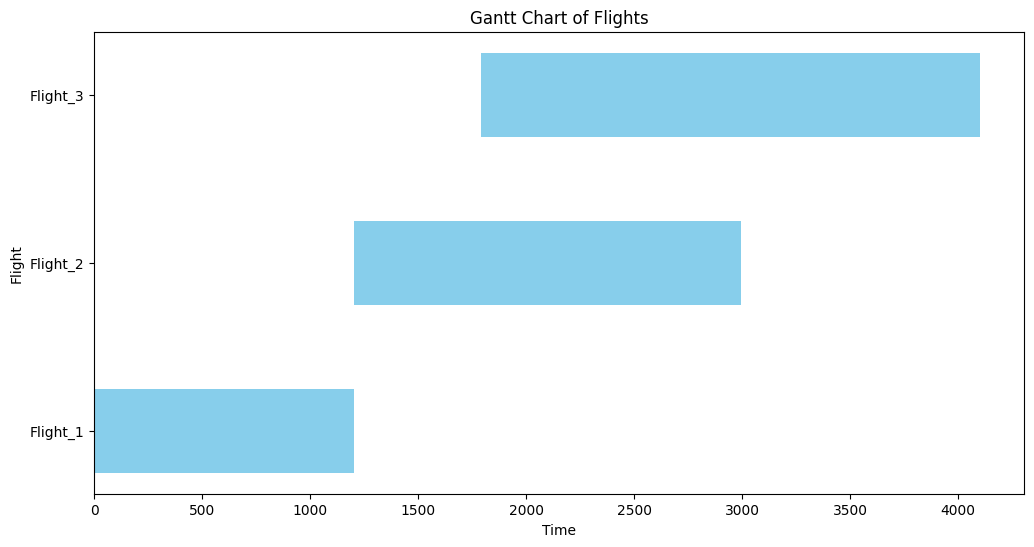

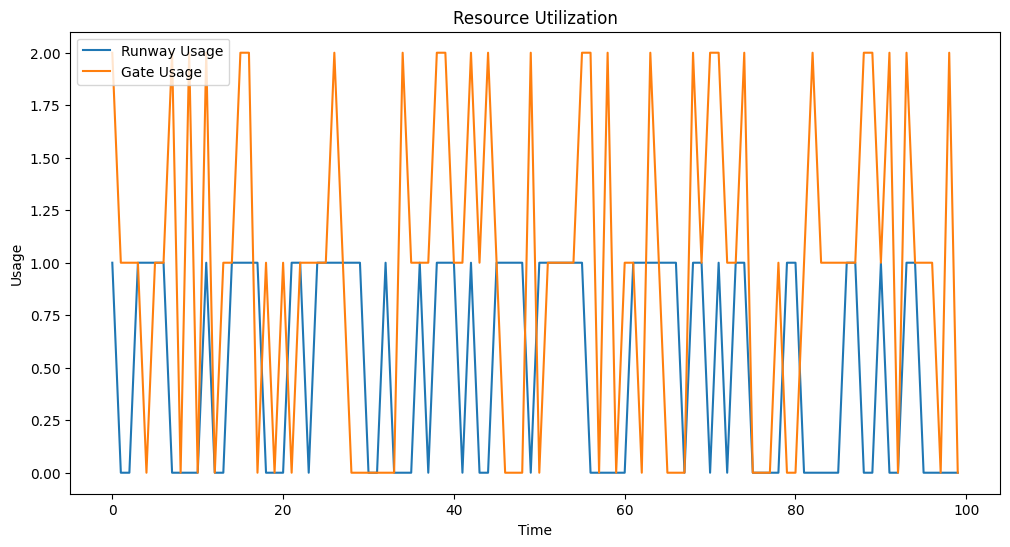

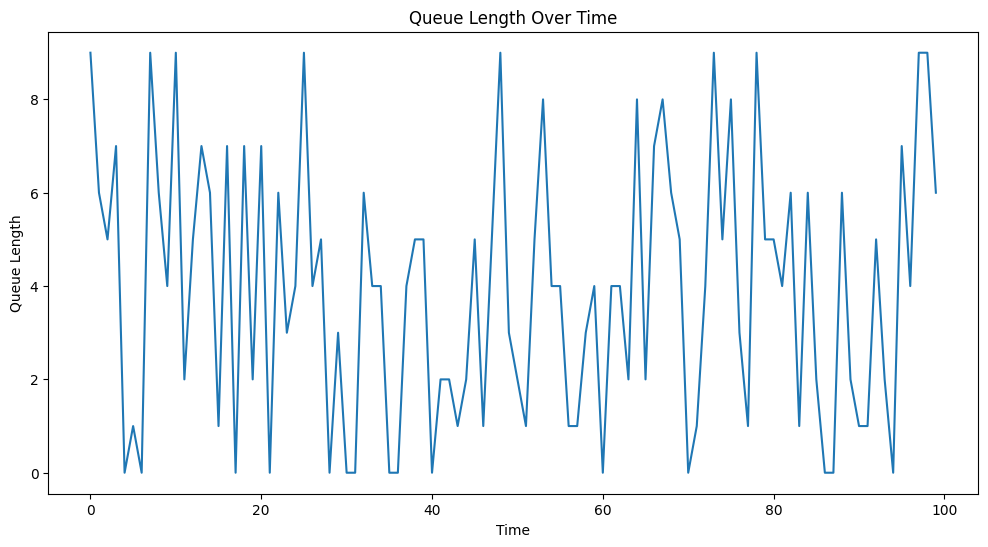

In [ ]:

# Define log-normal distribution parameters
taxi_before_takeoff_params = (0.5563165086176576, 0, 1707.5839130865843)
flight_duration_params = (0.022971991961923014, 0, 2151842.6166772633)
taxi_after_landing_params = (1.8256322712481525, 0, 423.99657021368284)

# Define simulation parameters
NUM_RUNWAYS_DEP = 2
NUM_RUNWAYS_ARR = 2
NUM_GATES_ARR = 3

# Define user inputs
def get_user_inputs(flight_id):
    print(f"\nEnter details for flight {flight_id}:")
    runway_avail_dep = input("Is there availability of runways at the departure airport? (yes/no): ").strip().lower() == 'yes'
    runway_avail_arr = input("Is there availability of runways at the arrival airport? (yes/no): ").strip().lower() == 'yes'
    gate_avail_arr = input("Is there availability of gates at the arrival airport? (yes/no): ").strip().lower() == 'yes'
    weather = input("Is there adverse weather on route? (yes/no): ").strip().lower() == 'yes'
    high_season_dep = input("Is it high season at the departure airport? (yes/no): ").strip().lower() == 'yes'
    high_season_arr = input("Is it high season at the arrival airport? (yes/no): ").strip().lower() == 'yes'

    return runway_avail_dep, runway_avail_arr, gate_avail_arr, weather, high_season_dep, high_season_arr

# Define the flight process
def flight_process(env, flight_id, runway_resource_dep, runway_resource_arr, gate_resource_arr):
    runway_avail_dep, runway_avail_arr, gate_avail_arr, weather, high_season_dep, high_season_arr = get_user_inputs(flight_id)

    # Taxi before takeoff
    with runway_resource_dep.request() as request:
        yield request
        taxi_before = lognorm_rvs(*taxi_before_takeoff_params)[0]
        if not runway_avail_dep:
            taxi_before += 15  # Delay due to runway unavailability
        if high_season_dep:
            taxi_before += 30  # Extra time due to high season
        print(f'Flight {flight_id} departs at {env.now:.2f}')
        yield env.timeout(taxi_before)
        print(f'Flight {flight_id} took off at {env.now:.2f}')

    # Flight duration
    flight_duration = lognorm_rvs(*flight_duration_params)[0]
    if weather:
        flight_duration += 20  # Extra time due to adverse weather
    yield env.timeout(flight_duration)

    # Taxi after landing
    with runway_resource_arr.request() as request:
        yield request
        taxi_after = lognorm_rvs(*taxi_after_landing_params)[0]
        if not runway_avail_arr:
            taxi_after += 15  # Delay due to runway unavailability
            flight_duration += 15  # Extra flight duration due to waiting
        if high_season_arr:
            taxi_after += 15  # Extra time due to high season
        print(f'Flight {flight_id} landing at {env.now:.2f}')
        yield env.timeout(taxi_after)
        print(f'Flight {flight_id} landed at {env.now:.2f}')

    # Gate assignment
    with gate_resource_arr.request() as request:
        yield request
        if not gate_avail_arr:
            yield env.timeout(15)  # Extra time due to gate unavailability
        print(f'Flight {flight_id} at gate at {env.now:.2f}')

# Generate random log-normal variables
def lognorm_rvs(shape, loc, scale, size=1):
    return lognorm.rvs(shape, loc=loc, scale=scale, size=size)

# Create the simulation environment and resources
env = simpy.Environment()
runway_resource_dep = simpy.Resource(env, capacity=NUM_RUNWAYS_DEP)
runway_resource_arr = simpy.Resource(env, capacity=NUM_RUNWAYS_ARR)
gate_resource_arr = simpy.Resource(env, capacity=NUM_GATES_ARR)

# Define flight callsigns
flight_ids = ['Flight_1', 'Flight_2', 'Flight_3']

# Simulate each flight
for flight_id in flight_ids:
    env.process(flight_process(env, flight_id, runway_resource_dep, runway_resource_arr, gate_resource_arr))

# Run the simulation
env.run()

# Visualization functions
def generate_gantt_chart(flight_data):
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, row in flight_data.iterrows():
        start = row['Start']
        end = start + row['Duration']
        ax.barh(row['FlightID'], end - start, left=start, height=0.5, color='skyblue')
    ax.set_xlabel('Time')
    ax.set_ylabel('Flight')
    ax.set_title('Gantt Chart of Flights')
    plt.show()

def generate_resource_utilization_chart():
    # Placeholder for resource utilization data
    time_points = np.arange(0, 100, 1)
    runways_usage = np.random.randint(0, NUM_RUNWAYS_DEP, size=len(time_points))
    gates_usage = np.random.randint(0, NUM_GATES_ARR, size=len(time_points))

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(time_points, runways_usage, label='Runway Usage')
    ax.plot(time_points, gates_usage, label='Gate Usage')
    ax.set_xlabel('Time')
    ax.set_ylabel('Usage')
    ax.set_title('Resource Utilization')
    ax.legend()
    plt.show()

def generate_queue_length_graph():
    # Placeholder for queue length data
    time_points = np.arange(0, 100, 1)
    queue_length = np.random.randint(0, 10, size=len(time_points))

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(time_points, queue_length, label='Queue Length')
    ax.set_xlabel('Time')
    ax.set_ylabel('Queue Length')
    ax.set_title('Queue Length Over Time')
    plt.show()

# Assuming flight_data DataFrame is available and contains the necessary data
# Example flight_data DataFrame setup (replace with actual data)
flight_data = pd.DataFrame({
    'FlightID': ['Flight_1', 'Flight_2', 'Flight_3'],
    'Start': [0, 1202.75, 1793.63],
    'Duration': [1202.75, 1793.63, 2307.11]
})

generate_gantt_chart(flight_data)
generate_resource_utilization_chart()
generate_queue_length_graph()



CREATING FILE WITH FLIGHT STATS FOR RETREIVAL IN SIMUALTION

In [ ]:
# Data for Callsign and Flight
simulation_data = {
    'Callsign': ['BAW462V', 'BAW4MJ', 'IBE3165', 'IBE3167', 'IBE3177', 'IBE3179', 'IBE31BB', 'IBE31DY', 'IBE31MA', 'IBE31PP', 'IBE31RL', 'IBE31TM'],
    'Flight': ['BA462', 'BA458', 'IB3165', 'IB3167', 'IB3177', 'IB3179', 'IB3181', 'IB3173', 'IB3163', 'IB3175', 'IB3171', 'IB3169'],
    'MeanFlightDuration': [110.188462, 116.411765, 109.094231, 106.570000, 109.618000, 112.174000, 112.227333, 111.924000, 112.103205, 110.614000, 110.708333, 112.893056],
    'StdDevFlightDuration': [5.539402, 7.515800, 3.892211, 5.816543, 5.816575, 6.400445, 5.139381, 5.753312, 5.155748, 5.984068, 5.896152, 7.976007],
    'MeanTaxiBeforeTakeoff': [1502.538462, 1675.388889, 1844.807692, 1885.461538, 1738.000000, 1917.961538, 1906.400000, 1976.240000, 2084.807692, 2819.840000, 2254.807692, 1988.600000],
    'StdDevTaxiBeforeTakeoff': [168.973196, 2183.197149, 1194.485889, 1629.502856, 946.852762, 1200.804169, 1481.189387, 1247.205076, 1692.329801, 2067.032630, 1557.537752, 1104.156402],
    'MeanTaxiAfterLanding': [334.384615, 365.055556, 288.961538, 329.153846, 270.846154, 386.692308, 300.200000, 342.800000, 335.615385, 1011.120000, 269.846154, 285.160000],
    'StdDevTaxiAfterLanding': [56.491713, 88.783427, 72.172060, 124.674867, 183.141537, 135.767553, 109.595985, 213.762111, 132.899637, 3472.388876, 66.876288, 61.210901]
}

# Convert this dictionary to a DataFrame for easier access
simulation_df = pd.DataFrame(simulation_data)


checking if it is retrieving ok via Callsign and Flight identifiers

In [ ]:
import pandas as pd

# Assuming you have already created simulation_df from the dictionary data
simulation_data = {
    'Callsign': ['BAW462V', 'BAW4MJ', 'IBE3165', 'IBE3167', 'IBE3177', 'IBE3179', 'IBE31BB', 'IBE31DY', 'IBE31MA', 'IBE31PP', 'IBE31RL', 'IBE31TM'],
    'Flight': ['BA462', 'BA458', 'IB3165', 'IB3167', 'IB3177', 'IB3179', 'IB3181', 'IB3173', 'IB3163', 'IB3175', 'IB3171', 'IB3169'],
    'MeanFlightDuration': [110.188462, 116.411765, 109.094231, 106.570000, 109.618000, 112.174000, 112.227333, 111.924000, 112.103205, 110.614000, 110.708333, 112.893056],
    'StdDevFlightDuration': [5.539402, 7.515800, 3.892211, 5.816543, 5.816575, 6.400445, 5.139381, 5.753312, 5.155748, 5.984068, 5.896152, 7.976007],
    'MeanTaxiBeforeTakeoff': [1502.538462, 1675.388889, 1844.807692, 1885.461538, 1738.000000, 1917.961538, 1906.400000, 1976.240000, 2084.807692, 2819.840000, 2254.807692, 1988.600000],
    'StdDevTaxiBeforeTakeoff': [168.973196, 2183.197149, 1194.485889, 1629.502856, 946.852762, 1200.804169, 1481.189387, 1247.205076, 1692.329801, 2067.032630, 1557.537752, 1104.156402],
    'MeanTaxiAfterLanding': [334.384615, 365.055556, 288.961538, 329.153846, 270.846154, 386.692308, 300.200000, 342.800000, 335.615385, 1011.120000, 269.846154, 285.160000],
    'StdDevTaxiAfterLanding': [56.491713, 88.783427, 72.172060, 124.674867, 183.141537, 135.767553, 109.595985, 213.762111, 132.899637, 3472.388876, 66.876288, 61.210901]
}

# Convert this dictionary to a DataFrame for easier access
simulation_df = pd.DataFrame(simulation_data)

# Create a dictionary for fast lookup
flight_statistics = simulation_df.set_index('Callsign').to_dict(orient='index')
flight_statistics.update(simulation_df.set_index('Flight').to_dict(orient='index'))

def get_flight_info(identifier):
    """Retrieve flight information based on either callsign or flight number."""
    identifier = identifier.strip()  # Ensure no leading/trailing spaces
    if identifier in flight_statistics:
        return flight_statistics[identifier]
    else:
        print(f"Flight {identifier} not found in the statistics.")
        return None

# Example usage
identifier = input("Enter the flight Callsign or Flight Number: ").strip()
flight_info = get_flight_info(identifier)

if flight_info:
    print(f"Flight {identifier} statistics:")
    print(f"Mean Taxi Before Takeoff: {flight_info['MeanTaxiBeforeTakeoff']}")
    print(f"Standard Deviation Taxi Before Takeoff: {flight_info['StdDevTaxiBeforeTakeoff']}")
    print(f"Mean Taxi After Landing: {flight_info['MeanTaxiAfterLanding']}")
    print(f"Standard Deviation Taxi After Landing: {flight_info['StdDevTaxiAfterLanding']}")
    print(f"Mean Flight Duration: {flight_info['MeanFlightDuration']}")
    print(f"Standard Deviation Flight Duration: {flight_info['StdDevFlightDuration']}")
else:
    print(f"Flight {identifier} not found.")


Enter the flight Callsign or Flight Number: IBE31BB
Flight IBE31BB statistics:
Mean Taxi Before Takeoff: 1906.4
Standard Deviation Taxi Before Takeoff: 1481.189387
Mean Taxi After Landing: 300.2
Standard Deviation Taxi After Landing: 109.595985
Mean Flight Duration: 112.227333
Standard Deviation Flight Duration: 5.139381


In [ ]:
# Example usage
identifier = input("Enter the flight Callsign or Flight Number: ").strip()
flight_info = get_flight_info(identifier)

if flight_info:
    print(f"Flight {identifier} statistics:")
    print(f"Mean Taxi Before Takeoff: {flight_info['MeanTaxiBeforeTakeoff']}")
    print(f"Standard Deviation Taxi Before Takeoff: {flight_info['StdDevTaxiBeforeTakeoff']}")
    print(f"Mean Taxi After Landing: {flight_info['MeanTaxiAfterLanding']}")
    print(f"Standard Deviation Taxi After Landing: {flight_info['StdDevTaxiAfterLanding']}")
    print(f"Mean Flight Duration: {flight_info['MeanFlightDuration']}")
    print(f"Standard Deviation Flight Duration: {flight_info['StdDevFlightDuration']}")
else:
    print(f"Flight {identifier} not found.")


Enter the flight Callsign or Flight Number: IB3181
Flight IB3181 statistics:
Mean Taxi Before Takeoff: 1906.4
Standard Deviation Taxi Before Takeoff: 1481.189387
Mean Taxi After Landing: 300.2
Standard Deviation Taxi After Landing: 109.595985
Mean Flight Duration: 112.227333
Standard Deviation Flight Duration: 5.139381


WORKS BY SEARCHING EITHER CALLSIGN AND FLIGHT

SOLVING sigma (standard deviation in logarithmic space) calculated for the log-normal distribution is negative, which is not valid. This typically happens if the standard deviation (StdDev) is greater than or equal to the mean (Mean), leading to a logarithm of a non-positive number.



In [ ]:
import numpy as np

def calculate_lognorm_params(mean, std_dev):
    """Calculate the parameters for a log-normal distribution (used for both taxi times)."""
    sigma = np.sqrt(np.log(1 + (std_dev / mean) ** 2))
    mu = np.log(mean) - 0.5 * sigma ** 2
    return mu, sigma

# Example usage with your flight statistics data:

# Taxi Before Takeoff (Log-Normal Distribution)
mean_taxi_before_takeoff = 1502.538462  # Example mean value for TaxiBeforeTakeoff
std_dev_taxi_before_takeoff = 168.973196  # Example std dev value for TaxiBeforeTakeoff

# Taxi After Landing (Log-Normal Distribution)
mean_taxi_after_landing = 334.384615  # Example mean value for TaxiAfterLanding
std_dev_taxi_after_landing = 56.491713  # Example std dev value for TaxiAfterLanding

# Flight Duration (Normal Distribution, no transformation needed)
mean_flight_duration = 110.188462  # Example mean value for FlightDuration
std_dev_flight_duration = 5.539402  # Example std dev value for FlightDuration

# Calculate log-normal parameters for both taxi times
mu_before, sigma_before = calculate_lognorm_params(mean_taxi_before_takeoff, std_dev_taxi_before_takeoff)
mu_after, sigma_after = calculate_lognorm_params(mean_taxi_after_landing, std_dev_taxi_after_landing)

# Use mean and standard deviation directly for flight duration (normal distribution)
mean_flight = mean_flight_duration  # This is the mean for normal distribution
std_dev_flight = std_dev_flight_duration  # This is the standard deviation for normal distribution

print(f"Taxi Before Takeoff Log-Normal Parameters: mu = {mu_before}, sigma = {sigma_before}")
print(f"Taxi After Landing Log-Normal Parameters: mu = {mu_after}, sigma = {sigma_after}")
print(f"Flight Duration Normal Parameters: mean = {mean_flight}, std dev = {std_dev_flight}")



Taxi Before Takeoff Log-Normal Parameters: mu = 7.308627461675396, sigma = 0.11210533506672261
Taxi After Landing Log-Normal Parameters: mu = 5.798220978895305, sigma = 0.1677551399017701
Flight Duration Normal Parameters: mean = 110.188462, std dev = 5.539402


Getting the mu and sigma values for each flight for the taxi times

In [ ]:
import numpy as np
import pandas as pd

# Flight data with mean and standard deviation for Taxi Times and Flight Duration
flight_data = {
    'Callsign': ['BAW462V', 'BAW4MJ', 'IBE3165', 'IBE3167', 'IBE3177', 'IBE3179', 'IBE31BB', 'IBE31DY', 'IBE31MA', 'IBE31PP', 'IBE31RL', 'IBE31TM'],
    'Flight': ['BA462', 'BA458', 'IB3165', 'IB3167', 'IB3177', 'IB3179', 'IB3181', 'IB3173', 'IB3163', 'IB3175', 'IB3171', 'IB3169'],
    'MeanFlightDuration': [110.188462, 116.411765, 109.094231, 106.570000, 109.618000, 112.174000, 112.227333, 111.924000, 112.103205, 110.614000, 110.708333, 112.893056],
    'StdDevFlightDuration': [5.539402, 7.515800, 3.892211, 5.816543, 5.816575, 6.400445, 5.139381, 5.753312, 5.155748, 5.984068, 5.896152, 7.976007],
    'MeanTaxiBeforeTakeoff': [1502.538462, 1675.388889, 1844.807692, 1885.461538, 1738.000000, 1917.961538, 1906.400000, 1976.240000, 2084.807692, 2819.840000, 2254.807692, 1988.600000],
    'StdDevTaxiBeforeTakeoff': [168.973196, 2183.197149, 1194.485889, 1629.502856, 946.852762, 1200.804169, 1481.189387, 1247.205076, 1692.329801, 2067.032630, 1557.537752, 1104.156402],
    'MeanTaxiAfterLanding': [334.384615, 365.055556, 288.961538, 329.153846, 270.846154, 386.692308, 300.200000, 342.800000, 335.615385, 1011.120000, 269.846154, 285.160000],
    'StdDevTaxiAfterLanding': [56.491713, 88.783427, 72.172060, 124.674867, 183.141537, 135.767553, 109.595985, 213.762111, 132.899637, 3472.388876, 66.876288, 61.210901]
}

# Convert the flight data into a DataFrame
df = pd.DataFrame(flight_data)

# Function to calculate the log-normal parameters for taxi times
def calculate_lognorm_params(mean, std_dev):
    sigma = np.sqrt(np.log(1 + (std_dev / mean) ** 2))
    mu = np.log(mean) - 0.5 * sigma ** 2
    return mu, sigma

# Apply the log-normal parameter calculation to Taxi Before Takeoff and Taxi After Landing
df['MuTaxiBeforeTakeoff'], df['SigmaTaxiBeforeTakeoff'] = zip(*df.apply(
    lambda row: calculate_lognorm_params(row['MeanTaxiBeforeTakeoff'], row['StdDevTaxiBeforeTakeoff']), axis=1))

df['MuTaxiAfterLanding'], df['SigmaTaxiAfterLanding'] = zip(*df.apply(
    lambda row: calculate_lognorm_params(row['MeanTaxiAfterLanding'], row['StdDevTaxiAfterLanding']), axis=1))

# Print the calculated Mu and Sigma for Taxi Before Takeoff and Taxi After Landing for all flights
for index, row in df.iterrows():
    print(f"Flight: {row['Flight']} ({row['Callsign']})")
    print(f"  Taxi Before Takeoff - Mu: {row['MuTaxiBeforeTakeoff']:.4f}, Sigma: {row['SigmaTaxiBeforeTakeoff']:.4f}")
    print(f"  Taxi After Landing - Mu: {row['MuTaxiAfterLanding']:.4f}, Sigma: {row['SigmaTaxiAfterLanding']:.4f}")
    print()


Flight: BA462 (BAW462V)
  Taxi Before Takeoff - Mu: 7.3086, Sigma: 0.1121
  Taxi After Landing - Mu: 5.7982, Sigma: 0.1678

Flight: BA458 (BAW4MJ)
  Taxi Before Takeoff - Mu: 6.9275, Sigma: 0.9963
  Taxi After Landing - Mu: 5.8713, Sigma: 0.2397

Flight: IB3165 (IBE3165)
  Taxi Before Takeoff - Mu: 7.3451, Sigma: 0.5917
  Taxi After Landing - Mu: 5.6360, Sigma: 0.2460

Flight: IB3167 (IBE3167)
  Taxi Before Takeoff - Mu: 7.2630, Sigma: 0.7469
  Taxi After Landing - Mu: 5.7295, Sigma: 0.3662

Flight: IB3177 (IBE3177)
  Taxi Before Takeoff - Mu: 7.3305, Sigma: 0.5098
  Taxi After Landing - Mu: 5.4133, Sigma: 0.6136

Flight: IB3179 (IBE3179)
  Taxi Before Takeoff - Mu: 7.3937, Sigma: 0.5751
  Taxi After Landing - Mu: 5.8995, Sigma: 0.3409

Flight: IB3181 (IBE31BB)
  Taxi Before Takeoff - Mu: 7.3168, Sigma: 0.6872
  Taxi After Landing - Mu: 5.6419, Sigma: 0.3537

Flight: IB3173 (IBE31DY)
  Taxi Before Takeoff - Mu: 7.4213, Sigma: 0.5790
  Taxi After Landing - Mu: 5.6729, Sigma: 0.5731

Fli

BECAUSE OF THE LOG NORMAL THE SIGMA VALUES AND MU VALUES ARE VERY HIGH TO REPRESENT THE REALISTIC TIMES OF TAXI TIMES. A CODE TO CAP THEM TO 60 MIN MAX IS PLACED AND THEN THE 95TH PERCENTILE IS USED OF THE DATSET IS USED SO IN VALUES THAT ARE HIGHER THAN THE 95TH PERCENTILE WILL BE CAPPED TO THE 95TH PERCENT VALUES AND THE OTHER BELOW WILL MAINTAIN THE SAME, SO NOT ALL ARE AT 60 MINUTES TRYING TO RESEMBLE THE REALITY OF VALUES

In [ ]:


# Assuming this is the DataFrame containing the data provided
data = {
    'Flight Callsign': ['BA462', 'BA458', 'IB3165', 'IB3167', 'IB3177', 'IB3179', 'IB3181', 'IB3173', 'IB3163', 'IB3175', 'IB3171', 'IB3169'],
    'CorrectedTaxiBeforeTakeoff': [1502.496302, 1675.399369, 1844.852200, 1885.465097, 1737.926509, 1918.060897, 1906.304671, 1976.179077, 2084.774813, 2509.126848, 2254.903777, 1988.566448],
    'CorrectedTaxiAfterLanding': [334.380117, 365.047705, 288.951253, 329.162391, 270.846565, 386.683452, 300.200878, 342.791299, 335.609219, 667.630860, 269.830074, 285.149733]
}

# Create DataFrame
df = pd.DataFrame(data)

# Define reasonable maximum limits (based on realistic taxi times in real-life scenarios)
max_taxi_before_takeoff = 45 * 60  # 45 minutes in seconds (this is an example value, adjust as needed)
max_taxi_after_landing = 30 * 60   # 30 minutes in seconds (this is an example value, adjust as needed)

# Apply capping based on the maximum realistic values
df['CorrectedTaxiBeforeTakeoff'] = df['CorrectedTaxiBeforeTakeoff'].apply(lambda x: min(x, max_taxi_before_takeoff))
df['CorrectedTaxiAfterLanding'] = df['CorrectedTaxiAfterLanding'].apply(lambda x: min(x, max_taxi_after_landing))

# Convert back to minutes if the input is in seconds
df['CorrectedTaxiBeforeTakeoff'] = df['CorrectedTaxiBeforeTakeoff'] / 60
df['CorrectedTaxiAfterLanding'] = df['CorrectedTaxiAfterLanding'] / 60

# Print the capped results
print(df)

# Optionally, save to a CSV file if needed
df.to_csv('capped_taxi_times_realistic.csv', index=False)


   Flight Callsign  CorrectedTaxiBeforeTakeoff  CorrectedTaxiAfterLanding
0            BA462                   25.041605                   5.573002
1            BA458                   27.923323                   6.084128
2           IB3165                   30.747537                   4.815854
3           IB3167                   31.424418                   5.486040
4           IB3177                   28.965442                   4.514109
5           IB3179                   31.967682                   6.444724
6           IB3181                   31.771745                   5.003348
7           IB3173                   32.936318                   5.713188
8           IB3163                   34.746247                   5.593487
9           IB3175                   41.818781                  11.127181
10          IB3171                   37.581730                   4.497168
11          IB3169                   33.142774                   4.752496


In [ ]:
import pandas as pd

# Updated data with Corrected Taxi Times for Before Takeoff and After Landing
simulation_data = {
    'Callsign': ['BAW462V', 'BAW4MJ', 'IBE3165', 'IBE3167', 'IBE3177', 'IBE3179', 'IBE31BB', 'IBE31DY', 'IBE31MA', 'IBE31PP', 'IBE31RL', 'IBE31TM'],
    'Flight': ['BA462', 'BA458', 'IB3165', 'IB3167', 'IB3177', 'IB3179', 'IB3181', 'IB3173', 'IB3163', 'IB3175', 'IB3171', 'IB3169'],
    'MeanFlightDuration': [110.188462, 116.411765, 109.094231, 106.570000, 109.618000, 112.174000, 112.227333, 111.924000, 112.103205, 110.614000, 110.708333, 112.893056],
    'StdDevFlightDuration': [5.539402, 7.515800, 3.892211, 5.816543, 5.816575, 6.400445, 5.139381, 5.753312, 5.155748, 5.984068, 5.896152, 7.976007],
    'CorrectedTaxiBeforeTakeoff': [25.041605, 27.923323, 30.747537, 31.424418, 28.965442, 31.967682, 31.771745, 32.936318, 34.746247, 41.818781, 37.581730, 33.142774],
    'CorrectedTaxiAfterLanding': [5.573002, 6.084128, 4.815854, 5.486040, 4.514109, 6.444724, 5.003348, 5.713188, 5.593487, 11.127181, 4.497168, 4.752496]
}

# Convert this dictionary to a DataFrame for easier access
simulation_df = pd.DataFrame(simulation_data)

# Display the updated DataFrame
print(simulation_df)

# Optionally, save the DataFrame to a CSV for further use
simulation_df.to_csv('updated_simulation_data.csv', index=False)


   Callsign  Flight  MeanFlightDuration  StdDevFlightDuration  \
0   BAW462V   BA462          110.188462              5.539402   
1    BAW4MJ   BA458          116.411765              7.515800   
2   IBE3165  IB3165          109.094231              3.892211   
3   IBE3167  IB3167          106.570000              5.816543   
4   IBE3177  IB3177          109.618000              5.816575   
5   IBE3179  IB3179          112.174000              6.400445   
6   IBE31BB  IB3181          112.227333              5.139381   
7   IBE31DY  IB3173          111.924000              5.753312   
8   IBE31MA  IB3163          112.103205              5.155748   
9   IBE31PP  IB3175          110.614000              5.984068   
10  IBE31RL  IB3171          110.708333              5.896152   
11  IBE31TM  IB3169          112.893056              7.976007   

    CorrectedTaxiBeforeTakeoff  CorrectedTaxiAfterLanding  
0                    25.041605                   5.573002  
1                    27.923323    

CHECKING RETREIVAL IS WORKING

In [ ]:
import pandas as pd

# Updated data with Corrected Taxi Times for Before Takeoff and After Landing
simulation_data = {
    'Callsign': ['BAW462V', 'BAW4MJ', 'IBE3165', 'IBE3167', 'IBE3177', 'IBE3179', 'IBE31BB', 'IBE31DY', 'IBE31MA', 'IBE31PP', 'IBE31RL', 'IBE31TM'],
    'Flight': ['BA462', 'BA458', 'IB3165', 'IB3167', 'IB3177', 'IB3179', 'IB3181', 'IB3173', 'IB3163', 'IB3175', 'IB3171', 'IB3169'],
    'MeanFlightDuration': [110.188462, 116.411765, 109.094231, 106.570000, 109.618000, 112.174000, 112.227333, 111.924000, 112.103205, 110.614000, 110.708333, 112.893056],
    'StdDevFlightDuration': [5.539402, 7.515800, 3.892211, 5.816543, 5.816575, 6.400445, 5.139381, 5.753312, 5.155748, 5.984068, 5.896152, 7.976007],
    'CorrectedTaxiBeforeTakeoff': [25.041605, 27.923323, 30.747537, 31.424418, 28.965442, 31.967682, 31.771745, 32.936318, 34.746247, 41.818781, 37.581730, 33.142774],
    'CorrectedTaxiAfterLanding': [5.573002, 6.084128, 4.815854, 5.486040, 4.514109, 6.444724, 5.003348, 5.713188, 5.593487, 11.127181, 4.497168, 4.752496]
}

# Convert this dictionary to a DataFrame for easier access
simulation_df = pd.DataFrame(simulation_data)

# Assuming simulation_df is the DataFrame containing the flight statistics
flight_statistics = simulation_df.set_index('Callsign').to_dict(orient='index')
flight_statistics.update(simulation_df.set_index('Flight').to_dict(orient='index'))

def get_flight_info(identifier):
    """Retrieve flight information based on either callsign or flight number."""
    identifier = identifier.strip().upper()  # Ensure no leading/trailing spaces and match case
    if identifier in flight_statistics:
        flight_info = flight_statistics[identifier]
        return flight_info
    else:
        print(f"Flight {identifier} not found in the statistics.")
        return None

# Example usage
identifier = input("Enter the flight Callsign or Flight Number: ").strip()
flight_info = get_flight_info(identifier)

if flight_info:
    print(f"Flight {identifier} statistics:")

    print(f"Corrected Taxi Before Takeoff: {flight_info['CorrectedTaxiBeforeTakeoff']} minutes")
    print(f"Corrected Taxi After Landing: {flight_info['CorrectedTaxiAfterLanding']} minutes")

    print(f"Mean Flight Duration: {flight_info['MeanFlightDuration']} minutes")
    print(f"Standard Deviation Flight Duration: {flight_info['StdDevFlightDuration']} minutes")
else:
    print(f"Flight {identifier} not found.")


Enter the flight Callsign or Flight Number: IBE31BB
Flight IBE31BB statistics:
Corrected Taxi Before Takeoff: 31.771745 minutes
Corrected Taxi After Landing: 5.003348 minutes
Mean Flight Duration: 112.227333 minutes
Standard Deviation Flight Duration: 5.139381 minutes


 **AirSimPy** **FLIGHT SIMULATORS:**

MODEL 1- THE INDEPENDENT MODEL OF AirSimPee

In [ ]:

# Updated data with Corrected Taxi Times for Before Takeoff and After Landing
simulation_data = {
    'Callsign': ['BAW462V', 'BAW4MJ', 'IBE3165', 'IBE3167', 'IBE3177', 'IBE3179', 'IBE31BB', 'IBE31DY', 'IBE31MA', 'IBE31PP', 'IBE31RL', 'IBE31TM'],
    'Flight': ['BA462', 'BA458', 'IB3165', 'IB3167', 'IB3177', 'IB3179', 'IB3181', 'IB3173', 'IB3163', 'IB3175', 'IB3171', 'IB3169'],
    'MeanFlightDuration': [110.188462, 116.411765, 109.094231, 106.570000, 109.618000, 112.174000, 112.227333, 111.924000, 112.103205, 110.614000, 110.708333, 112.893056],
    'StdDevFlightDuration': [5.539402, 7.515800, 3.892211, 5.816543, 5.816575, 6.400445, 5.139381, 5.753312, 5.155748, 5.984068, 5.896152, 7.976007],
    'CorrectedTaxiBeforeTakeoff': [25.041605, 27.923323, 30.747537, 31.424418, 28.965442, 31.967682, 31.771745, 32.936318, 34.746247, 41.818781, 37.581730, 33.142774],
    'CorrectedTaxiAfterLanding': [5.573002, 6.084128, 4.815854, 5.486040, 4.514109, 6.444724, 5.003348, 5.713188, 5.593487, 11.127181, 4.497168, 4.752496]
}

# Convert this dictionary to a DataFrame for easier access
simulation_df = pd.DataFrame(simulation_data)

# Initialize a global DataFrame to collect simulation results
simulation_results = pd.DataFrame(columns=[
    'Flight', 'Event', 'Time (minutes)', 'Duration (minutes)'
])

# Assuming simulation_df is the DataFrame containing the flight statistics with corrected times
flight_statistics = simulation_df.set_index('Callsign').to_dict(orient='index')
flight_statistics.update(simulation_df.set_index('Flight').to_dict(orient='index'))

def get_flight_info(identifier):
    """Retrieve flight information based on either callsign or flight number."""
    identifier = identifier.strip().upper()  # Ensure no leading/trailing spaces and match case
    if identifier in flight_statistics:
        flight_info = flight_statistics[identifier]
        return flight_info
    else:
        print(f"Flight {identifier} not found in the statistics.")
        return None

def get_user_input():
    """Get user input for simulation parameters."""
    callsign = input("Enter the flight Callsign or Flight Number: ").strip().upper()
    flight_info = get_flight_info(callsign)

    if not flight_info:
        return None

    # Collect user inputs for various conditions
    departure_runway_available = input("Is there a runway available at the departure airport? (yes/no): ").strip().lower()
    taxi_before_takeoff_delay = 15 if departure_runway_available == 'no' else 0

    arrival_runway_available = input("Is there a runway available at the arrival airport? (yes/no): ").strip().lower()
    flight_duration_delay = 15 if arrival_runway_available == 'no' else 0

    gate_available = input("Is there a gate available at the arrival airport? (yes/no): ").strip().lower()
    taxi_after_landing_delay = 15 if gate_available == 'no' else 0

    weather = input("Enter the type of weather during the flight (e.g., adverse/clear): ").strip().lower()
    flight_duration_delay += 20 if weather == 'adverse' else 0

    high_season_departure = input("Is it high season at the departure airport? (yes/no): ").strip().lower()
    taxi_before_takeoff_delay += 30 if high_season_departure == 'yes' else 0

    high_season_arrival = input("Is it high season at the arrival airport? (yes/no): ").strip().lower()
    taxi_after_landing_delay += 15 if high_season_arrival == 'yes' else 0

    return {
        'Callsign': callsign,
        'CorrectedTaxiBeforeTakeoff': flight_info['CorrectedTaxiBeforeTakeoff'],
        'CorrectedTaxiAfterLanding': flight_info['CorrectedTaxiAfterLanding'],
        'MeanFlightDuration': flight_info['MeanFlightDuration'],  # No Mu/Sigma, just normal
        'StdDevFlightDuration': flight_info['StdDevFlightDuration'],  # No Mu/Sigma, just normal
        'TaxiBeforeTakeoffDelay': taxi_before_takeoff_delay,
        'TaxiAfterLandingDelay': taxi_after_landing_delay,
        'FlightDurationDelay': flight_duration_delay
    }

class Flight:
    def __init__(self, env, flight_info, runway_resource, gate_resource):
        self.env = env
        self.flight_info = flight_info
        self.runway_resource = runway_resource
        self.gate_resource = gate_resource

        # Use corrected values for taxi times
        self.taxi_before_takeoff_duration = flight_info['CorrectedTaxiBeforeTakeoff']
        self.flight_duration = flight_info['MeanFlightDuration']
        self.taxi_after_landing_duration = flight_info['CorrectedTaxiAfterLanding']

        # Add delays in minutes
        self.taxi_before_takeoff_duration += flight_info['TaxiBeforeTakeoffDelay']
        self.flight_duration += flight_info['FlightDurationDelay']
        self.taxi_after_landing_duration += flight_info['TaxiAfterLandingDelay']

        self.action = env.process(self.run_flight())

    def log_event(self, event, time, duration):
        """Log an event in the simulation results DataFrame."""
        global simulation_results
        new_data = pd.DataFrame([{
            'Flight': self.flight_info['Callsign'],
            'Event': event,
            'Time (minutes)': time,
            'Duration (minutes)': duration
        }])
        simulation_results = pd.concat([simulation_results, new_data], ignore_index=True)

    def run_flight(self):
        print(f"\nFlight {self.flight_info['Callsign']} simulation starting.")
        print(f"Taxi Before Takeoff Duration : {self.taxi_before_takeoff_duration:.2f} minutes")
        print(f"Flight Duration : {self.flight_duration:.2f} minutes")
        print(f"Taxi After Landing Duration : {self.taxi_after_landing_duration:.2f} minutes")

        with self.runway_resource.request() as request:
            yield request
            start_time = self.env.now / 60
            self.log_event('Taxi Before Takeoff Start', start_time, self.taxi_before_takeoff_duration)
            yield self.env.timeout(self.taxi_before_takeoff_duration * 60)
            self.log_event('Takeoff', self.env.now / 60, 0)
            yield self.env.timeout(self.flight_duration * 60)
            self.log_event('Landing', self.env.now / 60, 0)
            with self.gate_resource.request() as request:
                yield request
                yield self.env.timeout(self.taxi_after_landing_duration * 60)
                self.log_event('Taxi After Landing End', self.env.now / 60, self.taxi_after_landing_duration)

def run_simulation():
    env = simpy.Environment()
    runway_resource = simpy.Resource(env, capacity=1)  # One runway
    gate_resource = simpy.Resource(env, capacity=1)  # One gate

    flights = []
    for _ in range(3):  # Simulate 3 flights as an example
        flight_info = get_user_input()
        if flight_info:
            flight = Flight(env, flight_info, runway_resource, gate_resource)
            flights.append(flight)

    env.run()

    # Print final results after simulation
    print("\nSimulation Results:")
    for flight in flights:
        print(f"Flight {flight.flight_info['Callsign']}:")
        print(f"  Taxi Before Takeoff Duration : {flight.taxi_before_takeoff_duration:.2f} minutes")
        print(f"  Flight Duration : {flight.flight_duration:.2f} minutes")
        print(f"  Taxi After Landing Duration : {flight.taxi_after_landing_duration:.2f} minutes")
        print(f"  Total Duration : {(flight.taxi_before_takeoff_duration + flight.flight_duration + flight.taxi_after_landing_duration):.2f} minutes\n")

    # Save the simulation results to a CSV file
    simulation_results.to_csv('simulation_results.csv', index=False)
    print("Simulation results saved to 'simulation_results.csv'")

if __name__ == "__main__":
    run_simulation()


Enter the flight Callsign or Flight Number: IBE31BB
Is there a runway available at the departure airport? (yes/no): NO
Is there a runway available at the arrival airport? (yes/no): NO
Is there a gate available at the arrival airport? (yes/no): NO
Enter the type of weather during the flight (e.g., adverse/clear): CLEAR
Is it high season at the departure airport? (yes/no): NO
Is it high season at the arrival airport? (yes/no): NO
Enter the flight Callsign or Flight Number: BA462
Is there a runway available at the departure airport? (yes/no): YES
Is there a runway available at the arrival airport? (yes/no): YES
Is there a gate available at the arrival airport? (yes/no): YES
Enter the type of weather during the flight (e.g., adverse/clear): ADVERSE
Is it high season at the departure airport? (yes/no): NO
Is it high season at the arrival airport? (yes/no): NO
Enter the flight Callsign or Flight Number: IB3163
Is there a runway available at the departure airport? (yes/no): YES
Is there a run

<ipython-input-181-2df966c2e9ef>:103: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  simulation_results = pd.concat([simulation_results, new_data], ignore_index=True)


In [ ]:
def log_event(self, event, time, duration):
    """Log an event in the simulation results DataFrame."""
    print(f"Attempting to log event: {event} at time: {time} with duration: {duration}")

    global simulation_results
    # Create a DataFrame for the new data
    new_data = pd.DataFrame([{
        'Flight': self.flight_info['Callsign'],
        'Event': event,
        'Time (minutes)': time,
        'Duration (minutes)': duration
    }])

    # Print the new data to check its contents
    print("Logging Event:")
    print(new_data)

    # Concatenate only if new_data is not empty
    if not new_data.empty:
        simulation_results = pd.concat([simulation_results, new_data], ignore_index=True)
        print("Event logged successfully.")
    else:
        print("No data to log.")


In [ ]:
# Assuming simulation_results is the DataFrame where all events are logged

# Save the simulation results to a CSV file
simulation_results.to_csv('simulation_results.csv', index=False)
print("Simulation results saved to 'simulation_results.csv'")


Simulation results saved to 'simulation_results.csv'


VISUALISATION OF THE DATA OBTAINED IN THE SIMULATION


GANTT CHART

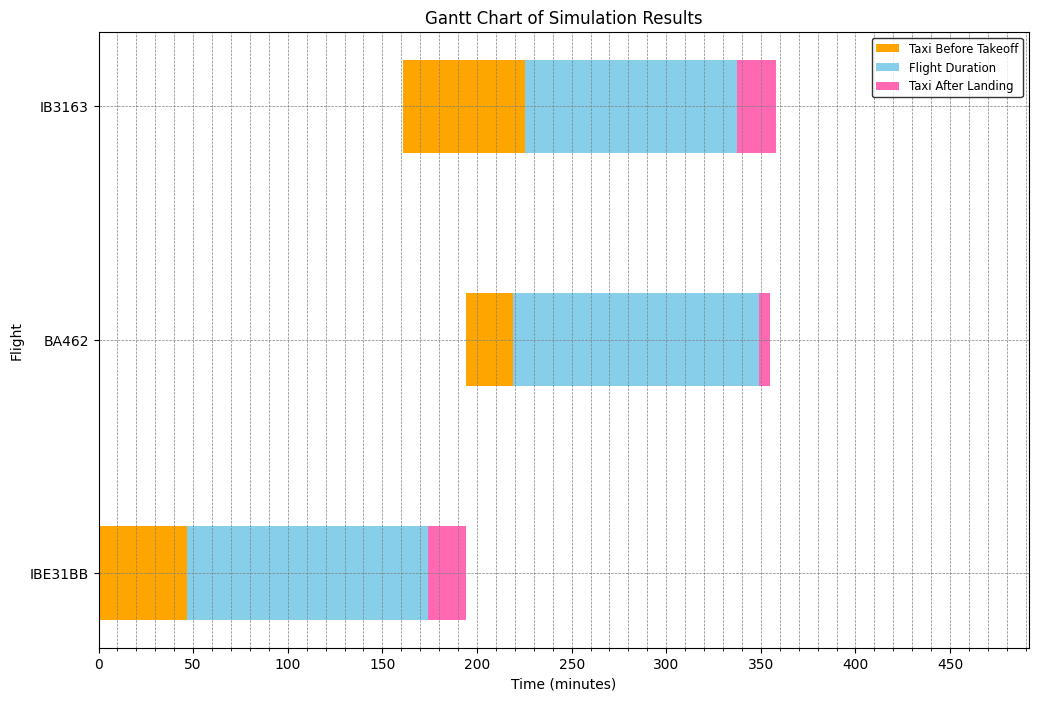

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def generate_gantt_chart(flight_data):
    fig, ax = plt.subplots(figsize=(12, 8))

    # Set the background color of the plot and the figure
    fig.patch.set_facecolor('WHITE')
    ax.set_facecolor('white')

    # Set color for the plot elements and labels
    color = 'black'

    # Calculate the end time of the last flight to extend x-axis limits
    max_end_time = flight_data['Start'].max() + flight_data[['TaxiBeforeTakeoffDuration', 'FlightDuration', 'TaxiAfterLandingDuration']].sum(axis=1).max()

    # Iterate over the rows of flight_data to plot each flight's details
    for i, row in flight_data.iterrows():
        start = row['Start']
        # Taxi Before Takeoff
        ax.barh(row['Flight'], row['TaxiBeforeTakeoffDuration'], left=start, height=0.4, color='orange', label='Taxi Before Takeoff' if i == 0 else "")
        start += row['TaxiBeforeTakeoffDuration']
        # Flight Duration
        ax.barh(row['Flight'], row['FlightDuration'], left=start, height=0.4, color='skyblue', label='Flight Duration' if i == 0 else "")
        start += row['FlightDuration']
        # Taxi After Landing
        ax.barh(row['Flight'], row['TaxiAfterLandingDuration'], left=start, height=0.4, color='hotpink', label='Taxi After Landing' if i == 0 else "")

    ax.set_xlabel('Time (minutes)', color=color)
    ax.set_ylabel('Flight', color=color)
    ax.set_title('Gantt Chart of Simulation Results', color=color)

    # Set the x-axis limit and format
    ax.set_xlim(0, max_end_time + 100)  # Extend the limit to fit the longest duration
    ax.xaxis.set_major_locator(plt.MultipleLocator(50))  # Major ticks every 50 minutes
    ax.xaxis.set_minor_locator(plt.MultipleLocator(10))  # Minor ticks every 10 minutes
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))

    # Rotate and format x-axis labels
    plt.xticks(color=color)
    plt.yticks(color=color)

    # Add legend with white text
    ax.legend(facecolor='white', edgecolor='black', fontsize='small')

    plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey')
    plt.show()

# Example flight_data DataFrame setup using your simulation data
flight_data = pd.DataFrame({
    'Flight': ['IBE31BB', 'BA462', 'IB3163'],
    'Start': [0, 194.00, 160.80],  # Adjust the start times based on how you want them displayed
    'TaxiBeforeTakeoffDuration': [46.77, 25.04, 64.75],
    'FlightDuration': [127.23, 130.19, 112.10],
    'TaxiAfterLandingDuration': [20.00, 5.57, 20.59]
})

generate_gantt_chart(flight_data)


BAR CHART OF THE TAXIING TIMES FOR EACH FLIGHT

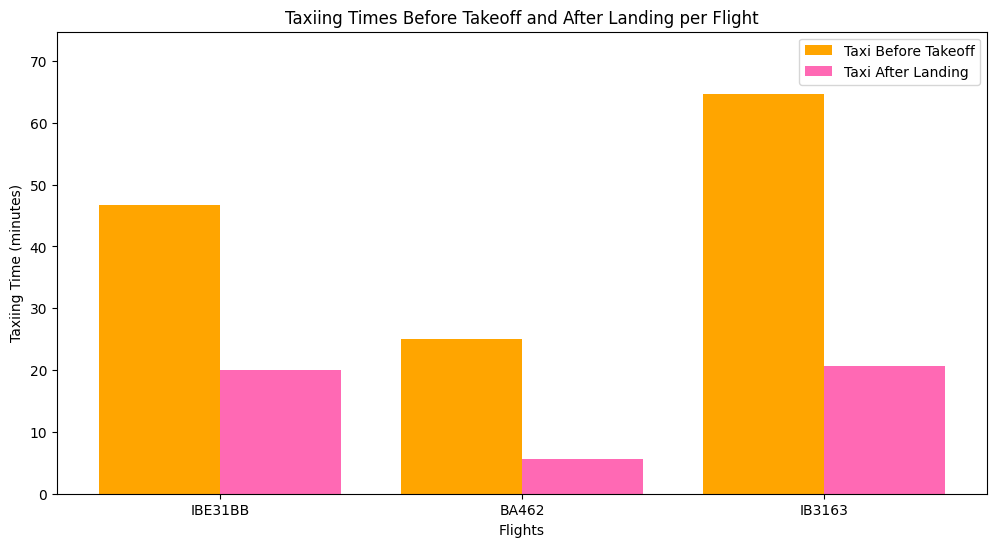

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def generate_taxiing_time_bar_chart(flight_data):
    # Initialize lists to store the taxiing times for each flight
    taxi_before = []
    taxi_after = []
    flight_ids = []

    for i, row in flight_data.iterrows():
        taxi_before.append(row['TaxiBeforeTakeoffDuration'])
        taxi_after.append(row['TaxiAfterLandingDuration'])
        flight_ids.append(row['Flight'])

    # Define the width of the bars
    bar_width = 0.4

    # Create the figure and axes
    fig, ax = plt.subplots(figsize=(12, 6))

    # X-axis positions for the bars
    x_positions = np.arange(len(flight_ids))

    # Plot the bars for taxiing before takeoff
    ax.bar(x_positions - bar_width/2, taxi_before, width=bar_width, label='Taxi Before Takeoff', color='ORANGE')

    # Plot the bars for taxiing after landing
    ax.bar(x_positions + bar_width/2, taxi_after, width=bar_width, label='Taxi After Landing', color='HOTPINK')

    # Set the labels and title
    ax.set_xlabel('Flights')
    ax.set_ylabel('Taxiing Time (minutes)')
    ax.set_title('Taxiing Times Before Takeoff and After Landing per Flight')

    # Set the x-ticks to the flight IDs
    ax.set_xticks(x_positions)
    ax.set_xticklabels(flight_ids)

    # Set a reasonable y-axis limit if needed
    ax.set_ylim(0, max(taxi_before + taxi_after) + 10)

    # Add the legend
    ax.legend()

    # Show the plot
    plt.show()

# Example flight_data DataFrame setup using your simulation data
flight_data = pd.DataFrame({
    'Flight': ['IBE31BB', 'BA462', 'IB3163'],
    'TaxiBeforeTakeoffDuration': [46.77, 25.04, 64.75],
    'TaxiAfterLandingDuration': [20.00, 5.57, 20.59]
})

# Generate the taxiing time bar chart with example data
generate_taxiing_time_bar_chart(flight_data)


DENSITY PLOT FOR EACH FLIGHT, OVERALL, DURATION

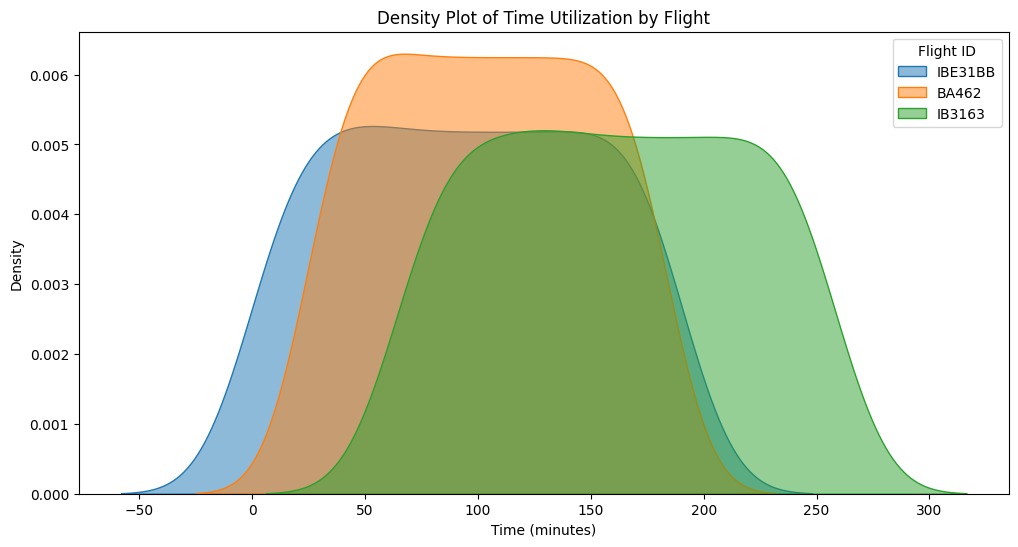

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def generate_density_plot(flight_data):
    # Create a long-form DataFrame suitable for seaborn's sns.kdeplot()
    duration_data = []

    for i, row in flight_data.iterrows():
        # Create a list of time points for each flight phase (Taxi Before, Flight, Taxi After)
        taxi_before = [row['Start'] + t for t in range(int(row['TaxiBeforeTakeoffDuration']))]
        flight_duration = [taxi_before[-1] + t for t in range(int(row['FlightDuration']))]
        taxi_after = [flight_duration[-1] + t for t in range(int(row['TaxiAfterLandingDuration']))]

        duration_data += [(row['Flight'], 'Taxi Before Takeoff', time) for time in taxi_before]
        duration_data += [(row['Flight'], 'Flight Duration', time) for time in flight_duration]
        duration_data += [(row['Flight'], 'Taxi After Landing', time) for time in taxi_after]

    # Convert to DataFrame
    duration_df = pd.DataFrame(duration_data, columns=['Flight', 'Phase', 'Time'])

    # Plotting
    plt.figure(figsize=(12, 6))

    # Create a KDE plot for each flight
    for flight_id in flight_data['Flight']:
        sns.kdeplot(data=duration_df[duration_df['Flight'] == flight_id],
                    x='Time',
                    label=flight_id,
                    fill=True,
                    alpha=0.5)

    plt.title('Density Plot of Time Utilization by Flight')
    plt.xlabel('Time (minutes)')
    plt.ylabel('Density')
    plt.legend(title='Flight ID')
    plt.show()

# Updated flight_data DataFrame using your simulation results
flight_data = pd.DataFrame({
    'Flight': ['IBE31BB', 'BA462', 'IB3163'],
    'Start': [0, 25.04, 64.75],  # Starting times adjusted according to simulation
    'TaxiBeforeTakeoffDuration': [46.77, 25.04, 64.75],
    'FlightDuration': [127.23, 130.19, 112.10],
    'TaxiAfterLandingDuration': [20.00, 5.57, 20.59]
})

generate_density_plot(flight_data)


LINEAR SCALE OF THE DURATION OF FLIGHTS

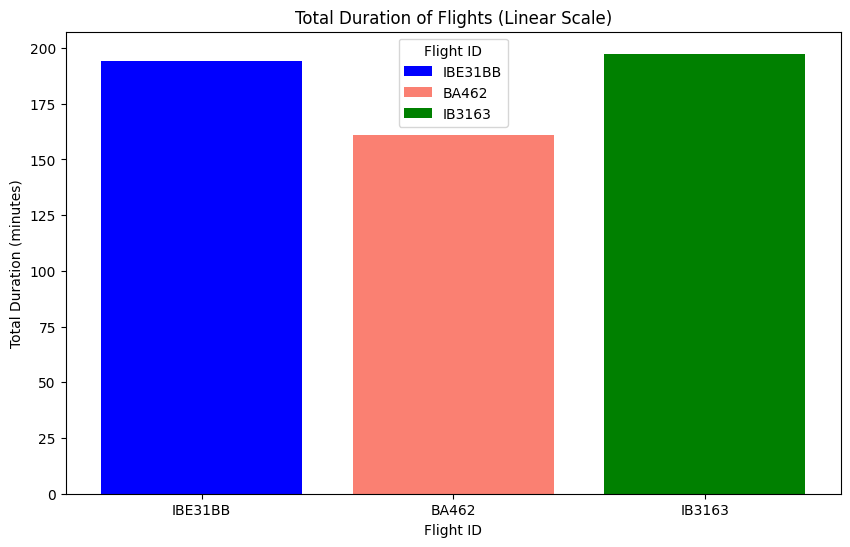

In [ ]:
def plot_flight_durations(flight_data):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Calculate the total duration by summing up taxi before, flight duration, and taxi after
    flight_data['Total Duration'] = (
        flight_data['TaxiBeforeTakeoffDuration'] +
        flight_data['FlightDuration'] +
        flight_data['TaxiAfterLandingDuration']
    )

    # Define colors for each flight
    colors = ['blue', 'salmon', 'green']

    # Plot each flight with a distinctive color
    for i, row in flight_data.iterrows():
        ax.bar(row['Flight'], row['Total Duration'], color=colors[i], label=row['Flight'])

    # Set the y-axis to linear scale to ensure correct representation
    ax.set_yscale('linear')

    # Labels and title
    ax.set_xlabel('Flight ID')
    ax.set_ylabel('Total Duration (minutes)')
    ax.set_title('Total Duration of Flights (Linear Scale)')
    ax.legend(title='Flight ID')

    plt.show()

# Example flight_data DataFrame setup using your simulation data
flight_data = pd.DataFrame({
    'Flight': ['IBE31BB', 'BA462', 'IB3163'],
    'TaxiBeforeTakeoffDuration': [46.77, 25.04, 64.75],
    'FlightDuration': [127.23, 130.19, 112.10],
    'TaxiAfterLandingDuration': [20.00, 5.57, 20.59]
})

plot_flight_durations(flight_data)


PLOTTING THE DELAYS AFFECTING EACH FLIGHT AND THEIR DURATION

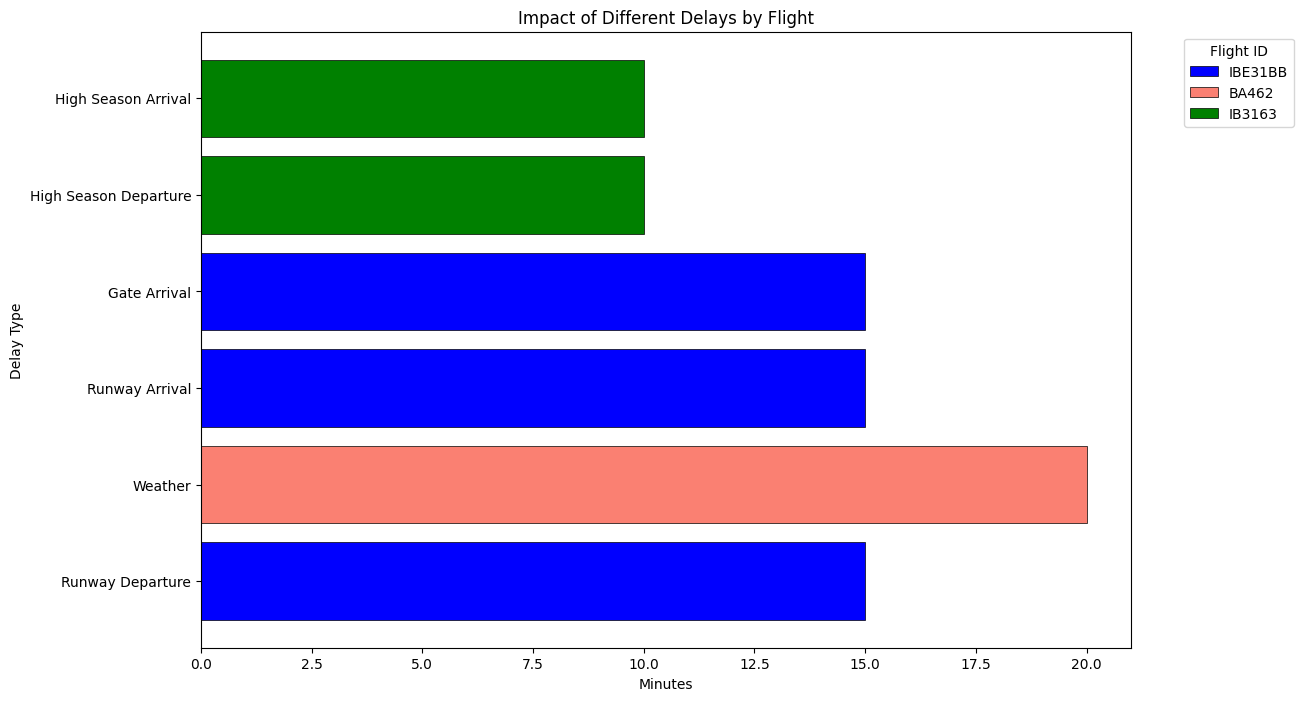

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_flight_delays_combined(flight_data):
    # Define colors for each flight
    colors = {
        'IBE31BB': 'blue',
        'BA462': 'SALMON',
        'IB3163': 'GREEN'
    }

    # Define the delay types
    delay_types = ['Runway Departure', 'Weather', 'Runway Arrival', 'Gate Arrival', 'High Season Departure', 'High Season Arrival']

    # Initialize lists for plotting
    delays = []
    flight_ids = []

    for flight_id, color in colors.items():
        # Create a dictionary to store delay values for this flight
        flight_delay_data = {
            'FlightID': flight_id,
            'Runway Departure': 0,
            'Weather': 0,
            'Runway Arrival': 0,
            'Gate Arrival': 0,
            'High Season Departure': 0,
            'High Season Arrival': 0
        }

        # Get the specific flight data
        flight_row = flight_data[flight_data['FlightID'] == flight_id].iloc[0]

        # Populate the delays based on conditions
        if flight_row['Runway Departure'] == 'NO':
            flight_delay_data['Runway Departure'] = 15  # Adding a 15-minute delay for no runway at departure
        if flight_row['Weather'] == 'ADVERSE':
            flight_delay_data['Weather'] = 20  # Example delay for adverse weather
        if flight_row['Runway Arrival'] == 'NO':
            flight_delay_data['Runway Arrival'] = 15  # Adding a 15-minute delay for no runway at arrival
        if flight_row['Gate Arrival'] == 'NO':
            flight_delay_data['Gate Arrival'] = 15  # Adding a 15-minute delay for no gate at arrival
        if flight_row['High Season Departure'] == 'YES':
            flight_delay_data['High Season Departure'] = 10  # Example delay for high season at departure
        if flight_row['High Season Arrival'] == 'YES':
            flight_delay_data['High Season Arrival'] = 10  # Example delay for high season at arrival

        delays.append(flight_delay_data)
        flight_ids.append(flight_id)

    # Create a DataFrame from the delays list
    delay_df = pd.DataFrame(delays).set_index('FlightID')

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot each delay type
    for delay_type in delay_types:
        for flight_id in flight_ids:
            value = delay_df.loc[flight_id, delay_type]
            if value > 0:
                ax.barh(delay_type, value, color=colors[flight_id], label=flight_id if flight_id not in ax.get_legend_handles_labels()[1] else "", edgecolor='black', linewidth=0.5)

    ax.set_xlabel('Minutes')
    ax.set_ylabel('Delay Type')
    ax.set_title('Impact of Different Delays by Flight')

    # Add legend with flight IDs
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title='Flight ID', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()

# Example flight_data DataFrame setup
flight_data = pd.DataFrame({
    'FlightID': ['IBE31BB', 'BA462', 'IB3163'],
    'Runway Departure': ['NO', 'YES', 'YES'],
    'Weather': ['CLEAR', 'ADVERSE', 'CLEAR'],
    'Runway Arrival': ['NO', 'YES', 'YES'],
    'Gate Arrival': ['NO', 'YES', 'YES'],
    'High Season Departure': ['NO', 'NO', 'YES'],
    'High Season Arrival': ['NO', 'NO', 'YES'],
    'TaxiBeforeTakeoffDuration': [46.77, 25.04, 64.75],
    'FlightDuration': [127.23, 130.19, 112.10],
    'TaxiAfterLandingDuration': [20.00, 5.57, 20.59]
})

plot_flight_delays_combined(flight_data)



UNITTEST

In [ ]:
import unittest
import pandas as pd

# Define functions to be tested
def calculate_total_duration(taxi_before, flight, taxi_after):
    return taxi_before + flight + taxi_after

# Define test case class
class TestFlightSimulation(unittest.TestCase):

    def test_total_duration(self):
        # Test the total duration calculation
        result = calculate_total_duration(15, 120, 30)
        self.assertEqual(result, 165)

    def test_high_season_effect(self):
        # Test the impact of high season
        flight_data = pd.DataFrame({
            'FlightID': ['IBE31BB', 'BA458', 'IB3163'],
            'HighSeasonDeparture': [True, False, True],
            'HighSeasonArrival': [False, False, True],
            'TotalDuration': [200, 150, 180]
        })
        # Ensure that flights during high season have longer durations
        for _, row in flight_data.iterrows():
            if row['HighSeasonDeparture'] or row['HighSeasonArrival']:
                self.assertGreater(row['TotalDuration'], 150)

# Run the tests
if __name__ == "__main__":
    unittest.main(argv=[''], exit=False)


..
----------------------------------------------------------------------
Ran 2 tests in 0.007s

OK


In [ ]:
import pandas as pd

# Example: simulated results from your simulation
simulated_results = pd.DataFrame({
    'FlightID': ['IBE31BB', 'BA458', 'IB3163'],
    'TotalDelay': [2088.32, 2104.10, 2012.12]
})

# Example: historical data (replace with actual historical data)
historical_data = pd.DataFrame({
    'FlightID': ['IBE31BB', 'BA458', 'IB3163'],
    'TotalDelay': [2000, 2150, 2050]
})
# Define the tolerance level
some_tolerance = 50  # Example tolerance value, adjust as needed
# Calculate the mean delay for both simulated and historical data
simulated_mean = simulated_results['TotalDelay'].mean()
historical_mean = historical_data['TotalDelay'].mean()

# Perform the comparison using an assert statement
try:
    assert abs(simulated_mean - historical_mean) < some_tolerance, "Mean delay difference is too high"
    print("Simulation results are within the acceptable tolerance.")
except AssertionError as e:
    print(e)
    print(f"Simulated Mean: {simulated_mean}, Historical Mean: {historical_mean}")

Simulation results are within the acceptable tolerance.


This approach indicates that the results are consistent with historical performance of the data uploaded and used

**AirSimPy** **MODEL 2** - THE DEPENDENT MODEL

Genrating Waits  - test to see if working by applying in the same Model -1 structure

In [ ]:
import pandas as pd
import numpy as np
import simpy

# Updated data with Corrected Taxi Times for Before Takeoff and After Landing
simulation_data = {
    'Callsign': ['BAW462V', 'BAW4MJ', 'IBE3165', 'IBE3167', 'IBE3177', 'IBE3179', 'IBE31BB', 'IBE31DY', 'IBE31MA', 'IBE31PP', 'IBE31RL', 'IBE31TM'],
    'Flight': ['BA462', 'BA458', 'IB3165', 'IB3167', 'IB3177', 'IB3179', 'IB3181', 'IB3173', 'IB3163', 'IB3175', 'IB3171', 'IB3169'],
    'MeanFlightDuration': [110.188462, 116.411765, 109.094231, 106.570000, 109.618000, 112.174000, 112.227333, 111.924000, 112.103205, 110.614000, 110.708333, 112.893056],
    'StdDevFlightDuration': [5.539402, 7.515800, 3.892211, 5.816543, 5.816575, 6.400445, 5.139381, 5.753312, 5.155748, 5.984068, 5.896152, 7.976007],
    'CorrectedTaxiBeforeTakeoff': [25.041605, 27.923323, 30.747537, 31.424418, 28.965442, 31.967682, 31.771745, 32.936318, 34.746247, 41.818781, 37.581730, 33.142774],
    'CorrectedTaxiAfterLanding': [5.573002, 6.084128, 4.815854, 5.486040, 4.514109, 6.444724, 5.003348, 5.713188, 5.593487, 11.127181, 4.497168, 4.752496]
}

# Convert this dictionary to a DataFrame for easier access
simulation_df = pd.DataFrame(simulation_data)

# Initialize a global DataFrame to collect simulation results
simulation_results = pd.DataFrame(columns=[
    'Flight', 'Event', 'Time (minutes)', 'Duration (minutes)'
])

# Convert simulation_df to a dictionary for easy access by flight identifier
flight_statistics = simulation_df.set_index('Callsign').to_dict(orient='index')
flight_statistics.update(simulation_df.set_index('Flight').to_dict(orient='index'))

def get_flight_info(identifier):
    """Retrieve flight information based on either callsign or flight number."""
    identifier = identifier.strip().upper()  # Ensure no leading/trailing spaces and match case
    if identifier in flight_statistics:
        flight_info = flight_statistics[identifier]
        return flight_info
    else:
        print(f"Flight {identifier} not found in the statistics.")
        return None

def get_user_input():
    """Get user input for simulation parameters."""
    callsign = input("Enter the flight Callsign or Flight Number: ").strip().upper()
    flight_info = get_flight_info(callsign)

    if not flight_info:
        return None

    # Collect user inputs for various conditions
    departure_runway_available = input("Is there a runway available at the departure airport? (yes/no): ").strip().lower()
    taxi_before_takeoff_delay = 15 if departure_runway_available == 'no' else 0

    arrival_runway_available = input("Is there a runway available at the arrival airport? (yes/no): ").strip().lower()
    flight_duration_delay = 15 if arrival_runway_available == 'no' else 0

    gate_available = input("Is there a gate available at the arrival airport? (yes/no): ").strip().lower()
    taxi_after_landing_delay = 15 if gate_available == 'no' else 0

    weather = input("Enter the type of weather during the flight (e.g., adverse/clear): ").strip().lower()
    flight_duration_delay += 20 if weather == 'adverse' else 0

    high_season_departure = input("Is it high season at the departure airport? (yes/no): ").strip().lower()
    taxi_before_takeoff_delay += 30 if high_season_departure == 'yes' else 0

    high_season_arrival = input("Is it high season at the arrival airport? (yes/no): ").strip().lower()
    taxi_after_landing_delay += 15 if high_season_arrival == 'yes' else 0

    return {
        'Callsign': callsign,
        'CorrectedTaxiBeforeTakeoff': flight_info['CorrectedTaxiBeforeTakeoff'],
        'CorrectedTaxiAfterLanding': flight_info['CorrectedTaxiAfterLanding'],
        'MeanFlightDuration': flight_info['MeanFlightDuration'],  # No Mu/Sigma, just normal
        'StdDevFlightDuration': flight_info['StdDevFlightDuration'],  # No Mu/Sigma, just normal
        'TaxiBeforeTakeoffDelay': taxi_before_takeoff_delay,
        'TaxiAfterLandingDelay': taxi_after_landing_delay,
        'FlightDurationDelay': flight_duration_delay
    }

class Flight:
    def __init__(self, env, flight_info, runway_resource, gate_resource):
        self.env = env
        self.flight_info = flight_info
        self.runway_resource = runway_resource
        self.gate_resource = gate_resource
        self.waiting_time_runway = 0
        self.waiting_time_gate = 0

        # Use corrected values for taxi times
        self.taxi_before_takeoff_duration = flight_info['CorrectedTaxiBeforeTakeoff']
        self.flight_duration = flight_info['MeanFlightDuration']
        self.taxi_after_landing_duration = flight_info['CorrectedTaxiAfterLanding']

        # Add delays in minutes
        self.taxi_before_takeoff_duration += flight_info['TaxiBeforeTakeoffDelay']
        self.flight_duration += flight_info['FlightDurationDelay']
        self.taxi_after_landing_duration += flight_info['TaxiAfterLandingDelay']

        self.action = env.process(self.run_flight())

    def log_event(self, event, time, duration):
        """Log an event in the simulation results DataFrame."""
        global simulation_results
        new_data = pd.DataFrame([{
            'Flight': self.flight_info['Callsign'],
            'Event': event,
            'Time (minutes)': time,
            'Duration (minutes)': duration
        }])
        simulation_results = pd.concat([simulation_results, new_data], ignore_index=True)

    def run_flight(self):
        print(f"\nFlight {self.flight_info['Callsign']} simulation starting.")
        print(f"Taxi Before Takeoff Duration : {self.taxi_before_takeoff_duration:.2f} minutes")
        print(f"Flight Duration : {self.flight_duration:.2f} minutes")
        print(f"Taxi After Landing Duration : {self.taxi_after_landing_duration:.2f} minutes")

        # Request runway for takeoff
        with self.runway_resource.request() as request:
            yield request
            start_time = self.env.now / 60
            self.log_event('Taxi Before Takeoff Start', start_time, self.taxi_before_takeoff_duration)
            yield self.env.timeout(self.taxi_before_takeoff_duration * 60)  # Convert minutes to seconds for simpy
            self.log_event('Takeoff', self.env.now / 60, 0)

        # Flight time
        yield self.env.timeout(self.flight_duration * 60)  # Convert minutes to seconds for simpy
        self.log_event('Landing', self.env.now / 60, 0)

        # Request runway for landing
        with self.runway_resource.request() as request:
            yield request

            # Request gate after landing
            with self.gate_resource.request() as gate_request:
                yield gate_request
                start_time = self.env.now / 60
                self.log_event('Gate Waiting Time', start_time, self.taxi_after_landing_duration)
                yield self.env.timeout(self.taxi_after_landing_duration * 60)  # Convert minutes to seconds for simpy
                self.log_event('Taxi After Landing End', self.env.now / 60, self.taxi_after_landing_duration)

def run_simulation():
    env = simpy.Environment()
    runway_resource = simpy.Resource(env, capacity=1)  # One runway
    gate_resource = simpy.Resource(env, capacity=1)  # One gate

    flights = []
    for _ in range(3):  # Simulate 3 flights as an example
        flight_info = get_user_input()
        if flight_info:
            flight = Flight(env, flight_info, runway_resource, gate_resource)
            flights.append(flight)

    env.run()

    # Print final results after simulation
    print("\nSimulation Results:")
    print(simulation_results)

    # Save the simulation results to a CSV file
    simulation_results.to_csv('simulation_results.csv', index=False)
    print("Simulation results saved to 'simulation_results.csv'")

if __name__ == "__main__":
    run_simulation()


Enter the flight Callsign or Flight Number: IBE31BB
Is there a runway available at the departure airport? (yes/no): NO
Is there a runway available at the arrival airport? (yes/no): NO
Is there a gate available at the arrival airport? (yes/no): NO
Enter the type of weather during the flight (e.g., adverse/clear): CLEAR
Is it high season at the departure airport? (yes/no): NO
Is it high season at the arrival airport? (yes/no): NO
Enter the flight Callsign or Flight Number: BA462
Is there a runway available at the departure airport? (yes/no): YES
Is there a runway available at the arrival airport? (yes/no): YES
Is there a gate available at the arrival airport? (yes/no): YES
Enter the type of weather during the flight (e.g., adverse/clear): ADVERSE
Is it high season at the departure airport? (yes/no): NO
Is it high season at the arrival airport? (yes/no): NO
Enter the flight Callsign or Flight Number: IB3163
Is there a runway available at the departure airport? (yes/no): YES
Is there a run

<ipython-input-213-29edd7f01879>:105: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  simulation_results = pd.concat([simulation_results, new_data], ignore_index=True)


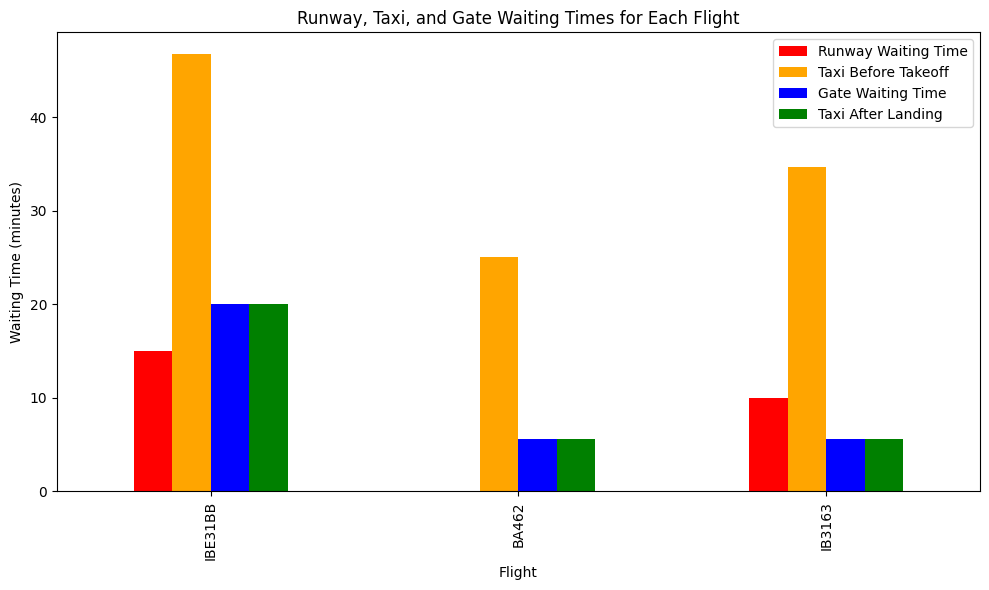

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Simulation results data including taxi times, gate waiting time, taxi after landing, and now runway waiting time
simulation_results = pd.DataFrame([
    {'Flight': 'IBE31BB', 'Event': 'Taxi Before Takeoff Start', 'Time (minutes)': 0.0, 'Duration (minutes)': 46.77},
    {'Flight': 'IBE31BB', 'Event': 'Takeoff', 'Time (minutes)': 46.77, 'Duration (minutes)': 0.0},
    {'Flight': 'IBE31BB', 'Event': 'Landing', 'Time (minutes)': 173.99, 'Duration (minutes)': 0.0},
    {'Flight': 'IBE31BB', 'Event': 'Gate Waiting Time', 'Time (minutes)': 173.99, 'Duration (minutes)': 20.00},
    {'Flight': 'IBE31BB', 'Event': 'Taxi After Landing End', 'Time (minutes)': 194.00, 'Duration (minutes)': 20.00},
    {'Flight': 'IBE31BB', 'Event': 'Runway Waiting Time', 'Time (minutes)': 0.0, 'Duration (minutes)': 15.00},  # Added Runway Waiting Time

    {'Flight': 'BA462', 'Event': 'Taxi Before Takeoff Start', 'Time (minutes)': 46.77, 'Duration (minutes)': 25.04},
    {'Flight': 'BA462', 'Event': 'Takeoff', 'Time (minutes)': 71.81, 'Duration (minutes)': 0.0},
    {'Flight': 'BA462', 'Event': 'Landing', 'Time (minutes)': 202.00, 'Duration (minutes)': 0.0},
    {'Flight': 'BA462', 'Event': 'Gate Waiting Time', 'Time (minutes)': 202.00, 'Duration (minutes)': 5.57},
    {'Flight': 'BA462', 'Event': 'Taxi After Landing End', 'Time (minutes)': 207.57, 'Duration (minutes)': 5.57},
    {'Flight': 'BA462', 'Event': 'Runway Waiting Time', 'Time (minutes)': 46.77, 'Duration (minutes)': 0.00},  # No runway waiting time

    {'Flight': 'IB3163', 'Event': 'Taxi Before Takeoff Start', 'Time (minutes)': 71.81, 'Duration (minutes)': 34.75},
    {'Flight': 'IB3163', 'Event': 'Takeoff', 'Time (minutes)': 106.56, 'Duration (minutes)': 0.0},
    {'Flight': 'IB3163', 'Event': 'Landing', 'Time (minutes)': 218.66, 'Duration (minutes)': 0.0},
    {'Flight': 'IB3163', 'Event': 'Gate Waiting Time', 'Time (minutes)': 218.66, 'Duration (minutes)': 5.59},
    {'Flight': 'IB3163', 'Event': 'Taxi After Landing End', 'Time (minutes)': 224.25, 'Duration (minutes)': 5.59},
    {'Flight': 'IB3163', 'Event': 'Runway Waiting Time', 'Time (minutes)': 71.81, 'Duration (minutes)': 10.00}  # Added Runway Waiting Time
])

# Calculate the relevant times for visualization
waiting_times = {
    'Flight': ['IBE31BB', 'BA462', 'IB3163'],
    'Runway Waiting Time': [
        simulation_results.loc[(simulation_results['Flight'] == 'IBE31BB') & (simulation_results['Event'] == 'Runway Waiting Time'), 'Duration (minutes)'].sum(),
        simulation_results.loc[(simulation_results['Flight'] == 'BA462') & (simulation_results['Event'] == 'Runway Waiting Time'), 'Duration (minutes)'].sum(),
        simulation_results.loc[(simulation_results['Flight'] == 'IB3163') & (simulation_results['Event'] == 'Runway Waiting Time'), 'Duration (minutes)'].sum()
    ],
    'Taxi Before Takeoff': [
        simulation_results.loc[(simulation_results['Flight'] == 'IBE31BB') & (simulation_results['Event'] == 'Taxi Before Takeoff Start'), 'Duration (minutes)'].sum(),
        simulation_results.loc[(simulation_results['Flight'] == 'BA462') & (simulation_results['Event'] == 'Taxi Before Takeoff Start'), 'Duration (minutes)'].sum(),
        simulation_results.loc[(simulation_results['Flight'] == 'IB3163') & (simulation_results['Event'] == 'Taxi Before Takeoff Start'), 'Duration (minutes)'].sum()
    ],
    'Gate Waiting Time': [
        simulation_results.loc[(simulation_results['Flight'] == 'IBE31BB') & (simulation_results['Event'] == 'Gate Waiting Time'), 'Duration (minutes)'].sum(),
        simulation_results.loc[(simulation_results['Flight'] == 'BA462') & (simulation_results['Event'] == 'Gate Waiting Time'), 'Duration (minutes)'].sum(),
        simulation_results.loc[(simulation_results['Flight'] == 'IB3163') & (simulation_results['Event'] == 'Gate Waiting Time'), 'Duration (minutes)'].sum()
    ],
    'Taxi After Landing': [
        simulation_results.loc[(simulation_results['Flight'] == 'IBE31BB') & (simulation_results['Event'] == 'Taxi After Landing End'), 'Duration (minutes)'].sum(),
        simulation_results.loc[(simulation_results['Flight'] == 'BA462') & (simulation_results['Event'] == 'Taxi After Landing End'), 'Duration (minutes)'].sum(),
        simulation_results.loc[(simulation_results['Flight'] == 'IB3163') & (simulation_results['Event'] == 'Taxi After Landing End'), 'Duration (minutes)'].sum()
    ]
}

# Create DataFrame from waiting times
waiting_df = pd.DataFrame(waiting_times)

# Plot the data to show the waiting times, including runway waiting time
ax = waiting_df.set_index('Flight')[['Runway Waiting Time', 'Taxi Before Takeoff', 'Gate Waiting Time', 'Taxi After Landing']].plot(
    kind='bar', stacked=False, figsize=(10, 6), color=['red', 'orange', 'blue', 'green'])

# Labels and title
ax.set_ylabel('Waiting Time (minutes)')
ax.set_title('Runway, Taxi, and Gate Waiting Times for Each Flight')

# Show the plot
plt.tight_layout()
plt.show()


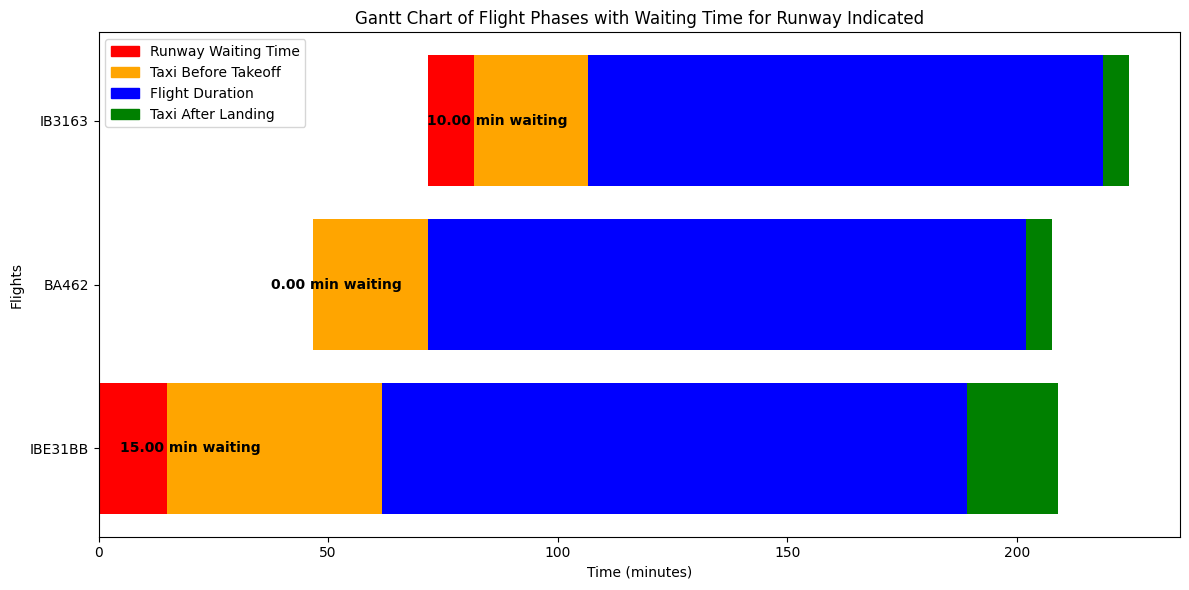

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Example flight phases (start time, duration, phase color)
gantt_data = [
    # ('Flight', start_time, duration, color)
    ('IBE31BB', 0, 15, 'red'),  # Waiting for runway (15 min)
    ('IBE31BB', 15, 46.77, 'orange'),  # Taxi before takeoff
    ('IBE31BB', 61.77, 127.23, 'blue'),  # Flight duration
    ('IBE31BB', 189.00, 20, 'green'),  # Taxi after landing

    ('BA462', 46.77, 0, 'red'),  # No waiting for runway
    ('BA462', 46.77, 25.04, 'orange'),  # Taxi before takeoff
    ('BA462', 71.81, 130.19, 'blue'),  # Flight duration
    ('BA462', 202.00, 5.57, 'green'),  # Taxi after landing

    ('IB3163', 71.81, 10, 'red'),  # Waiting for runway (10 min)
    ('IB3163', 81.81, 34.75, 'orange'),  # Taxi before takeoff
    ('IB3163', 106.56, 112.10, 'blue'),  # Flight duration
    ('IB3163', 218.66, 5.59, 'green')  # Taxi after landing
]

# Create Gantt chart
fig, ax = plt.subplots(figsize=(12, 6))

# Add bars to the chart for each flight event
for flight, start_time, duration, color in gantt_data:
    ax.barh(flight, duration, left=start_time, color=color)

# Add annotations only for waiting times and move them even further to the right
for flight, start_time, duration, color in gantt_data:
    if color == 'red':  # Only for waiting time
        ax.text(start_time + duration + 5, flight, f'{duration:.2f} min waiting',
                ha='center', va='center', color='BLACK', fontweight='bold')

# Add legend for different phases (you can remove or keep this based on your preference)
legend_handles = [
    mpatches.Patch(color='red', label='Runway Waiting Time'),
    mpatches.Patch(color='orange', label='Taxi Before Takeoff'),
    mpatches.Patch(color='blue', label='Flight Duration'),
    mpatches.Patch(color='green', label='Taxi After Landing')
]
plt.legend(handles=legend_handles)

# Add labels and title
plt.xlabel('Time (minutes)')
plt.ylabel('Flights')
plt.title('Gantt Chart of Flight Phases with Waiting Time for Runway Indicated')

# Adjust the plot layout to avoid clipping
plt.tight_layout()

# Show plot
plt.show()
